# Model for Simulating Energy and Economic Performance of Power Stations in DR Aggregations V5.0

Changes from v5-2 to v5-3:
* implements control scheme validated against optimization model

## Structure of the notebook

1) globals define
2) hardware and system characteristics define from data sets
3) energy modeling
   * PV modeling
   * battery modeling
4) financial modeling
5) DR performance modeling
6) big loop
7) basic results analysis


In [187]:
import pandas as pd
import numpy as np
import requests
import pvlib
import matplotlib.pyplot as plt  # for visualization
from matplotlib.patches import Patch
import math
from datetime import datetime
from statistics import median
from statistics import mean
from keys import *
from typing import List, Dict, Any
from collections import deque
import glob

In [113]:
#GLOBALS
#note that these coordinates are the inputs for the NREL API,
#the coordinates used by the NREL API for the weather file are slightly different
#see below
lat = 40.7128
long = -74.0060

#optimize for summer when DR program is in effect
#also minimizes shading from buildings during PSH
tilt = lat #math.floor(lat - 15)
print("tilt: " + str(tilt))

#default to south facing
azimuth = 180

#14% losses
shading = .86

#max 99% efficient mppt battery charger - used for PV to battery
mppt = .99

# conversion rate when charging battery from grid - used for grid to battery
acToDC = .9

# microinverter conversion efficiency - used for PV to grid
# Device: Hoymiles HiFlow (360-500) Pro LV
miEff = 0.998 #nominal efficiency
miMaxW_hm = 500 #max input wattage for Hoymiles microinverter
miMaxW_ap = 1200 #max input wattage for AP microinverter

# max 80% depth of discharge for LiFePO4 batteries under normal circumstances
# & 95% to maximize flexibiltiy during events
LiFePOdod = 0.80
LiFePOdod_event = 0.95

#Max Hardware Sizes
pvMaxW = 1200

#PV degredation rate is assumed to be 1% annually
DEG_RATE = 0.01

#days in the months May - September
daysInMonth = [31,30,31,31,30]
drSeasonStartDay = 121

# self consumption of both controller and power station
controllerSC = 1 #Raspberry Pi Zero 2W controller self-consumption
powerStationSC = 12.65 #power station no-load self-consumption with AC outputs turned on # turn back on after homer test!
scWDC = controllerSC + powerStationSC
dailySelfConsumptionWhDC = scWDC * 24
#annualSelfConsumptionkWhDC = scWDC * 24 * 365 * 0.001


tilt: 40.7128


## Commercially Available Power Station Data


In [114]:
hardware_df = pd.read_csv('data/PowerStations_LiFePo4_June29_2026.csv')

#clean data - these columns aren't used in this analysis
hardware_df = hardware_df.drop(columns=['Link','Min PV Voltage','Max PV Voltage','Warranty Years','Lifespan','Notes','Estimated Full Charge Time','Estimated Minimum Grid Charge Efficiency'])

retailPriceColumns = ['Retail Price (3/14/2026)']

#filter out batteries over specified size
#print(hardware_df[hardware_df['Battery Wh'] > 2000])
#hardware_df = hardware_df[hardware_df['Battery Wh'] <= 2000]



In [115]:
pC = []
for c in hardware_df.columns:
    if 'Price (' in c:
        pC.append(c)

#get average retail prices
hardware_df['retail price']= hardware_df[retailPriceColumns].mean(axis=1)
hardware_df = hardware_df.drop(columns=pC) #drop raw price data

hardware_df = hardware_df.dropna(subset=['retail price']) #drop rows with missing avg prices

hardware_df.head()

,Make,Model,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,Passthrough,community API,official API,potential API,retail price
0,Jackery,Explorer 300 Plus,288.00,100,5.0,300.0,100.0,2.00,NaN,85.0,3000,80,True,True,False,False,299.0
1,Jackery,Explorer 600 Plus,632.00,200,10.5,800.0,1800.0,1.60,NaN,85.0,4000,70,True,True,False,False,429.0
2,Jackery,Explorer 700 Plus,680.96,600,11.0,1000.0,NaN,1.75,NaN,85.0,4000,70,NaN,True,False,False,599.0
3,Jackery,Explorer 1000 Plus,1264.64,800,22.0,2000.0,NaN,1.70,NaN,85.0,4000,70,NaN,True,False,False,599.0
4,Jackery,Explorer 2000 Plus,2042.80,1400,24.0,3000.0,NaN,2.00,NaN,85.0,4000,70,NaN,True,False,False,1099.0


In [116]:
hardware_df = hardware_df[(hardware_df['official API']==True)| (hardware_df['community API']==True)]

In [117]:
# # adjust charge times based on measurements
# hardware_df['80 Per Grid Charge Hours Adjusted']=hardware_df['80 Per Grid Charge Hours']/.75
# hardware_df['Full Grid Charge Hours Adjusted']=hardware_df['Full Grid Charge Hours']/.75

In [118]:
hardware_df.head()

,Make,Model,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,Passthrough,community API,official API,potential API,retail price
0,Jackery,Explorer 300 Plus,288.00,100,5.0,300.0,100.0,2.00,NaN,85.0,3000,80,True,True,False,False,299.0
1,Jackery,Explorer 600 Plus,632.00,200,10.5,800.0,1800.0,1.60,NaN,85.0,4000,70,True,True,False,False,429.0
2,Jackery,Explorer 700 Plus,680.96,600,11.0,1000.0,NaN,1.75,NaN,85.0,4000,70,NaN,True,False,False,599.0
3,Jackery,Explorer 1000 Plus,1264.64,800,22.0,2000.0,NaN,1.70,NaN,85.0,4000,70,NaN,True,False,False,599.0
4,Jackery,Explorer 2000 Plus,2042.80,1400,24.0,3000.0,NaN,2.00,NaN,85.0,4000,70,NaN,True,False,False,1099.0


In [119]:
#get average charge time percent for 80% relative to a 100% charge
hardware_df['charge ratio'] = hardware_df['80 Per Grid Charge Hours'] / hardware_df['Full Grid Charge Hours']
#print(hardware_df[~hardware_df['charge ratio'].isnull()])
#get the average ratio of 80% to 100%
eightyCT = round(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'].mean() * 100, 2) * .01
print(str(eightyCT * 100) + '% of the full charge time is spent charging from 0-80%.')

# #get average charge time percent for 80% relative to a 100% charge
# hardware_df['charge ratio adjusted'] = hardware_df['80 Per Grid Charge Hours Adjusted'] / hardware_df['Full Grid Charge Hours Adjusted']
# #print(hardware_df[~hardware_df['charge ratio adjusted'].isnull()])
# #get the average ratio of 80% to 100%
# eightyCTadjusted = round(hardware_df[~hardware_df['charge ratio adjusted'].isnull()]['charge ratio adjusted'].mean() * 100, 2) * .01
# print(str(eightyCTadjusted * 100) + '% of the full adjusted charge time is spent charging from 0-80%.')

65.48% of the full charge time is spent charging from 0-80%.


In [120]:
# #display(hardware_df.tail())
#update full charge column
full_missing = hardware_df['Full Grid Charge Hours'].isnull()
hardware_df.loc[full_missing, 'Full Grid Charge Hours'] = (
    hardware_df.loc[full_missing, '80 Per Grid Charge Hours'] / eightyCT
)

#update 80% charge column
eighty_missing = hardware_df['80 Per Grid Charge Hours'].isnull()
hardware_df.loc[eighty_missing, '80 Per Grid Charge Hours'] = (
    hardware_df.loc[eighty_missing, 'Full Grid Charge Hours'] * eightyCT
)

In [121]:
tP = hardware_df.shape[0]

inverterEfficiencyMean = round(hardware_df['Inverter Efficiency'].mean(),4)
invEffDefault = inverterEfficiencyMean * 0.01
print('Default Efficiency for use in model: ' + str(inverterEfficiencyMean))
print('% with unknown efficiency: ' + str(100*hardware_df[hardware_df['Inverter Efficiency'].isnull()].shape[0]/tP))
hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency'].fillna(inverterEfficiencyMean)
hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency']*.01


Default Efficiency for use in model: 86.6667
% with unknown efficiency: 0.0


In [122]:
# price per Wh
hardware_df['$/Wh'] = hardware_df['retail price']/hardware_df['Battery Wh']

In [123]:
hardware_df.info()

<class 'pandas.DataFrame'>
Index: 45 entries, 0 to 53
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      45 non-null     str    
 1   Model                     45 non-null     str    
 2   Battery Wh                45 non-null     float64
 3   Max PV Watts              45 non-null     int64  
 4   Max PV Amps               29 non-null     float64
 5   Inverter Watts            44 non-null     float64
 6   Max AC Input Watts        37 non-null     float64
 7   Full Grid Charge Hours    45 non-null     float64
 8   80 Per Grid Charge Hours  45 non-null     float64
 9   Inverter Efficiency       45 non-null     float64
 10  Cycles                    45 non-null     int64  
 11  DoD                       45 non-null     int64  
 12  Passthrough               2 non-null      object 
 13  community API             45 non-null     bool   
 14  official API              45

In [124]:
hardware_df.describe()

,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,retail price,charge ratio,$/Wh
count,45.000000,45.000000,29.000000,44.000000,37.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,5.000000,45.000000
mean,1165.564444,610.666667,13.610345,1475.000000,1128.324324,1.574352,1.030483,0.866667,3511.111111,78.888889,562.800000,0.654762,0.576610
std,751.915725,479.779305,6.417017,864.580823,659.223873,0.697430,0.457838,0.035355,678.307460,3.178209,305.745408,0.095979,0.257100
min,204.000000,100.000000,5.000000,300.000000,100.000000,0.801772,0.525000,0.800000,2500.000000,70.000000,149.000000,0.500000,0.305339
25%,512.000000,200.000000,8.200000,600.000000,500.000000,1.166667,0.750000,0.850000,3000.000000,80.000000,300.000000,0.642857,0.389757
50%,1024.000000,500.000000,12.000000,1500.000000,1200.000000,1.500000,0.982200,0.850000,3500.000000,80.000000,549.000000,0.666667,0.493490
75%,2000.000000,1000.000000,20.000000,2200.000000,1800.000000,1.800000,1.178640,0.900000,4000.000000,80.000000,799.000000,0.714286,0.682617
max,3072.000000,2400.000000,25.000000,3600.000000,2400.000000,4.500000,2.946600,0.900000,6000.000000,80.000000,1499.000000,0.750000,1.486352


In [125]:
# data snapshot
print('Total Number of Companies: ' + str(hardware_df.drop_duplicates(subset=['Make']).shape[0]))
print('Total Number of Products: ' + str(tP))

print('')
print('*** PV Charge Time (without losses) ***')
print('Min:' + str(min(hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99))))
print('Max:' + str(max(hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99))))
pvChargeMed = (hardware_df['Battery Wh']/(hardware_df['Max PV Watts']*.99)).median()
print('Median:' + str(pvChargeMed))

Total Number of Companies: 6
Total Number of Products: 45

*** PV Charge Time (without losses) ***
Min:0.8619528619528619
Max:5.818181818181818
Median:2.0686868686868687


In [126]:
hardware_df.iloc[28]

Make                            EcoFlow
Model                       DELTA 2 Max
Battery Wh                       2048.0
Max PV Watts                       1000
Max PV Amps                        15.0
Inverter Watts                   2400.0
Max AC Input Watts               1800.0
Full Grid Charge Hours         1.679902
80 Per Grid Charge Hours            1.1
Inverter Efficiency                 0.9
Cycles                             3000
DoD                                  80
Passthrough                         NaN
community API                     False
official API                       True
potential API                     False
retail price                     1499.0
charge ratio                        NaN
$/Wh                           0.731934
Name: 30, dtype: object

In [127]:
def get_round_trip_efficiency(battery_index, acToDC=acToDC):
    """Round-trip efficiency (grid -> battery -> load) for one battery in
    hardware_df: charge-side loss (acToDC, same for every battery) times
    that battery's own discharge-side inverter efficiency. No separate
    battery-chemistry loss is modeled here -- conversion losses are the
    only losses this model accounts for."""
    row = hardware_df.loc[battery_index]
    inverter_eff = row['Inverter Efficiency']  # already converted to a 0-1 fraction in cell 8
    round_trip_eff = acToDC * inverter_eff

    print(f"Battery index {battery_index}:")
    print(f"  Charge efficiency (acToDC):     {acToDC:.4f}")
    print(f"  Discharge efficiency (inverter): {inverter_eff:.4f}")
    print(f"  Round-trip efficiency:           {round_trip_eff:.4f} ({round_trip_eff*100:.1f}%)")

    return round_trip_eff

rt_eff = get_round_trip_efficiency(28)

Battery index 28:
  Charge efficiency (acToDC):     0.9000
  Discharge efficiency (inverter): 0.9000
  Round-trip efficiency:           0.8100 (81.0%)


## Con Ed Network Data

In [128]:
# read in hardware data to dataframe
networks_df = pd.read_csv('data/conEdNetworks2026.csv')

networksToSim = ['bowling green','borden','sunnyside','grasslands','fresh kills','central bronx','fordham','park slope']
networks_df[networks_df['network'].isin(networksToSim)]

,borough,network,start time,end time,tier
0,bronx,central bronx,19:00,23:00,2
1,bronx,fordham,16:00,20:00,2
12,brooklyn,park slope,14:00,18:00,2
19,manhattan,bowling green,11:00,15:00,1
56,queens,borden,14:00,18:00,1
64,queens,sunnyside,16:00,20:00,1
66,staten island,fresh kills,19:00,23:00,1
74,westchester,grasslands,16:00,20:00,1


In [129]:
#returns the network info for a given network
#args: network name
def getNetworkInfo(networkName):
    return networks_df.loc[networks_df['network']== networkName]

#returns the tier for a given item in the network info list
#args: network name
def getDLRPrate(networkName):
    n = getNetworkInfo(networkName)
    t = n['tier'].iloc[0]
    #tier 2 networks pay at a higher rate
    if t == 1:
        return 18
    else:
        return 25
    
#returns the borough for a given item in the network info list
#args: network name
def getCSRPrate(networkName):
    n = getNetworkInfo(networkName)
    t = n['borough'].iloc[0]
    #westchester and staten island pay at a lower rate
    if t not in ['westchester','staten island']:
        return 18
    else:
        return 6

#args: network name
def getTotalRate(networkName):
    return getDLRPrate(networkName) + getCSRPrate(networkName)
    
#returns borough name
#args: network name
def getBorough(networkName):
    n = getNetworkInfo(networkName)
    return n['borough'].iloc[0]

#returns event start time
#args: network name
def getStartTime(networkName):
    n = getNetworkInfo(networkName)
    return int(n['start time'].iloc[0].split(":")[0])

In [130]:
# # Load the real ResStock fridge draw (average across the unique NYC
# # multifamily buildings), replacing the fixed loadTwoW watt value.
# # loadOneW (AC) and loadOneW_Replacement (fan) stay fixed for now.

# fridge_path = max(glob.glob("data/ResStock_fridge_hourly_W_with_average_*.csv"))
# print("Using fridge file:", fridge_path)

# fridge_df = pd.read_csv(fridge_path, index_col=0, parse_dates=True)
# fridge_hourly_W = fridge_df["average"].to_numpy()

# n_hours_model = len(hourly_array_power_yield_test)  # match whichever variable your loop actually uses
# assert len(fridge_hourly_W) == n_hours_model, (
#     f"fridge array length ({len(fridge_hourly_W)}) != model hours ({n_hours_model})"
# )

# loads = {
#     'loadOneW': 1000,              # AC — still fixed, unchanged for now
#     'loadTwoW': fridge_hourly_W,   # fridge — avg ResStock hourly profile
#     'loadOneW_Replacement': 75,    # fan — still fixed, unchanged for now
# }

# print(f"Fridge array: {fridge_df.shape[1] - 1} buildings averaged, "
#       f"annual mean {fridge_hourly_W.mean():.1f} W, peak {fridge_hourly_W.max():.1f} W")

## PV Performance Modeling

In [131]:
#get TMY via API
try:
    df_tmy, metadata = pvlib.iotools.get_nsrdb_psm4_tmy(
        latitude=lat,
        longitude=long,
        api_key=NREL_API_KEY,
        time_step=60,
        email='nathaa@rpi.edu',  # <-- any email works here fine
        year='tmy-2024')
except requests.HTTPError as e:
    print("Status code:", e.response.status_code)
    print("Raw response text:")
    print(e.response.text)
    raise

metadata

{'Source': 'NSRDB',
 'Location ID': '1243965',
 'City': '-',
 'State': '-',
 'Country': '-',
 'Time Zone': -5,
 'Local Time Zone': -5,
 'Clearsky DHI Units': 'w/m2',
 'Clearsky DNI Units': 'w/m2',
 'Clearsky GHI Units': 'w/m2',
 'Dew Point Units': 'c',
 'DHI Units': 'w/m2',
 'DNI Units': 'w/m2',
 'GHI Units': 'w/m2',
 'Solar Zenith Angle Units': 'Degree',
 'Temperature Units': 'c',
 'Pressure Units': 'mbar',
 'Relative Humidity Units': '%',
 'Precipitable Water Units': 'cm',
 'Wind Direction Units': 'Degrees',
 'Wind Speed Units': 'm/s',
 'Cloud Type -15': 'N/A',
 'Cloud Type 0': 'Clear',
 'Cloud Type 1': 'Probably Clear',
 'Cloud Type 2': 'Fog',
 'Cloud Type 3': 'Water',
 'Cloud Type 4': 'Super-Cooled Water',
 'Cloud Type 5': 'Mixed',
 'Cloud Type 6': 'Opaque Ice',
 'Cloud Type 7': 'Cirrus',
 'Cloud Type 8': 'Overlapping',
 'Cloud Type 9': 'Overshooting',
 'Cloud Type 10': 'Unknown',
 'Cloud Type 11': 'Dust',
 'Cloud Type 12': 'Smoke',
 'Fill Flag 0': 'N/A',
 'Fill Flag 1': 'Missing I

In [132]:
df_tmy.to_csv("data/tmy_2024_NYC.csv", index=True)

In [133]:
# make a Location object corresponding to this TMY
location = pvlib.location.Location(name='NYC',
                                   latitude=metadata['latitude'],
                                   longitude=metadata['longitude'])

location

Location: 
  name: NYC
  latitude: 40.73
  longitude: -74.02
  altitude: -2.0
  tz: UTC

In [134]:
#normalize all years to 2020
#remove timezone info #,tzinfo=None
df_tmy.index = df_tmy.index.map(lambda t: t.replace(year=2020))

#uncomment the 30 minute shifts if using data that is right-labeled at hourly intervals!
# Note: TMY datasets are right-labeled hourly intervals, e.g. the
# 10AM to 11AM interval is labeled 11.  We should calculate solar position in
# the middle of the interval (10:30), so we subtract 30 minutes:
times = df_tmy.index #- pd.Timedelta('30min')
solar_position = location.get_solarposition(times)
# but remember to shift the index back to line up with the TMY data:
#solar_position.index += pd.Timedelta('30min')

solar_position

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2020-01-01 00:30:00-05:00,161.167644,161.167644,-71.167644,-71.167644,22.397593,-3.190860
2020-01-01 01:30:00-05:00,154.001161,154.001161,-64.001161,-64.001161,54.029306,-3.210673
2020-01-01 02:30:00-05:00,143.834623,143.834623,-53.834623,-53.834623,72.365773,-3.230477
2020-01-01 03:30:00-05:00,132.705852,132.705852,-42.705852,-42.705852,84.714658,-3.250272
2020-01-01 04:30:00-05:00,121.355180,121.355180,-31.355180,-31.355180,94.580427,-3.270057
...,...,...,...,...,...,...
2020-12-31 19:30:00-05:00,121.549755,121.549755,-31.549755,-31.549755,265.621718,-3.441097
2020-12-31 20:30:00-05:00,132.896245,132.896245,-42.896245,-42.896245,275.528481,-3.460697
2020-12-31 21:30:00-05:00,144.009842,144.009842,-54.009842,-54.009842,287.965009,-3.480288
2020-12-31 22:30:00-05:00,154.134861,154.134861,-64.134861,-64.134861,306.489310,-3.499870


In [135]:
# temperature coef
gamma_pdc = -0.003  # divide by 100 to go from %/°C to 1/°C

all_parameters = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']
parameters = all_parameters['open_rack_glass_polymer']

#updated 9/17/2026
def getPOA(t, a):
    dni_extra = pvlib.irradiance.get_extra_radiation(df_tmy.index)
    airmass = pvlib.atmosphere.get_relative_airmass(solar_position['apparent_zenith'])

    df_poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=t, surface_azimuth=a,
        dni=df_tmy['dni'], ghi=df_tmy['ghi'], dhi=df_tmy['dhi'],
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        dni_extra=dni_extra, airmass=airmass,
        model='perez')   # formerly used isotropic

    df_poa['poa_sky_diffuse'] = df_poa['poa_sky_diffuse'].fillna(0)
    df_poa['poa_diffuse'] = df_poa['poa_sky_diffuse'] + df_poa['poa_ground_diffuse']
    df_poa['poa_global'] = df_poa['poa_direct'] + df_poa['poa_diffuse']
    
    df_poa['aoi'] = pvlib.irradiance.aoi(
        surface_tilt=t, surface_azimuth=a,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'])

    return df_poa
    
#updated 9/19/26
def getPowerYield(p, g, n):
    # ASHRAE IAM applied to the direct beam component only
    iam_beam = pvlib.iam.ashrae(p['aoi'])
    effective_irradiance = p['poa_direct'] * iam_beam + p['poa_diffuse']

    cell_temperature = pvlib.temperature.sapm_cell(
        p['poa_global'], df_tmy['temp_air'], df_tmy['wind_speed'], **parameters)

    array_power = pd.DataFrame({
        'power': pvlib.pvsystem.pvwatts_dc(effective_irradiance, cell_temperature, n, g, temp_ref=25.0)
    })

    miMaxW = miMaxW_ap if n > 500 else miMaxW_hm

    array_power['yieldDC'] = array_power['power'] * shading * mppt
    array_power['yieldAC'] = pvlib.inverter.pvwatts(array_power['power'] * shading, miMaxW, miEff)

    return array_power

#returns the degraded power of the array for a given year
#args: PV watts, year, PV degradation rate
def getDegradedP(w,y,dR = DEG_RATE):
    d = 1 - dR
    return w*(d**y)

array_power_yield = getPowerYield(getPOA(tilt,azimuth),gamma_pdc, 100)
array_power_yield.head()

,power,yieldDC,yieldAC
2020-01-01 00:30:00-05:00,0.0,0.0,0.0
2020-01-01 01:30:00-05:00,0.0,0.0,0.0
2020-01-01 02:30:00-05:00,0.0,0.0,0.0
2020-01-01 03:30:00-05:00,0.0,0.0,0.0
2020-01-01 04:30:00-05:00,0.0,0.0,0.0


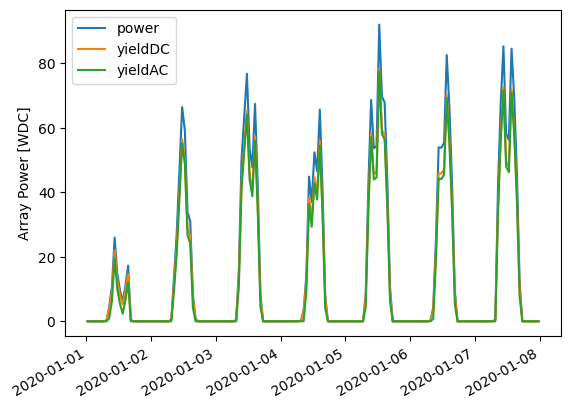

In [136]:
array_power_yield.head(24*7).plot()
plt.ylabel('Array Power [WDC]');

In [137]:
# this function gets yield data for a range of things
def getYieldData(tilt=tilt, gamma_pdc=gamma_pdc, maxPV=pvMaxW, pvInc=50, azimuths=(90,110, 180, 270, 250)):
    """
    Get hourly and daily PV yields for all possible array sizes being modeled,
    at each of the given azimuths.

    Args:
        tilt (float): array tilt angle (degrees).
        gamma_pdc (float): PV temperature coefficient (1/°C).
        maxPV (int): max allowed PV nameplate wattage of any power station
                     in the database (default 1200).
        pvInc (int): increment (W) to step through array sizes (default 50).
        azimuths (iterable of int): azimuth angles to model (default (110, 180, 250)).

    Returns:
        dict: {
            '<azimuth>': {
                '<pW>': {
                    'hourly': <DataFrame from getPowerYield>,
                    'daily': {'dailyDC': [...], 'dailyAC': [...]}
                },
                ...
            },
            ...
        }
    """
    yieldData = {str(a): {} for a in azimuths}

    #print(f'Max PV: {maxPV}')

    for a in azimuths:
        poa = getPOA(tilt, a)

        aData = {}
        for pW in range(pvInc, maxPV + pvInc, pvInc):
            # get hourly power yields for a given array size (W)
            hY = getPowerYield(poa, gamma_pdc, pW)

            # get daily PV yields (Wh)
            # dYDC = []
            # dYAC = []
            # for d in range(365):
            #     dYDC.append(hY['yieldDC'].iloc[d*24:(d*24)+24].sum())
            #     dYAC.append(hY['yieldAC'].iloc[d*24:(d*24)+24].sum())
            dYDC = hY['yieldDC'].to_numpy().reshape(365, 24).sum(axis=1)
            dYAC = hY['yieldAC'].to_numpy().reshape(365, 24).sum(axis=1)

            aData[str(pW)] = {
                'hourly': hY,
                'daily': {'dailyDC': dYDC, 'dailyAC': dYAC}
            }

        yieldData[str(a)] = aData

    return yieldData
    

In [138]:
yieldData = getYieldData()

In [139]:
yieldData['180']['300']

{'hourly':                            power  yieldDC  yieldAC
 2020-01-01 00:30:00-05:00    0.0      0.0      0.0
 2020-01-01 01:30:00-05:00    0.0      0.0      0.0
 2020-01-01 02:30:00-05:00    0.0      0.0      0.0
 2020-01-01 03:30:00-05:00    0.0      0.0      0.0
 2020-01-01 04:30:00-05:00    0.0      0.0      0.0
 ...                          ...      ...      ...
 2020-12-31 19:30:00-05:00    0.0      0.0      0.0
 2020-12-31 20:30:00-05:00    0.0      0.0      0.0
 2020-12-31 21:30:00-05:00    0.0      0.0      0.0
 2020-12-31 22:30:00-05:00    0.0      0.0      0.0
 2020-12-31 23:30:00-05:00    0.0      0.0      0.0
 
 [8760 rows x 3 columns],
 'daily': {'dailyDC': array([ 257.09351585,  737.6373872 , 1088.87248753,  800.50591468,
         1307.54423748, 1005.23655503, 1332.75902973, 1153.38886314,
          364.58896355,  991.56595308,  284.99766127,  316.2207568 ,
          208.73569109,  426.34111292,  216.02742245,   61.53427846,
          475.43599917, 1010.45663393,  88

# Annual Energy Modeling

battery is only charged from the grid when an event is upcoming. This considers average solar in July

In [140]:
def pv_to_stored_charge(pv_w, plugin, acToDC):
    """Energy reaching the battery as stored charge, after conversion losses.
    plugin=True: pv_w is already AC (post-microinverter) -> battery charger (acToDC).
    plugin=False: pv_w is DC -> straight into battery, no conversion loss."""
    return pv_w * acToDC if plugin else pv_w

def battery_to_load(load_wac, iE):
    """AC load converted into the DC draw required from the battery
    (battery inverter, discharge side)."""
    return load_wac / iE

In [141]:
# # version from 5-2
# def simulate_hourly_energy(pvYieldW, batWh, loadWAC, iE, y: int = 0, plugin=True,
#                             dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
#                             LiFePOdod=LiFePOdod, acToDC=acToDC,
#                             chargeTargetFraction=0.8,
#                             drWindowStartHour=None,
#                             maxChargeRateW=1800, maxDischargeRateW=None):
#     """
#     Step through a year hour-by-hour, simulating a charge/discharge cycle
#     capped at once per calendar day, with any grid-sourced charging capped
#     at maxChargeRateW (Wh/hour, AC-side) rather than applied instantly --
#     the number of hours it takes depends on how large the gap is.

#     loadWAC may be either a scalar (constant load every hour, the original
#     behavior) or an array-like of length len(pvYieldW) giving an hourly
#     load profile -- e.g. a load that's only "on" during certain months
#     (see build_seasonal_load_array). Internally it's always expanded to a
#     per-hour array so seasonal and constant loads are handled identically.

#     OFF-GRID discharge triggers: either the battery reaches chargeTarget
#     (80%) after 3pm on a day the cycle hasn't been used yet, OR projected
#     overflow risk (reserving multi-hour headroom based on the trailing
#     week's peak PV hour vs. load size) forces an early discharge to avoid
#     curtailing PV, regardless of time or the daily cap. If discharge was
#     triggered by overflow risk specifically, it reverts back to 'charging'
#     as soon as that risk resolves (rather than waiting for the DoD floor),
#     and frees the daily cycle back up so a normal 80%-target discharge can
#     still happen later that day if conditions call for it.

#     OFF-GRID discharge end: a non-overflow-triggered discharge normally
#     ends at dischargeEndHour (6am), but that cutoff is no longer
#     unconditional -- if the battery doesn't yet have enough headroom
#     (batWh - batState) to absorb the past week's biggest full-day PV total
#     (tracked via pvDailyHistory), the discharge keeps running past 6am,
#     serving the load just enough to open up that much headroom (never more
#     than the load needs or the battery can supply above dodFloor), so the
#     coming day's solar isn't curtailed. Once enough headroom exists, it
#     switches back to 'charging' as before. This is a separate, stricter
#     reserve target than the one used for the daytime overflow trigger
#     below, which only looks at the trailing week's single peak PV hour.

#     PLUG-IN discharge-to-load budget: on any day with a DR window, the
#     battery may only discharge to serve the load, after the window
#     closes, up to the amount of solar actually stored during that window
#     (windowSolarAvailableDC). The discharge-to-load hour range is extended
#     through 6am the next morning (same as the off-grid dischargeEndHour)
#     so this budget isn't stranded right at midnight -- but it's still
#     bounded by the stored-solar amount itself, not by the clock.

#     maxChargeRateW / maxDischargeRateW: AC-side hardware power caps
#     (Wh/hour) that apply ONLY to grid-sourced battery charging and to
#     battery discharge that serves the load -- NOT to PV-to-battery
#     charging, which is left uncapped. This models something like a charger
#     or inverter's rated AC power limit rather than the battery cell's own
#     charge/discharge limit. Because they're AC-side, they're converted
#     through acToDC / iE before being compared against the DC-side battery
#     flows used internally:
#       - charging: capped in DC terms as maxChargeRateW * acToDC, so the
#         resulting AC grid draw (chargeAmount / acToDC) never exceeds
#         maxChargeRateW. Defaults to 1800 (a typical charger AC power
#         rating).
#       - discharging: capped in DC terms as maxDischargeRateW / iE, so the
#         resulting AC output to the load (servedWDC * iE) never exceeds
#         maxDischargeRateW. Defaults to None (no cap).
#     Each cap is enforced independently at each grid-charge / discharge-to-load
#     point rather than as a single combined per-hour budget.

#     PLUG-IN pre-event solar charging: during the DR season, in the hours
#     before each day's grid window opens, any surplus PV (beyond what's
#     needed to serve the load) is used to charge the battery -- but only up
#     to batWh minus a reserve, rather than straight to full. The reserve
#     equals the largest total PV the grid window itself pulled toward the
#     battery on any of the last 7 event-days (tracked as the simulation
#     steps forward, so it only ever looks at past event-days, never today's
#     own window). This way the battery goes into the event already
#     well-charged, while still leaving enough headroom that the window's
#     own PV production isn't curtailed once the event starts.
#     """

#     #battery start state
#     startState=0.5
    
#     # DR season info
#     seasonStartDay = drSeasonStartDay
#     seasonDays = daysInMonth

#     # DR window
#     drWindowLengthHours = 4
#     drWindowEndHour = None
    
#     if drWindowStartHour is not None:
#         drWindowEndHour = drWindowStartHour + drWindowLengthHours

#     # the grid window only applies during the DR season (e.g. May-Sep);
#     # outside the season it behaves as if drWindowStartHour were None
#     seasonStartHour = (seasonStartDay - 1) * 24
#     seasonEndHour = seasonStartHour + (sum(seasonDays) * 24)  # exclusive

#     n = len(pvYieldW)

#     # expand loadWAC to a per-hour array so scalar and seasonal/array loads
#     # are handled by the exact same code path below
#     loadWAC_arr = np.full(n, loadWAC, dtype=float) if np.isscalar(loadWAC) else np.asarray(loadWAC, dtype=float)
#     if len(loadWAC_arr) != n:
#         raise ValueError(f'loadWAC array length ({len(loadWAC_arr)}) must match pvYieldW length ({n})')
#     loadWDC_arr = battery_to_load(loadWAC_arr, iE)

#     dodFloor = batWh * (1 - LiFePOdod)
#     chargeTarget = batWh * chargeTargetFraction
#     hourlyScWDC = dailySelfConsumptionWhDC / 24

#     # AC-side hardware caps, converted to the DC-side units used internally.
#     # None -> effectively unlimited. Only applied to grid charging and to
#     # battery discharge that serves the load -- PV charging is uncapped.
#     chargeCapW_DC = (maxChargeRateW * acToDC) if maxChargeRateW is not None else float('inf')
#     dischargeCapW_DC = (maxDischargeRateW / iE) if maxDischargeRateW is not None else float('inf')

#     batState_arr = np.empty(n)
#     surplus_arr = np.zeros(n)
#     avoided_arr = np.zeros(n)
#     required_arr = np.zeros(n)
#     grid_to_load_arr = np.zeros(n)
#     grid_battery_charge_arr = np.zeros(n)

#     batState = batWh * startState
#     mode = 'charging'
#     dischargeCycleUsedToday = False
#     rechargeCycleUsedToday = False
#     dischargingDueToOverflow = False   # off-grid: tracks whether the current discharge was overflow-triggered

#     floorCharging = False
#     rechargingFromGrid = False

#     pvHistory = deque(maxlen=168) # hourly
#     pvDailyHistory = deque(maxlen=7) # daily
#     dayPVAccumDC = 0.0

#     # trailing week of event-day totals for the plug-in pre-event solar
#     # charging reserve -- see docstring
#     windowPVHistory = deque(maxlen=7)
#     windowPVAccumDC = 0.0

#     # today's actual solar-into-battery total during the DR window, and
#     # the resulting discharge budget once the window closes -- not reset
#     # at midnight, so it survives into the pre-6am tail (see docstring)
#     windowSolarStoredTodayDC = 0.0
#     windowSolarAvailableDC = 0.0

#     dischargeHour = 20 if drWindowEndHour is None else drWindowEndHour
#     dischargeEndHour = 6 

#     for i, h in enumerate(pvYieldW):
#         hourOfDay = i % 24
#         if hourOfDay == 0:
#             dischargeCycleUsedToday = False
#             rechargeCycleUsedToday = False
#             pvDailyHistory.append(dayPVAccumDC)
#             dayPVAccumDC = 0.0

#         pv_w = getDegradedP(h, y)  # PV is already AC if plugin, else it is DC
#         loadWAC = loadWAC_arr[i]
#         loadWDC = loadWDC_arr[i]

#         # check if this hour is within the DR window
#         inSeason = seasonStartHour <= i < seasonEndHour
#         inDRWindow = (
#             drWindowEndHour is not None
#             and inSeason
#             and drWindowStartHour <= hourOfDay < drWindowEndHour
#         )

#         if not plugin:
#             # ---------------- OFF-GRID ----------------
#             stored = pv_w
#             batState += stored - hourlyScWDC   # PV always charges simultaneously, regardless of mode; uncapped
#             pvHistory.append(stored)
#             dayPVAccumDC += stored

#             maxHourlyPVPastWeek = max(pvHistory) if pvHistory else stored
#             maxDailyPVPastWeek = max(pvDailyHistory) if pvDailyHistory else dayPVAccumDC
#             denom = loadWDC if loadWDC > 0 else 1e-6
#             reserve = min(maxHourlyPVPastWeek * (maxHourlyPVPastWeek / denom), batWh)
#             wouldOverflow = (batState + reserve) > batWh
#             hourOfDay = i % 24

#             if mode == 'charging':
#                 reachedTarget = batState >= chargeTarget
#                 #if wouldOverflow or (reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour):
#                 targetTriggered = reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour
#                 if wouldOverflow or targetTriggered:
#                     mode = 'discharging'
#                     dischargeCycleUsedToday = True
#                     #dischargingDueToOverflow = wouldOverflow
#                     dischargingDueToOverflow = wouldOverflow and not targetTriggered
#             elif mode == 'discharging':
#                 if dischargingDueToOverflow and not wouldOverflow:
#                     mode = 'charging'
#                     dischargeCycleUsedToday = False  # frees the cycle back up for a later 3pm+ discharge
#                     dischargingDueToOverflow = False
#                 elif not dischargingDueToOverflow and hourOfDay >= dischargeEndHour:
#                     # past the early-morning cutoff: only switch back to
#                     # charging once there's enough headroom to absorb the
#                     # past week's peak daily PV yield -- otherwise
#                     # keep discharging (see servedWDC branch below) to free
#                     # up room rather than curtailing solar later
#                     headroomWDC = batWh - batState
#                     if headroomWDC >= maxDailyPVPastWeek:
#                         mode = 'charging'

#             if mode == 'charging':
#                 avoided_arr[i] = 0.0
#                 grid_to_load_arr[i] = loadWAC
#             else:  # discharging (serves the load -- AC-side discharge cap applies here)
#                 if inDRWindow:
#                     # grid window: never discharge the battery to serve the
#                     # load, even if a discharge cycle is already underway
#                     if dischargingDueToOverflow:
#                         # still avoid curtailing/wasting PV even during the window,
#                         # but only pull the minimum needed to prevent overflow --
#                         # never a full load-serving discharge
#                         overflowAmount = max(0.0, batState - batWh)
#                         availableWDC = max(0.0, batState - dodFloor)
#                         servedWDC = min(overflowAmount, availableWDC, loadWDC)
#                         if servedWDC > dischargeCapW_DC:
#                             # load exceeds the power station's max discharge rate --
#                             # don't serve a partial amount, put it all on the grid instead
#                             servedWDC = 0.0
#                     else:
#                         # grid window: never voluntarily discharge to serve the load
#                         servedWDC = 0.0
#                 elif hourOfDay >= dischargeHour or hourOfDay < dischargeEndHour:
#                     # after the set discharge time: draw as much as the load needs, normal cycling behavior
#                     availableWDC = max(0.0, batState - dodFloor)
#                     servedWDC = min(loadWDC, availableWDC)
#                     if servedWDC > dischargeCapW_DC:
#                         # load exceeds the power station's max discharge rate --
#                         # don't serve a partial amount, put it all on the grid instead
#                         servedWDC = 0.0
#                 elif not dischargingDueToOverflow:
#                     # extended past 6am (non-overflow discharge, held open by
#                     # the mode-transition check above because there isn't yet
#                     # enough headroom for the past week's peak daily PV
#                     # total): serve just enough to open up that much headroom
#                     targetHeadroomWDC = maxDailyPVPastWeek
#                     neededWDC = max(0.0, targetHeadroomWDC - (batWh - batState))
#                     availableWDC = max(0.0, batState - dodFloor)
#                     servedWDC = min(neededWDC, availableWDC, loadWDC)
#                     if servedWDC > dischargeCapW_DC:
#                         servedWDC = 0.0
#                 else:
#                     # before the set discharge time: only pull what's needed to avoid exceeding capacity
#                     overflowAmount = max(0.0, batState - batWh)
#                     availableWDC = max(0.0, batState - dodFloor)
#                     servedWDC = min(overflowAmount, availableWDC, loadWDC)
#                     if servedWDC > dischargeCapW_DC:
#                         # load exceeds the power station's max discharge rate --
#                         # don't serve a partial amount, put it all on the grid instead
#                         servedWDC = 0.0

#                 batState -= servedWDC
#                 avoided_arr[i] = servedWDC * iE
#                 grid_to_load_arr[i] = loadWAC - avoided_arr[i]

#             # DoD floor safety net, rate-capped instead of instant (grid-sourced -- AC-side charge cap applies)
#             if batState < dodFloor:
#                 floorCharging = True
#             if floorCharging:
#                 gap = dodFloor - batState
#                 chargeAmount = min(gap, chargeCapW_DC)
#                 batState += chargeAmount
#                 required_arr[i] = chargeAmount / acToDC
#                 if batState >= dodFloor:
#                     floorCharging = False

#             # capacity safety net -- true curtailment, should be rare given the overflow check above
#             if batState > batWh:
#                 sur = batState - batWh
#                 surplus_arr[i] = sur * iE
#                 batState = batWh

#             # reaching the DoD floor always ends a discharge cycle, overflow-triggered or not
#             if mode == 'discharging' and batState <= dodFloor:
#                 mode = 'charging'
#                 dischargingDueToOverflow = False

#         else:
#             # ---------------- PLUG-IN ----------------
#             pv_avail_AC = pv_w  # already AC (microinverter output)

#             if inDRWindow:
#                 # grid window: grid fully serves the load; any available PV
#                 # is redirected to charge the battery instead of the load
#                 avoided_arr[i] = 0.0
#                 grid_to_load_arr[i] = loadWAC

#                 # PV -> battery charging: uncapped (not a grid-sourced charge)
#                 pv_to_batt_DC = pv_to_stored_charge(pv_avail_AC, True, acToDC)
#                 windowPVAccumDC += pv_to_batt_DC  # this event-day's running window PV total (estimated)
                
#                 room_DC = max(0.0, batWh - batState)
#                 chargeAmount_DC = min(pv_to_batt_DC, room_DC)
#                 batState += chargeAmount_DC
#                 windowSolarStoredTodayDC += chargeAmount_DC  # actual solar stored this window, for the discharge budget
#                 grid_battery_charge_arr[i] = 0.0  # this charge comes from PV, not the grid
#                 # any PV that couldn't be stored is curtailed/exported
#                 storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
#                 surplus_arr[i] = max(0.0, pv_avail_AC - storedAsPV_AC)

#                 if hourOfDay == drWindowEndHour - 1:
#                     # window just closed for the day -- bank today's total so
#                     # future pre-event charging can reserve room for it
#                     windowPVHistory.append(windowPVAccumDC)
#                     windowPVAccumDC = 0.0
#                     # hand today's actually-stored solar to the post-window
#                     # discharge budget (overwrites any still-unused leftover
#                     # from a prior window), and reset the accumulator for tomorrow
#                     windowSolarAvailableDC = windowSolarStoredTodayDC
#                     windowSolarStoredTodayDC = 0.0
#             else:
#                 servedByPV_AC = min(loadWAC, pv_avail_AC)
#                 avoided_arr[i] = servedByPV_AC  # PV directly serving load is avoided grid draw
#                 remainingLoad_AC = loadWAC - servedByPV_AC
#                 surplus = pv_avail_AC - servedByPV_AC

#                 # evening discharge window, extended through to 6am (mirrors
#                 # the off-grid dischargeEndHour cutoff) so leftover
#                 # window-solar isn't stranded right at midnight -- actual
#                 # amount served is still bounded by windowSolarAvailableDC
#                 # below, so this alone can't over-discharge
#                 canDischargeForLoad = (hourOfDay >= dischargeHour) or (hourOfDay < dischargeEndHour)

#                 if rechargingFromGrid:
#                     # grid-sourced charging -- AC-side charge cap applies
#                     gap = chargeTarget - batState
#                     chargeAmount = min(gap, chargeCapW_DC)
#                     batState += chargeAmount
#                     chargeAmtAC = chargeAmount / acToDC
#                     usefulOutputAC = chargeAmount * iE
#                     surplus_arr[i] = max(0, surplus - chargeAmtAC)
#                     grid_battery_charge_arr[i] = chargeAmtAC
#                     required_arr[i] = chargeAmtAC - usefulOutputAC
#                     grid_to_load_arr[i] = remainingLoad_AC
#                     if batState >= chargeTarget:
#                         rechargingFromGrid = False
#                 else:
#                     if canDischargeForLoad:
#                         surplus_arr[i] = surplus
#                         # discharge serving the load -- AC-side discharge cap applies
#                         remainingLoadWDC = remainingLoad_AC / iE
#                         availableWDC = max(0.0, batState - dodFloor)
#                         capWDC = availableWDC
#                         # cap discharge to the window-solar budget whenever
#                         # we're in-season -- today could still bank a window,
#                         # or we're in the pre-6am tail of a window banked
#                         # the evening before
#                         windowCapApplies = (drWindowStartHour is not None)
#                         if windowCapApplies:
#                             capWDC = min(capWDC, windowSolarAvailableDC)
#                         servedWDC = min(remainingLoadWDC, capWDC)
#                         if servedWDC > dischargeCapW_DC:
#                             # load exceeds the power station's max discharge rate --
#                             # don't serve a partial amount, put it all on the grid instead
#                             servedWDC = 0.0
#                         batState -= servedWDC
#                         if windowCapApplies:
#                             windowSolarAvailableDC -= servedWDC
#                         grid_to_load_arr[i] = remainingLoad_AC - (servedWDC * iE)
#                     else:
#                         # before the event window (or off-season / no window
#                         # configured): use surplus solar to pre-charge the
#                         # battery ahead of the event, but leave headroom for
#                         # the window's own expected PV (see windowPVHistory
#                         # in the docstring) so it isn't curtailed once the
#                         # event starts
#                         if inSeason and drWindowStartHour is not None and surplus > 0:
#                             windowPVReserveWDC = max(windowPVHistory) if windowPVHistory else 0.0
#                             target_DC = max(0.0, batWh - windowPVReserveWDC)
#                             room_DC = max(0.0, target_DC - batState)
#                             pv_to_batt_DC = pv_to_stored_charge(surplus, True, acToDC)
#                             chargeAmount_DC = min(pv_to_batt_DC, room_DC)
#                             batState += chargeAmount_DC
#                             storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
#                             surplus_arr[i] = max(0.0, surplus - storedAsPV_AC)
#                         else:
#                             surplus_arr[i] = surplus
#                         # grid covers whatever PV (directly, or after pre-charging) didn't
#                         grid_to_load_arr[i] = remainingLoad_AC

#             batState -= hourlyScWDC

#             # keep the battery above DoD
#             if not rechargingFromGrid and batState < dodFloor:
#                 topOff = dodFloor - max(batState, 0)
#                 required_arr[i] += topOff / acToDC
#                 batState = dodFloor

#             if batState <= dodFloor and not rechargeCycleUsedToday and not rechargingFromGrid:
#                 rechargingFromGrid = True
#                 rechargeCycleUsedToday = True

#         batState_arr[i] = batState

#     return {
#         'batState': batState_arr, # state of the battery WhDC
#         'surplusWhAC': surplus_arr, #unused energy
#         'avoidedGridWhAC': avoided_arr, #energy consumed by load that didn't come from the grid (from PV)
#         'requiredGridWhAC': required_arr, # energy required to maintain battery
#         'grid_to_loadWhAC': grid_to_load_arr, # energy drawn from the grid to run the load
#         'gridBatteryChargeWhAC': grid_battery_charge_arr, #more energy from grid for battery (for periodic top off?)
#     }

In [142]:
# UPDATED 9/11
# heuristic w/ the CSRP and DLRP fix
    
def simulate_hourly_energy(pvYieldW, batWh, loadWAC, iE, y: int = 0, plugin=True,
                            dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
                            LiFePOdod=LiFePOdod, acToDC=acToDC,
                            chargeTargetFraction=0.8,
                            drWindowStartHour=None,
                            maxChargeRateW=1800, maxDischargeRateW=None):
    """
    Step through a year hour-by-hour, simulating a charge/discharge cycle
    capped at once per calendar day, with any grid-sourced charging capped
    at maxChargeRateW (Wh/hour, AC-side) rather than applied instantly --
    the number of hours it takes depends on how large the gap is.

    loadWAC may be either a scalar (constant load every hour, the original
    behavior) or an array-like of length len(pvYieldW) giving an hourly
    load profile -- e.g. a load that's only "on" during certain months
    (see build_seasonal_load_array). Internally it's always expanded to a
    per-hour array so seasonal and constant loads are handled identically.

    OFF-GRID discharge triggers: either the battery reaches chargeTarget
    (80%) after 3pm on a day the cycle hasn't been used yet, OR projected
    overflow risk (reserving multi-hour headroom based on the trailing
    week's peak PV hour vs. load size) forces an early discharge to avoid
    curtailing PV, regardless of time or the daily cap. If discharge was
    triggered by overflow risk specifically, it reverts back to 'charging'
    as soon as that risk resolves (rather than waiting for the DoD floor),
    and frees the daily cycle back up so a normal 80%-target discharge can
    still happen later that day if conditions call for it.

    OFF-GRID discharge end: a non-overflow-triggered discharge normally
    ends at dischargeEndHour (6am), but that cutoff is no longer
    unconditional -- if the battery doesn't yet have enough headroom
    (batWh - batState) to absorb the past week's biggest full-day PV total
    (tracked via pvDailyHistory), the discharge keeps running past 6am,
    serving the load just enough to open up that much headroom (never more
    than the load needs or the battery can supply above dodFloor), so the
    coming day's solar isn't curtailed. Once enough headroom exists, it
    switches back to 'charging' as before. This is a separate, stricter
    reserve target than the one used for the daytime overflow trigger
    below, which only looks at the trailing week's single peak PV hour.

    PLUG-IN discharge-to-load budget: on any day with a DR window, the
    battery may only discharge to serve the load, after the window
    closes, up to the amount of solar actually stored during that window
    (windowSolarAvailableDC). The discharge-to-load hour range is extended
    through 6am the next morning (same as the off-grid dischargeEndHour)
    so this budget isn't stranded right at midnight -- but it's still
    bounded by the stored-solar amount itself, not by the clock.

    maxChargeRateW / maxDischargeRateW: AC-side hardware power caps
    (Wh/hour) that apply ONLY to grid-sourced battery charging and to
    battery discharge that serves the load -- NOT to PV-to-battery
    charging, which is left uncapped. This models something like a charger
    or inverter's rated AC power limit rather than the battery cell's own
    charge/discharge limit. Because they're AC-side, they're converted
    through acToDC / iE before being compared against the DC-side battery
    flows used internally:
      - charging: capped in DC terms as maxChargeRateW * acToDC, so the
        resulting AC grid draw (chargeAmount / acToDC) never exceeds
        maxChargeRateW. Defaults to 1800 (a typical charger AC power
        rating).
      - discharging: capped in DC terms as maxDischargeRateW / iE, so the
        resulting AC output to the load (servedWDC * iE) never exceeds
        maxDischargeRateW. Defaults to None (no cap).
    Each cap is enforced independently at each grid-charge / discharge-to-load
    point rather than as a single combined per-hour budget.

    PLUG-IN pre-event solar charging: during the DR season, in the hours
    before each day's grid window opens, any surplus PV (beyond what's
    needed to serve the load) is used to charge the battery -- but only up
    to batWh minus a reserve, rather than straight to full. The reserve
    equals the largest total PV the grid window itself pulled toward the
    battery on any of the last 7 event-days (tracked as the simulation
    steps forward, so it only ever looks at past event-days, never today's
    own window). This way the battery goes into the event already
    well-charged, while still leaving enough headroom that the window's
    own PV production isn't curtailed once the event starts.
    """

    #battery start state
    startState=0.5
    
    # DR season info
    seasonStartDay = drSeasonStartDay
    seasonDays = daysInMonth

    # DR window
    drWindowLengthHours = 4
    drWindowEndHour = None
    dlrpWindowStartHour = None
    dlrpWindowEndHour = None
    
    if drWindowStartHour is not None:
        drWindowEndHour = drWindowStartHour + drWindowLengthHours # original
    # fixed DLRP window, always 16:00-20:00, independent of CSRP timing
        dlrpWindowStartHour = 16
        dlrpWindowEndHour = 20

    # the grid window only applies during the DR season (e.g. May-Sep);
    # outside the season it behaves as if drWindowStartHour were None
    seasonStartHour = (seasonStartDay - 1) * 24
    seasonEndHour = seasonStartHour + (sum(seasonDays) * 24)  # exclusive

    n = len(pvYieldW)

    # expand loadWAC to a per-hour array so scalar and seasonal/array loads
    # are handled by the exact same code path below
    loadWAC_arr = np.full(n, loadWAC, dtype=float) if np.isscalar(loadWAC) else np.asarray(loadWAC, dtype=float)
    if len(loadWAC_arr) != n:
        raise ValueError(f'loadWAC array length ({len(loadWAC_arr)}) must match pvYieldW length ({n})')
    loadWDC_arr = battery_to_load(loadWAC_arr, iE)

    dodFloor = batWh * (1 - LiFePOdod)
    chargeTarget = batWh * chargeTargetFraction
    hourlyScWDC = dailySelfConsumptionWhDC / 24

    # AC-side hardware caps, converted to the DC-side units used internally.
    # None -> effectively unlimited. Only applied to grid charging and to
    # battery discharge that serves the load -- PV charging is uncapped.
    chargeCapW_DC = (maxChargeRateW * acToDC) if maxChargeRateW is not None else float('inf')
    dischargeCapW_DC = (maxDischargeRateW / iE) if maxDischargeRateW is not None else float('inf')

    batState_arr = np.empty(n) #bat state
    surplus_arr = np.zeros(n) #pv to grid
    avoided_arr = np.zeros(n) #pv to load
    required_arr = np.zeros(n) # grid to battery - all energy in off-gri
    grid_to_load_arr = np.zeros(n) # grid to load
    grid_battery_charge_arr = np.zeros(n) # grid to battery in plug-in only
    pv_to_battery_arr = np.zeros(n) # pv to battery
    battery_to_load_arr = np.zeros(n) # inverter output - only used in plug-in - duplicates avoided energy

    batState = batWh * startState
    mode = 'charging'
    dischargeCycleUsedToday = False
    rechargeCycleUsedToday = False
    dischargingDueToOverflow = False   # off-grid: tracks whether the current discharge was overflow-triggered

    floorCharging = False
    rechargingFromGrid = False

    # added to ensure weekly recharge
    forceWeeklyRecharge = False   # True when the current recharge cycle was triggered by the 7-day requirement
    hoursSinceReached80 = 0       # hours since batState last reached chargeTarget (80%)
    weeklyReachTargetHours = 7 * 24

    pvHistory = deque(maxlen=168) # hourly
    pvDailyHistory = deque(maxlen=7) # daily
    dayPVAccumDC = 0.0

    # trailing week of event-day totals for the plug-in pre-event solar
    # charging reserve -- see docstring
    windowPVHistory = deque(maxlen=7)
    windowPVAccumDC = 0.0
    windowPVAccumFromStartDC = 0.0  # duplicate of windowPVAccumDC, but reset at window start instead of window end

    # today's actual solar-into-battery total during the DR window, and
    # the resulting discharge budget once the window closes -- not reset
    # at midnight, so it survives into the pre-6am tail (see docstring)
    windowSolarStoredTodayDC = 0.0
    windowSolarAvailableDC = 0.0

    # the last event hour of the day, across both windows -- used to trigger
    # the once-per-day bank/reset of the shared accumulator
    lastDRHourOfDay = max(
        (drWindowEndHour if drWindowEndHour is not None else -1),
        (dlrpWindowEndHour if dlrpWindowEndHour is not None else -1),
    ) - 1

    dischargeHour = max(
        (drWindowEndHour if drWindowEndHour is not None else 0),
        (dlrpWindowEndHour if dlrpWindowEndHour is not None else 0),
    )
    dischargeEndHour = 6 

    for i, h in enumerate(pvYieldW):
        hourOfDay = i % 24
        if hourOfDay == 0:
            dischargeCycleUsedToday = False
            rechargeCycleUsedToday = False
            pvDailyHistory.append(dayPVAccumDC)
            dayPVAccumDC = 0.0
        
        pv_w = getDegradedP(h, y)  # PV is already AC if plugin, else it is DC
        #pv_w = h  # PV is already AC if plugin, else it is DC
        loadWAC = loadWAC_arr[i]
        loadWDC = loadWDC_arr[i]

        # check if this hour is within either DR window
        inSeason = seasonStartHour <= i < seasonEndHour
        inCSRPWindow = (
            drWindowEndHour is not None
            and inSeason
            and drWindowStartHour <= hourOfDay < drWindowEndHour
        )
        inDLRPWindow = (
            dlrpWindowEndHour is not None
            and inSeason
            and dlrpWindowStartHour <= hourOfDay < dlrpWindowEndHour
        )
        inDRWindow = inCSRPWindow or inDLRPWindow

        if not plugin:
            # ---------------- OFF-GRID ----------------
            stored = pv_w
            batState += stored - hourlyScWDC   # PV always charges simultaneously, regardless of mode; uncapped
            pvHistory.append(stored)
            dayPVAccumDC += stored
            pv_to_battery_arr[i] = stored  

            maxHourlyPVPastWeek = max(pvHistory) if pvHistory else stored
            maxDailyPVPastWeek = max(pvDailyHistory) if pvDailyHistory else dayPVAccumDC
            denom = loadWDC if loadWDC > 0 else 1e-6
            reserve = min(maxHourlyPVPastWeek * (maxHourlyPVPastWeek / denom), batWh)
            wouldOverflow = (batState + reserve) > batWh
            hourOfDay = i % 24

            # replaced this commented out condition with the following condition on 9/24
            # if mode == 'charging':
            #     reachedTarget = batState >= chargeTarget
            #     #if wouldOverflow or (reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour):
            #     targetTriggered = reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour
            #     if wouldOverflow or targetTriggered:
            #         mode = 'discharging'
            #         dischargeCycleUsedToday = True
            #         #dischargingDueToOverflow = wouldOverflow
            #         dischargingDueToOverflow = wouldOverflow and not targetTriggered
            if forceWeeklyRecharge:
                # 7-day top-off in progress -- hold in charging mode so a
                # discharge doesn't fight the grid recharge; normal trigger
                # logic resumes once the battery reaches chargeTarget
                mode = 'charging'
                dischargingDueToOverflow = False
            elif mode == 'charging':
                reachedTarget = batState >= chargeTarget
                #if wouldOverflow or (reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour):
                targetTriggered = reachedTarget and not dischargeCycleUsedToday and hourOfDay >= dischargeHour
                if wouldOverflow or targetTriggered:
                    mode = 'discharging'
                    dischargeCycleUsedToday = True
                    #dischargingDueToOverflow = wouldOverflow
                    dischargingDueToOverflow = wouldOverflow and not targetTriggered
            elif mode == 'discharging':
                if dischargingDueToOverflow and not wouldOverflow:
                    mode = 'charging'
                    dischargeCycleUsedToday = False  # frees the cycle back up for a later 3pm+ discharge
                    dischargingDueToOverflow = False
                elif not dischargingDueToOverflow and hourOfDay >= dischargeEndHour:
                    # past the early-morning cutoff: only switch back to
                    # charging once there's enough headroom to absorb the
                    # past week's peak daily PV yield -- otherwise
                    # keep discharging (see servedWDC branch below) to free
                    # up room rather than curtailing solar later
                    headroomWDC = batWh - batState
                    if headroomWDC >= maxDailyPVPastWeek:
                        mode = 'charging'

            if mode == 'charging':
                avoided_arr[i] = 0.0
                grid_to_load_arr[i] = loadWAC
            else:  # discharging (serves the load -- AC-side discharge cap applies here)
                if inDRWindow:
                    # grid window: never discharge the battery to serve the
                    # load, even if a discharge cycle is already underway
                    if dischargingDueToOverflow:
                        # still avoid curtailing/wasting PV even during the window,
                        # but only pull the minimum needed to prevent overflow --
                        # never a full load-serving discharge
                        overflowAmount = max(0.0, batState - batWh)
                        availableWDC = max(0.0, batState - dodFloor)
                        servedWDC = min(overflowAmount, availableWDC, loadWDC)
                        if servedWDC > dischargeCapW_DC:
                            # load exceeds the power station's max discharge rate --
                            # don't serve a partial amount, put it all on the grid instead
                            servedWDC = 0.0
                    else:
                        # grid window: never voluntarily discharge to serve the load
                        servedWDC = 0.0
                elif hourOfDay >= dischargeHour or hourOfDay < dischargeEndHour:
                    # after the set discharge time: draw as much as the load needs, normal cycling behavior
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(loadWDC, availableWDC)
                    if servedWDC > dischargeCapW_DC:
                        # load exceeds the power station's max discharge rate --
                        # don't serve a partial amount, put it all on the grid instead
                        servedWDC = 0.0
                elif not dischargingDueToOverflow:
                    # extended past 6am (non-overflow discharge, held open by
                    # the mode-transition check above because there isn't yet
                    # enough headroom for the past week's peak daily PV
                    # total): serve just enough to open up that much headroom
                    targetHeadroomWDC = maxDailyPVPastWeek
                    neededWDC = max(0.0, targetHeadroomWDC - (batWh - batState))
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(neededWDC, availableWDC, loadWDC)
                    if servedWDC > dischargeCapW_DC:
                        servedWDC = 0.0
                else:
                    # before the set discharge time: only pull what's needed to avoid exceeding capacity
                    overflowAmount = max(0.0, batState - batWh)
                    availableWDC = max(0.0, batState - dodFloor)
                    servedWDC = min(overflowAmount, availableWDC, loadWDC)
                    if servedWDC > dischargeCapW_DC:
                        # load exceeds the power station's max discharge rate --
                        # don't serve a partial amount, put it all on the grid instead
                        servedWDC = 0.0

                batState -= servedWDC
                avoided_arr[i] = servedWDC * iE
                battery_to_load_arr[i] = servedWDC * iE # redundant in the offgrid config, but at least the data is correct
                grid_to_load_arr[i] = loadWAC - avoided_arr[i]

            # replaced this block on 9/24 to enable a weekly top off, while avoiding event window draw
            # # DoD floor safety net, rate-capped instead of instant (grid-sourced -- AC-side charge cap applies)
            # if batState < dodFloor:
            #     floorCharging = True
            # if floorCharging:
            #     gap = dodFloor - batState
            #     chargeAmount = min(gap, chargeCapW_DC)
            #     batState += chargeAmount
            #     required_arr[i] = chargeAmount / acToDC
            #     if batState >= dodFloor:
            #         floorCharging = False
            if batState < dodFloor:
                floorCharging = True
            if floorCharging or forceWeeklyRecharge:
                if forceWeeklyRecharge and not inDRWindow:
                    gridChargeTarget = chargeTarget
                else:
                    gridChargeTarget = dodFloor   # floor maintenance only (always allowed)
                gap = max(0.0, gridChargeTarget - batState)
                chargeAmount = min(gap, chargeCapW_DC)
                batState += chargeAmount
                required_arr[i] = chargeAmount / acToDC
                if batState >= dodFloor:
                    floorCharging = False
                if forceWeeklyRecharge and batState >= chargeTarget:
                    forceWeeklyRecharge = False

            # capacity safety net -- true curtailment, should be rare given the overflow check above
            if batState > batWh:
                sur = batState - batWh
                surplus_arr[i] = sur * iE
                batState = batWh
                pv_to_battery_arr[i] = max(0.0, stored - sur) 

            # reaching the DoD floor always ends a discharge cycle, overflow-triggered or not
            if mode == 'discharging' and batState <= dodFloor:
                mode = 'charging'
                dischargingDueToOverflow = False

            # rolling 7-day requirement: force a grid recharge to
            # chargeTarget (80%) if the battery hasn't reached it within the
            # last 168 hours (mirrors the plug-in logic below)
            if batState >= chargeTarget:
                hoursSinceReached80 = 0
            else:
                hoursSinceReached80 += 1
                if hoursSinceReached80 >= weeklyReachTargetHours:
                    forceWeeklyRecharge = True

        else:
            # ---------------- PLUG-IN ----------------
            pv_avail_AC = pv_w  # already AC (microinverter output)

            if inDRWindow:
                # grid window: grid fully serves the load; any available PV
                # is redirected to charge the battery instead of the load
                avoided_arr[i] = 0.0
                grid_to_load_arr[i] = loadWAC

                # # added for the controls comparison
                # if hourOfDay == drWindowStartHour:
                #     # window just opened -- start a fresh from-start accumulation
                #     windowPVAccumFromStartDC = 0.0

                # PV -> battery charging: uncapped (not a grid-sourced charge)
                pv_to_batt_DC = pv_to_stored_charge(pv_avail_AC, True, acToDC)
                windowPVAccumDC += pv_to_batt_DC  # this event-day's running window PV total (estimated)
                windowPVAccumFromStartDC = windowPVAccumDC
                
                room_DC = max(0.0, batWh - batState)
                chargeAmount_DC = min(pv_to_batt_DC, room_DC)
                batState += chargeAmount_DC
                pv_to_battery_arr[i] = chargeAmount_DC   # PV actually stored during the window
                windowSolarStoredTodayDC += chargeAmount_DC  # actual solar stored this window, for the discharge budget
                grid_battery_charge_arr[i] = 0.0  # this charge comes from PV, not the grid
                # any PV that couldn't be stored is curtailed/exported
                storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
                surplus_arr[i] = max(0.0, pv_avail_AC - storedAsPV_AC)

                if hourOfDay == lastDRHourOfDay:
                    # window just closed for the day -- bank today's total so
                    # future pre-event charging can reserve room for it
                    windowPVHistory.append(windowPVAccumDC)
                    windowPVAccumDC = 0.0
                    # hand today's actually-stored solar to the post-window
                    # discharge budget (overwrites any still-unused leftover
                    # from a prior window), and reset the accumulator for tomorrow
                    windowSolarAvailableDC = windowSolarStoredTodayDC
                    windowSolarStoredTodayDC = 0.0
            else:
                # added for the controls comparison
                if not inSeason:
                    windowPVAccumFromStartDC = 0.0 # this ensures it will be zeroed when not in season

                servedByPV_AC = min(loadWAC, pv_avail_AC)
                avoided_arr[i] = servedByPV_AC  # PV directly serving load is avoided grid draw
                remainingLoad_AC = loadWAC - servedByPV_AC
                surplus = pv_avail_AC - servedByPV_AC

                # evening discharge window, extended through to 6am (mirrors
                # the off-grid dischargeEndHour cutoff) so leftover
                # window-solar isn't stranded right at midnight -- actual
                # amount served is still bounded by windowSolarAvailableDC
                # below, so this alone can't over-discharge
                canDischargeForLoad = (hourOfDay >= dischargeHour) or (hourOfDay < dischargeEndHour)

                if rechargingFromGrid:
                    # grid-sourced charging -- AC-side charge cap applies
                    if forceWeeklyRecharge:
                        # 7-day requirement overrides the headroom reservation --
                        # charge all the way to the real chargeTarget (80%), not
                        # just the event-headroom-adjusted effective target
                        effectiveTarget = chargeTarget
                    else:
                        effectiveTarget = max(dodFloor, min(chargeTarget, batWh - windowPVAccumFromStartDC))
                        
                    # grid-sourced charging -- AC-side charge cap applies
                    # gap = chargeTarget - batState # this was the original line
                    #effectiveTarget = max(dodFloor, min(chargeTarget, batWh - windowPVAccumFromStartDC))
                    # gap = effectiveTarget - batState # new line to ensure headroom for events
                    # chargeAmount = min(gap, chargeCapW_DC)
                    # batState += chargeAmount
                    # chargeAmtAC = chargeAmount / acToDC
                    # usefulOutputAC = chargeAmount * iE
                    # surplus_arr[i] = max(0, surplus - chargeAmtAC)
                    # grid_battery_charge_arr[i] = chargeAmtAC
                    # required_arr[i] = chargeAmtAC - usefulOutputAC
                    # grid_to_load_arr[i] = remainingLoad_AC
                    gap = max(0.0, effectiveTarget - batState)
                    chargeAmount = min(gap, chargeCapW_DC)
                    batState += chargeAmount
                    chargeAmtAC = chargeAmount / acToDC

                    # added 9/24 to split the charge: surplus PV feeds the charger first, grid covers the rest
                    pvChargeAC = min(max(0.0, surplus), max(0.0, chargeAmtAC))
                    gridChargeAC = chargeAmtAC - pvChargeAC

                    surplus_arr[i] = max(0.0, surplus - pvChargeAC)
                    grid_battery_charge_arr[i] = gridChargeAC
                    pv_to_battery_arr[i] = pvChargeAC * acToDC
                    # conversion loss on the grid-sourced portion only
                    required_arr[i] = gridChargeAC - (gridChargeAC * acToDC * iE)
                    grid_to_load_arr[i] = remainingLoad_AC
                    
                    if batState >= effectiveTarget:#chargeTarget:
                        rechargingFromGrid = False
                        forceWeeklyRecharge = False
                else:
                    if canDischargeForLoad:
                        surplus_arr[i] = surplus
                        # discharge serving the load -- AC-side discharge cap applies
                        remainingLoadWDC = remainingLoad_AC / iE
                        availableWDC = max(0.0, batState - dodFloor)
                        capWDC = availableWDC
                        # cap discharge to the window-solar budget whenever
                        # we're in-season -- today could still bank a window,
                        # or we're in the pre-6am tail of a window banked
                        # the evening before
                        windowCapApplies = (drWindowStartHour is not None)
                        if windowCapApplies:
                            capWDC = min(capWDC, windowSolarAvailableDC)
                        servedWDC = min(remainingLoadWDC, capWDC)
                        if servedWDC > dischargeCapW_DC:
                            # load exceeds the power station's max discharge rate --
                            # don't serve a partial amount, put it all on the grid instead
                            servedWDC = 0.0
                        batState -= servedWDC
                        battery_to_load_arr[i] = servedWDC * iE
                        if windowCapApplies:
                            windowSolarAvailableDC -= servedWDC
                        grid_to_load_arr[i] = remainingLoad_AC - (servedWDC * iE)
                    else:
                        # before the event window (or off-season / no window
                        # configured): use surplus solar to pre-charge the
                        # battery ahead of the event, but leave headroom for
                        # the window's own expected PV (see windowPVHistory
                        # in the docstring) so it isn't curtailed once the
                        # event starts
                        if inSeason and drWindowStartHour is not None and surplus > 0:
                            windowPVReserveWDC = max(windowPVHistory) if windowPVHistory else 0.0
                            target_DC = max(0.0, batWh - windowPVReserveWDC)
                            room_DC = max(0.0, target_DC - batState)
                            pv_to_batt_DC = pv_to_stored_charge(surplus, True, acToDC)
                            chargeAmount_DC = min(pv_to_batt_DC, room_DC)
                            batState += chargeAmount_DC
                            pv_to_battery_arr[i] = chargeAmount_DC   # PV actually stored during the window
                            storedAsPV_AC = chargeAmount_DC / acToDC if acToDC else 0.0
                            surplus_arr[i] = max(0.0, surplus - storedAsPV_AC)
                        else:
                            surplus_arr[i] = surplus
                        # grid covers whatever PV (directly, or after pre-charging) didn't
                        grid_to_load_arr[i] = remainingLoad_AC

            justReachedTarget = (batState >= chargeTarget) # ensures recharge target is recorded properly, without self-consumption
            
            batState -= hourlyScWDC

            # keep the battery above DoD
            if not rechargingFromGrid and batState < dodFloor:
                topOff = dodFloor - max(batState, 0)
                required_arr[i] += topOff / acToDC
                batState = dodFloor

            if batState <= dodFloor and not rechargeCycleUsedToday and not rechargingFromGrid:
                rechargingFromGrid = True
                rechargeCycleUsedToday = True

            # rolling 7-day requirement: force a full recharge to chargeTarget
            # (80%) if the battery hasn't reached it within the last 168 hours,
            # mirroring the optimization model's weeklyChargeRequirement
            # if batState >= chargeTarget:
            #     hoursSinceReached80 = 0
            if justReachedTarget:
                hoursSinceReached80 = 0
            else:
                hoursSinceReached80 += 1
                if hoursSinceReached80 >= weeklyReachTargetHours:
                    rechargingFromGrid = True
                    forceWeeklyRecharge = True

        batState_arr[i] = batState

    if plugin:
        self_supplied_arr = avoided_arr + battery_to_load_arr
    else:
        self_supplied_arr = avoided_arr.copy()

    return {
        'batState': batState_arr, # state of the battery WhDC
        'surplusWhAC': surplus_arr, #unused energy
        'avoidedGridWhAC': avoided_arr, #energy consumed by load that didn't come from the grid (from PV)
        'requiredGridWhAC': required_arr, # energy required to maintain battery
        'grid_to_loadWhAC': grid_to_load_arr, # energy drawn from the grid to run the load
        'gridBatteryChargeWhAC': grid_battery_charge_arr, #more energy from grid for battery (for periodic top off) - plug-in only
        #'gridToBatteryWhAC': grid_to_battery_arr, # all AC grid energy into the battery, both modes
        #'pvToBatteryWhDC': pv_to_battery_arr, # PV energy actually stored in the battery (WhDC, excludes curtailed PV)
        'batteryToLoadWhAC': battery_to_load_arr, # battery discharge serving the load (WhAC)
        'selfSuppliedWhAC': self_supplied_arr,
    }

In [143]:
# depreciated, but keep anyway
def build_seasonal_load_array(loadW, n_hours=None,
                               season_start_day=drSeasonStartDay,
                               season_days=daysInMonth):
    """
    Build an hourly load array for a full year (or n_hours, if given).

    seasonal=False: load is constant, on all year round (e.g. a fridge --
    always drawing power, so PV/battery should offset it every month).
    seasonal=True: load is only "on" during the DR season (by default May 1
    through Sep 30, i.e. day season_start_day through
    season_start_day + sum(season_days) - 1) and zero the rest of the year
    (e.g. an AC unit that isn't in use outside the DR season).

    Returns a numpy array of length n_hours (default 365*24 = 8760).
    """
    if n_hours is None:
        n_hours = 365 * 24

    # if loadW is already an array (not a single number), just return
    # it as-is instead of broadcasting it as a constant.
    if not np.isscalar(loadW):
        arr = np.asarray(loadW, dtype=float)
        if len(arr) != n_hours:
            raise ValueError(
                f"loadW array length ({len(arr)}) must match n_hours ({n_hours})"
            )
        return arr

    season_len_days = sum(season_days)
    season_start_hour = (season_start_day - 1) * 24
    season_end_hour = season_start_hour + (season_len_days * 24)  # exclusive

    arr = np.zeros(n_hours, dtype=float)
    lo = max(0, season_start_hour)
    hi = min(n_hours, season_end_hour)
    if lo < hi:
        arr[lo:hi] = loadW
    return arr

In [144]:
# Load the ResStock load data (average across the unique NYC multifamily buildings

ac_path = max(glob.glob("data/ResStock_loads/ac_hourly_W_with_average_and_medoid_*.csv"))
print("Using AC file:", ac_path)

fridge_path = max(glob.glob("data/ResStock_loads/fridge_hourly_W_with_average_and_medoid_*.csv"))
print("Using fridge file:", fridge_path)


ac_df = pd.read_csv(ac_path, index_col=0, parse_dates=True)
ac_hourly_W = ac_df["average"].to_numpy()

fridge_df = pd.read_csv(fridge_path, index_col=0, parse_dates=True)
fridge_hourly_W = fridge_df["average"].to_numpy()

# just needed to match the length
hourly_array_power_yield_test=yieldData[str(180)]['100']['hourly']['yieldAC']

n_hours_model = len(hourly_array_power_yield_test)  # match whichever variable your loop actually uses
assert len(fridge_hourly_W) == n_hours_model, (
    f"fridge array length ({len(fridge_hourly_W)}) != model hours ({n_hours_model})"
)

assert len(ac_hourly_W) == n_hours_model, (
    f"ac array length ({len(ac_hourly_W)}) != model hours ({n_hours_model})"
)

loads = {
    'loadOneW': ac_hourly_W,        # AC — ResStock hourly profile (avg of unique buildings)
    'loadTwoW': fridge_hourly_W,   # fridge — ResStock hourly profile (avg of unique buildings)
    'loadOneW_Replacement': ac_hourly_W,    # fan — still fixed, unchanged for now
}

FAN_REPLACEMENT_W = 75  # only used as drFlexValue's replacement_kW, never as an hourly array
loadOneReplacement_kW = FAN_REPLACEMENT_W * .001

# minus 2 to ignore the mean and medoid columns in the data
print(f"Fridge array: {fridge_df.shape[1] - 2} buildings averaged, "
      f"annual mean {fridge_hourly_W.mean():.1f} W, peak {fridge_hourly_W.max():.1f} W")

print(f"AC array: {ac_df.shape[1] - 2} buildings averaged, "
      f"annual mean {ac_hourly_W.mean():.1f} W, peak {ac_hourly_W.max():.1f} W")

Using AC file: data/ResStock_loads\ac_hourly_W_with_average_and_medoid_20260724_173230.csv
Using fridge file: data/ResStock_loads\fridge_hourly_W_with_average_and_medoid_20260724_173230.csv
Fridge array: 7 buildings averaged, annual mean 88.5 W, peak 114.9 W
AC array: 100 buildings averaged, annual mean 93.8 W, peak 549.2 W


In [145]:
# # export load profiles for Homer - not needed for a normal run

# def ts():
#     """Timestamp string for filenames, e.g. 20260923_143005"""
#     return datetime.now().strftime("%Y%m%d_%H%M%S")

# def to_homer_kw(values_W, name):
#     """Return 8760 hourly kW values for HOMER from an hourly W profile."""
#     arr = np.asarray(values_W, dtype=float).ravel()

#     if len(arr) == 8784:        # leap year: drop Feb 29 (hours 1416-1439)
#         arr = np.delete(arr, np.s_[59*24:60*24])
#     elif len(arr) == 24:        # daily profile: repeat for every day
#         arr = np.tile(arr, 365)

#     if len(arr) != 8760:
#         raise ValueError(f"{name}: {len(arr)} values -- expected 8760, 8784, or 24")

#     n_missing = np.isnan(arr).sum()
#     if n_missing:
#         arr = pd.Series(arr).interpolate(limit_direction="both").to_numpy()
#         print(f"{name}: filled {n_missing} missing hours")

#     return np.clip(arr, 0, None) / 1000.0   # W -> kW

# homer_loads = {name: to_homer_kw(vals, name) for name, vals in loads.items()}

# for name, kw in homer_loads.items():
#     print(f"{name:22s} annual: {kw.sum():8.1f} kWh/yr | avg: {kw.sum()/365:6.3f} kWh/day | peak: {kw.max():.3f} kW")

# # save loads for homer
# stamp = ts()   # one timestamp so the files from this export stay grouped together

# for name, kw in homer_loads.items():
#     out_path = f"economic_results_validation/homer_load_{name}_{stamp}.txt"
#     pd.Series(kw).to_csv(out_path, index=False, header=False, float_format="%.6f")
#     print(f"Saved: {out_path}")

In [146]:
# returns the sum of all energy consumed by the load in a year
def annual_total_kWh(hourly_W, n_hours=8760):
    """
    True annual total energy (kWh AC) for a load.

    hourly_W may be a scalar (original behavior: assumes n_hours of
    constant draw) or an array-like of real hourly values, in which case
    it's summed directly rather than reconstructed from an average --
    exact regardless of the array's actual length, instead of relying on
    a hardcoded 8760 lining up with a separately-computed mean.
    """
    if np.isscalar(hourly_W):
        return hourly_W * n_hours * 0.001
    return np.asarray(hourly_W, dtype=float).sum() * 0.001

In [147]:
def event_window_max(hourly_W, window_start_hour, window_length_hours=4,
                       season_start_day=drSeasonStartDay, season_days=daysInMonth):
    """
    Max hourly W during the DR event window (window_start_hour through
    window_start_hour + window_length_hours), computed separately for
    each month of the DR season (season_start_day through
    season_start_day + sum(season_days) - 1)

    hourly_W may be a scalar (returns [hourly_W] * n_months, a safe
    no-op for loads that haven't been switched to real hourly data yet,
    e.g. loadOneW_Replacement) or an array-like of length n_hours.

    Returns a list of length len(season_days), one mean per DR-season
    month in season order (e.g. [May, Jun, Jul, Aug, Sep]).

    Use this instead of a single aggregate mean anywhere a value needs
    to reflect what the load actually looks like during a called
    event in a specific month.
    """
    n_months = len(season_days)

    if np.isscalar(hourly_W):
        return [hourly_W] * n_months

    arr = np.asarray(hourly_W, dtype=float)
    n_hours = len(arr)
    hour_of_day = np.arange(n_hours) % 24
    day_of_year = np.arange(n_hours) // 24 + 1

    in_window = (hour_of_day >= window_start_hour) & (hour_of_day < window_start_hour + window_length_hours)

    monthly_maxs = []
    month_start_day = season_start_day
    for month_len in season_days:
        month_end_day = month_start_day + month_len  # exclusive
        in_month = (day_of_year >= month_start_day) & (day_of_year < month_end_day)
        mask = in_month & in_window
        if not mask.any():
            raise ValueError(
                f"Event window mask matched zero hours for month starting day "
                f"{month_start_day} — check window_start_hour/season params"
            )
        monthly_maxs.append(arr[mask].max())
        month_start_day = month_end_day

    return monthly_maxs

## Baseline variability

Used to determine baseline standard deviation, but results are hardcoded - not needed to run

In [148]:
hours = np.arange(24)

In [149]:
def average_daily_profile(hourly_W, n_hours_per_day=24):
    """Returns a length-24 array: mean load at each hour of day, averaged across all days in hourly_W."""
    arr = np.asarray(hourly_W, dtype=float)
    n_days = len(arr) // n_hours_per_day
    arr = arr[:n_days * n_hours_per_day].reshape(n_days, n_hours_per_day)
    return arr.mean(axis=0)

# --- July slicing setup ---

load_index = pd.date_range('2025-01-01', periods=len(loads['loadOneW']), freq='h')
july_mask = load_index.month == 7

# --- day-by-hour matrices (from the heatmap cell) ---
def daily_hour_matrix(hourly_W, mask, n_hours_per_day=24):
    arr = np.asarray(hourly_W, dtype=float)[mask]
    n_days = len(arr) // n_hours_per_day
    return arr[:n_days * n_hours_per_day].reshape(n_days, n_hours_per_day)

ac_matrix = daily_hour_matrix(loads['loadOneW'], july_mask)
fridge_matrix = daily_hour_matrix(loads['loadTwoW'], july_mask)

ac_july = np.asarray(loads['loadOneW'])[july_mask]
fridge_july = np.asarray(loads['loadTwoW'])[july_mask]

ac_daily_avg_july = average_daily_profile(ac_july)
fridge_daily_avg_july = average_daily_profile(fridge_july)

# --- wrapped hour axis (from the CSRP-overlay cell) ---
hours_wrapped = np.append(hours, 24)

In [150]:
# def hourly_cov(matrix):
#     """Coefficient of variation per hour: std/mean across days, for a (n_days, 24) matrix."""
#     mean = matrix.mean(axis=0)
#     std = matrix.std(axis=0)
#     return np.where(mean != 0, std / mean, np.nan)

# # build a weekday mask aligned to the rows of ac_matrix/fridge_matrix (one row per July day)
# july_dates = load_index[july_mask][::24]
# assert len(july_dates) == ac_matrix.shape[0], "day count mismatch between july_dates and ac_matrix rows"
# weekday_row_mask = july_dates.dayofweek < 5

# ac_matrix_wd = ac_matrix[weekday_row_mask]
# fridge_matrix_wd = fridge_matrix[weekday_row_mask]
# print(f"weekday days: {weekday_row_mask.sum()} / {len(weekday_row_mask)} total July days")

# ac_mean_wd = ac_matrix_wd.mean(axis=0)
# fridge_mean_wd = fridge_matrix_wd.mean(axis=0)
# ac_std_wd = ac_matrix_wd.std(axis=0)
# fridge_std_wd = fridge_matrix_wd.std(axis=0)

# ac_wrapped_wd = np.append(ac_mean_wd, ac_mean_wd[0])
# fridge_wrapped_wd = np.append(fridge_mean_wd, fridge_mean_wd[0])
# ac_std_wrapped = np.append(ac_std_wd, ac_std_wd[0])
# fridge_std_wrapped = np.append(fridge_std_wd, fridge_std_wd[0])

# ac_cov = hourly_cov(ac_matrix_wd)
# fridge_cov = hourly_cov(fridge_matrix_wd)
# ac_cov_wrapped = np.append(ac_cov, ac_cov[0])
# fridge_cov_wrapped = np.append(fridge_cov, fridge_cov[0])

# # average SD across all 24 hours, for the legend labels
# ac_sd_avg = ac_std_wd.mean()
# fridge_sd_avg = fridge_std_wd.mean()

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ax1.plot(hours_wrapped, ac_wrapped_wd, marker='^', color='tab:red', label='AC (loadOneW)')
# ax1.fill_between(hours_wrapped, ac_wrapped_wd - ac_std_wrapped, ac_wrapped_wd + ac_std_wrapped,
#                   color='tab:red', alpha=0.15, label=f'AC ±1 SD (avg {ac_sd_avg:.0f} W)')

# ax1.plot(hours_wrapped, fridge_wrapped_wd, marker='^', color='tab:blue', label='Fridge (loadTwoW)')
# ax1.fill_between(hours_wrapped, fridge_wrapped_wd - fridge_std_wrapped, fridge_wrapped_wd + fridge_std_wrapped,
#                   color='tab:blue', alpha=0.15, label=f'Fridge ±1 SD (avg {fridge_sd_avg:.0f} W)')

# ax1.set_ylabel('Average Power (W)')
# ax1.set_title('Average Daily Load Curve ± 1 SD, July Weekdays')
# ax1.grid(alpha=0.3)
# ax1.legend(loc='upper left', fontsize=8)

# ax2.plot(hours_wrapped, ac_cov_wrapped, marker='^', color='tab:red', label='AC CoV')
# ax2.plot(hours_wrapped, fridge_cov_wrapped, marker='^', color='tab:blue', label='Fridge CoV')
# ax2.set_xlabel('Hour of day')
# ax2.set_ylabel('Coefficient of Variation\n(std / mean)')
# ax2.set_title('Hourly Day-to-Day Variability, July Weekdays')
# ax2.set_xticks(range(0, 25, 2))
# ax2.set_xlim(0, 24)
# ax2.grid(alpha=0.3)
# ax2.legend(loc='upper left', fontsize=8)

# plt.tight_layout()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# fig.savefig(f"results/plots/july_weekday_load_cov_sd_{timestamp}.png", dpi=300, bbox_inches="tight")
# plt.show()

# print(f"AC CoV — mean: {np.nanmean(ac_cov):.2f}, max: {np.nanmax(ac_cov):.2f} at hour {hours[np.nanargmax(ac_cov)]}:00")
# print(f"Fridge CoV — mean: {np.nanmean(fridge_cov):.2f}, max: {np.nanmax(fridge_cov):.2f} at hour {hours[np.nanargmax(fridge_cov)]}:00")
# print(f"AC 1 SD — avg: {ac_sd_avg:.1f} W, max: {ac_std_wd.max():.1f} W at hour {hours[ac_std_wd.argmax()]}:00")
# print(f"Fridge 1 SD — avg: {fridge_sd_avg:.1f} W, max: {fridge_std_wd.max():.1f} W at hour {hours[fridge_std_wd.argmax()]}:00")

In [151]:
# load_index = ac_df.index

# def hourly_cov(matrix):
#     """Coefficient of variation per hour: std/mean across days, for a (n_days, 24) matrix."""
#     mean = matrix.mean(axis=0)
#     std = matrix.std(axis=0)
#     return np.where(mean != 0, std / mean, np.nan)

# # build a weekday mask aligned to the rows of ac_matrix/fridge_matrix (one row per July day)
# july_dates = load_index[july_mask][::24]
# assert len(july_dates) == ac_matrix.shape[0], "day count mismatch between july_dates and ac_matrix rows"
# weekday_row_mask = july_dates.dayofweek < 5

# ac_matrix_wd = ac_matrix[weekday_row_mask]
# fridge_matrix_wd = fridge_matrix[weekday_row_mask]
# print(f"weekday days: {weekday_row_mask.sum()} / {len(weekday_row_mask)} total July days")

# ac_mean_wd = ac_matrix_wd.mean(axis=0)
# fridge_mean_wd = fridge_matrix_wd.mean(axis=0)
# ac_std_wd = ac_matrix_wd.std(axis=0)
# fridge_std_wd = fridge_matrix_wd.std(axis=0)

# ac_wrapped_wd = np.append(ac_mean_wd, ac_mean_wd[0])
# fridge_wrapped_wd = np.append(fridge_mean_wd, fridge_mean_wd[0])
# ac_std_wrapped = np.append(ac_std_wd, ac_std_wd[0])
# fridge_std_wrapped = np.append(fridge_std_wd, fridge_std_wd[0])

# ac_cov = hourly_cov(ac_matrix_wd)
# fridge_cov = hourly_cov(fridge_matrix_wd)

# # average SD across all 24 hours, for the legend labels
# ac_sd_avg = ac_std_wd.mean()
# fridge_sd_avg = fridge_std_wd.mean()

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ax1.plot(hours_wrapped, ac_wrapped_wd, marker='^', color='tab:red', label='AC (loadOneW)')
# ax1.fill_between(hours_wrapped, ac_wrapped_wd - ac_std_wrapped, ac_wrapped_wd + ac_std_wrapped,
#                   color='tab:red', alpha=0.15, label=f'AC ±1 SD (avg {ac_sd_avg:.0f} W)')

# ax1.plot(hours_wrapped, fridge_wrapped_wd, marker='^', color='tab:blue', label='Fridge (loadTwoW)')
# ax1.fill_between(hours_wrapped, fridge_wrapped_wd - fridge_std_wrapped, fridge_wrapped_wd + fridge_std_wrapped,
#                   color='tab:blue', alpha=0.15, label=f'Fridge ±1 SD (avg {fridge_sd_avg:.0f} W)')

# ax1.set_ylabel('Average Power (W)')
# ax1.set_title('Average Daily Load Curve ± 1 SD, July Weekdays')
# ax1.grid(alpha=0.3)
# ax1.legend(loc='upper left', fontsize=8)

# ax2.plot(hours_wrapped, ac_std_wrapped, marker='^', color='tab:red', label='AC SD')
# ax2.plot(hours_wrapped, fridge_std_wrapped, marker='^', color='tab:blue', label='Fridge SD')
# ax2.set_xlabel('Hour of day')
# ax2.set_ylabel('Standard Deviation (W)')
# ax2.set_title('Hourly Day-to-Day Variability, July Weekdays')
# ax2.set_xticks(range(0, 25, 2))
# ax2.set_xlim(0, 24)
# ax2.grid(alpha=0.3)
# ax2.legend(loc='upper left', fontsize=8)

# plt.tight_layout()

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# fig.savefig(f"results/plots/july_weekday_load_sd_{timestamp}.png", dpi=300, bbox_inches="tight")
# plt.show()

# print(f"AC CoV — mean: {np.nanmean(ac_cov):.2f}, max: {np.nanmax(ac_cov):.2f} at hour {hours[np.nanargmax(ac_cov)]}:00")
# print(f"Fridge CoV — mean: {np.nanmean(fridge_cov):.2f}, max: {np.nanmax(fridge_cov):.2f} at hour {hours[np.nanargmax(fridge_cov)]}:00")
# print(f"AC 1 SD — avg: {ac_sd_avg:.1f} W, max: {ac_std_wd.max():.1f} W at hour {hours[ac_std_wd.argmax()]}:00")
# print(f"Fridge 1 SD — avg: {fridge_sd_avg:.1f} W, max: {fridge_std_wd.max():.1f} W at hour {hours[fridge_std_wd.argmax()]}:00")

In [152]:
# # Average SD across hours 11-23 (inclusive)
# hour_range_start, hour_range_end = 11, 23  # inclusive on both ends

# hour_mask = (hours >= hour_range_start) & (hours <= hour_range_end)

# ac_sd_avg_1123 = ac_std_wd[hour_mask].mean()
# fridge_sd_avg_1123 = fridge_std_wd[hour_mask].mean()

# print(f"AC SD, avg over hours {hour_range_start}:00-{hour_range_end}:00: {ac_sd_avg_1123:.1f} W")
# print(f"Fridge SD, avg over hours {hour_range_start}:00-{hour_range_end}:00: {fridge_sd_avg_1123:.1f} W")

In [153]:
# def window_sd(matrix, start_hr, window_len, hours_axis=hours):
#     """
#     SD of the per-day average load within [start_hr, start_hr+window_len),
#     across all days in `matrix` (n_days, 24). Also returns the average
#     of the per-hour SDs within the window, for comparison.
#     """
#     hour_idx = [h % 24 for h in range(start_hr, start_hr + window_len)]  # handles wrap past midnight

#     # SD of each day's window-average load (one std value across days)
#     window_vals_per_day = matrix[:, hour_idx].mean(axis=1)
#     sd_of_window_avg = window_vals_per_day.std()

#     # average of the per-hour SDs within the window (mean of several std values)
#     per_hour_sd = matrix[:, hour_idx].std(axis=0)
#     avg_of_hourly_sds = per_hour_sd.mean()

#     return sd_of_window_avg, avg_of_hourly_sds

# ac_window_sd = {}
# fridge_window_sd = {}

# for start_hr in csrp_start_hours:
#     ac_window_sd[start_hr] = window_sd(ac_matrix_wd, start_hr, event_window_length)
#     fridge_window_sd[start_hr] = window_sd(fridge_matrix_wd, start_hr, event_window_length)

# for start_hr in csrp_start_hours:
#     ac_sd_of_avg, ac_avg_of_sd = ac_window_sd[start_hr]
#     fridge_sd_of_avg, fridge_avg_of_sd = fridge_window_sd[start_hr]
#     print(f"Window {start_hr}:00-{start_hr+event_window_length}:00 — "
#           f"AC: SD of window-avg={ac_sd_of_avg:.1f} W, avg of hourly SDs={ac_avg_of_sd:.1f} W | "
#           f"Fridge: SD of window-avg={fridge_sd_of_avg:.1f} W, avg of hourly SDs={fridge_avg_of_sd:.1f} W")

## Plots to check energy analysis is working as expected

In [205]:
pvW = 1000
hourly_array_power_yield_test=yieldData[str(180)][str(pvW)]['hourly']['yieldAC']
#hourly_array_power_yield_test = np.asarray([0] * 365 * 24)

batWh = 2073
#loadWACnominal = 1000
#loadWAC = build_seasonal_load_array(loadWACnominal, seasonal=False, n_hours=len(hourly_array_power_yield_test))
loadWAC=loads["loadTwoW"]
loadName = 'fridge'
iE = .9
y = 0
plugin = False

drWindowStartHour = 14

window_start = '2025-04-15'
window_end = '2025-5-15'

g = simulate_hourly_energy(list(hourly_array_power_yield_test), batWh, loadWAC, iE, y, plugin,drWindowStartHour=drWindowStartHour,maxChargeRateW=1800,maxDischargeRateW=800)

C:\Users\alexn\AppData\Local\Temp\ipykernel_53836\3780949472.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


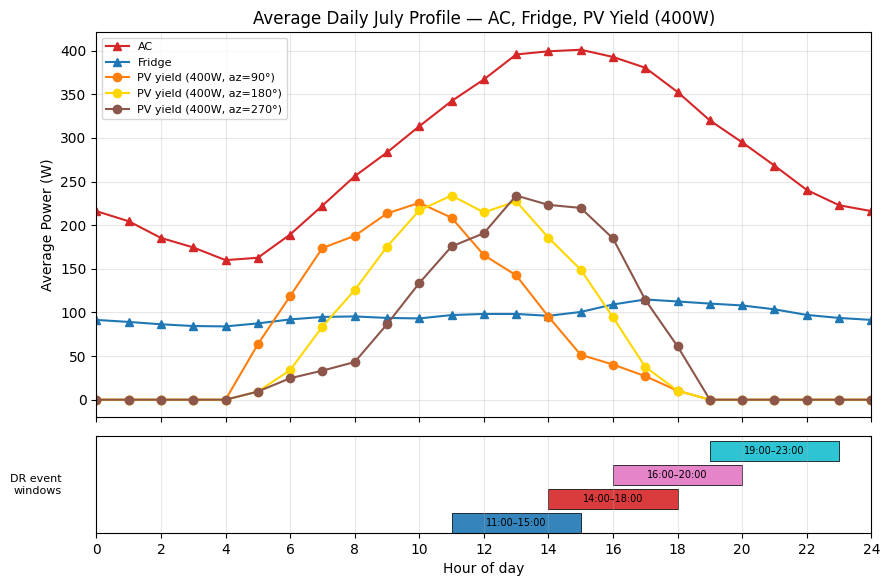

PV az=90° peak hour: 10:00, 225.6 W
PV az=180° peak hour: 11:00, 234.0 W
PV az=270° peak hour: 13:00, 233.9 W


In [206]:
# this plot is used in the paper - needs some of the stuff defined in the baseline variability section above that is commented out

# Main plot on top, CSRP windows as a Gantt strip in a separate subplot underneath (shared x-axis)
event_window_length = 4
azimuths_plot = [90, 180, 270]
azimuth_colors = {90: 'tab:orange', 180: 'gold', 270: 'tab:brown'}
csrp_start_hours = sorted(set(getStartTime(n) for n in networksToSim))

hours = np.arange(24)

hours_wrapped = np.append(hours, 24)
ac_wrapped = np.append(ac_daily_avg_july, ac_daily_avg_july[0])
fridge_wrapped = np.append(fridge_daily_avg_july, fridge_daily_avg_july[0])

pv_daily_avg_by_az = {}
pvW_plot = 400

for az in azimuths_plot:
    pv_hourly = yieldData[str(az)][str(pvW_plot)]['hourly']['yieldAC'].to_numpy()
    pv_july_az = pv_hourly[july_mask]
    pv_daily_avg_by_az[az] = average_daily_profile(pv_july_az)

fig, (ax, ax_gantt) = plt.subplots(
    2, 1, figsize=(10, 6.5), sharex=True,
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.08}
)

# ---- main plot ----
ax.plot(hours_wrapped, ac_wrapped, marker='^', label='AC', color='tab:red')
ax.plot(hours_wrapped, fridge_wrapped, marker='^', label='Fridge', color='tab:blue')
for az in azimuths_plot:
    pv_wrapped = np.append(pv_daily_avg_by_az[az], pv_daily_avg_by_az[az][0])
    ax.plot(hours_wrapped, pv_wrapped, marker='o',
            label=f'PV yield ({pvW_plot}W, az={az}°)', color=azimuth_colors[az])

ax.set_ylabel('Average Power (W)')
ax.set_title(f'Average Daily July Profile — AC, Fridge, PV Yield ({pvW_plot}W)')
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=8)

# ---- Gantt strip subplot ----
window_colors = plt.cm.tab10(np.linspace(0, 1, len(csrp_start_hours)))

for i, start_hr in enumerate(csrp_start_hours):
    ax_gantt.broken_barh(
        [(start_hr, event_window_length)], (i, 0.8),
        facecolor=window_colors[i], edgecolor='black', linewidth=0.6, alpha=0.9,
    )
    ax_gantt.text(
        start_hr + event_window_length / 2, i + 0.4,
        f'{start_hr}:00–{start_hr + event_window_length}:00',
        ha='center', va='center', fontsize=7, color='black',
    )

ax_gantt.set_ylim(0, len(csrp_start_hours))
ax_gantt.set_yticks([])
ax_gantt.set_ylabel('DR event\nwindows', fontsize=8, rotation=0, ha='right', va='center', labelpad=25)
ax_gantt.set_xlabel('Hour of day')
ax_gantt.set_xticks(range(0, 25, 2))
ax_gantt.set_xlim(0, 24)
ax_gantt.grid(axis='x', alpha=0.3)

plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
fig.savefig(f"results/final data/plots/avg_daily_load_pv_csrp_gantt_subplot_july_{timestamp}.png", dpi=300, bbox_inches="tight")
plt.show()

for az in azimuths_plot:
    peak_hr = hours[pv_daily_avg_by_az[az].argmax()]
    print(f"PV az={az}° peak hour: {peak_hr}:00, {pv_daily_avg_by_az[az].max():.1f} W")

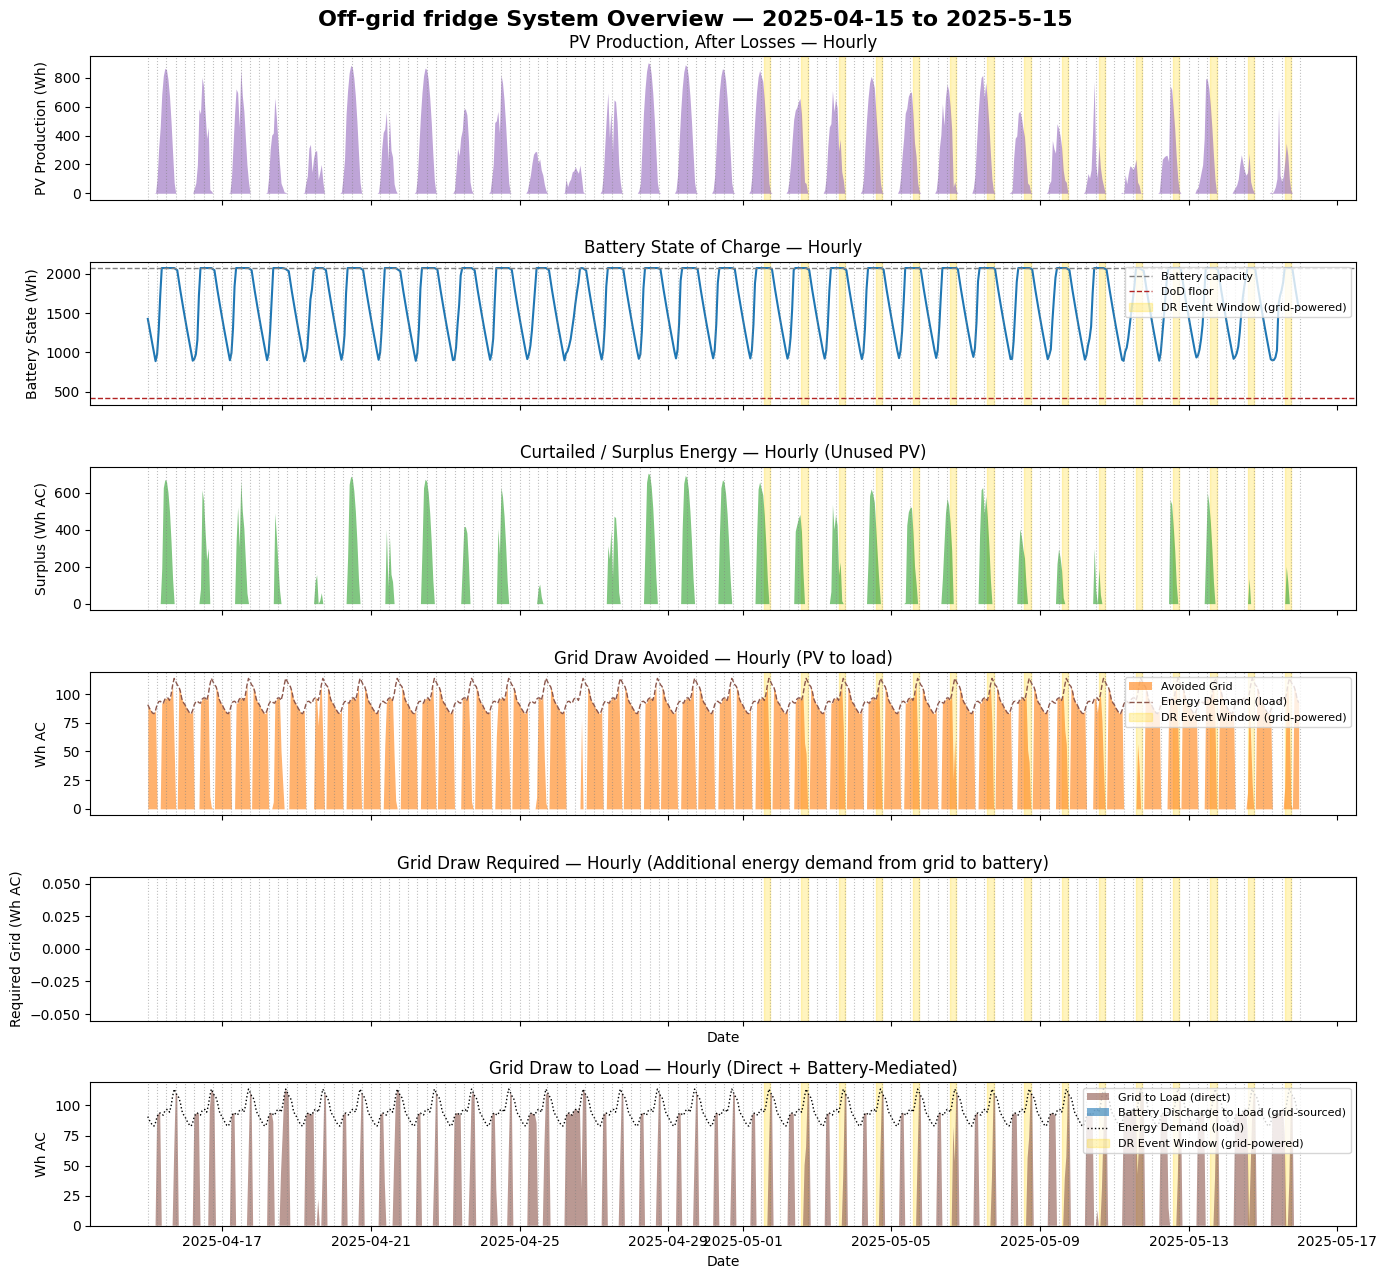

In [207]:
pv_production_arr = np.array([
    pv_to_stored_charge(getDegradedP(h, y), plugin, acToDC)
    for h in hourly_array_power_yield_test
])
idx = pd.date_range('2025-01-01', periods=len(g['batState']), freq='h')
df = pd.DataFrame(g, index=idx)
df['pvProductionWh'] = pv_production_arr
df['loadWAC'] = loadWAC
df['batteryDischargeToLoadWhAC'] = df['loadWAC'] - df['avoidedGridWhAC'] - df['grid_to_loadWhAC']
dodFloor = batWh * (1 - LiFePOdod)

# recreate the grid-window + DR-season mask the simulation used, so we can
# shade it on the plots (drWindowLengthHours must match the value
# hardcoded inside simulate_hourly_energy)
drWindowLengthHours = 4
hourOfDay = df.index.hour
dayOfYear = df.index.dayofyear
seasonEndDay = drSeasonStartDay + sum(daysInMonth) - 1
inSeason = (dayOfYear >= drSeasonStartDay) & (dayOfYear <= seasonEndDay)
inWindow = (
    (drWindowStartHour is not None)
    & (hourOfDay >= (drWindowStartHour or 0))
    & (hourOfDay < (drWindowStartHour or 0) + drWindowLengthHours)
)
df['inDRWindow'] = inSeason & inWindow

# zoom window -- 4 days
window = df.loc[window_start:window_end]

def get_event_spans(mask):
    """Collapse a boolean hourly Series into a list of (start, end) timestamp
    spans, so contiguous event hours become a single shaded block."""
    spans = []
    in_span = False
    start = None
    vals = mask.values
    times = mask.index
    for i in range(len(vals)):
        if vals[i] and not in_span:
            start = times[i]
            in_span = True
        elif not vals[i] and in_span:
            spans.append((start, times[i]))
            in_span = False
    if in_span:
        spans.append((start, times[-1] + pd.Timedelta(hours=1)))
    return spans

event_spans = get_event_spans(window['inDRWindow'])

fig, axes = plt.subplots(6, 1, figsize=(14, 13), sharex=True)

axes[0].fill_between(window.index, window['pvProductionWh'], color='tab:purple', alpha=0.6, linewidth=0)
axes[0].set_ylabel('PV Production (Wh)')
axes[0].set_title('PV Production, After Losses — Hourly')

axes[1].plot(window.index, window['batState'], linewidth=1.5, color='tab:blue')
axes[1].axhline(batWh, color='gray', linestyle='--', linewidth=1, label='Battery capacity')
axes[1].axhline(dodFloor, color='firebrick', linestyle='--', linewidth=1, label='DoD floor')
axes[1].set_ylabel('Battery State (Wh)')
axes[1].set_title('Battery State of Charge — Hourly')

axes[2].fill_between(window.index, window['surplusWhAC'], color='tab:green', alpha=0.6, linewidth=0)
axes[2].set_ylabel('Surplus (Wh AC)')
axes[2].set_title('Curtailed / Surplus Energy — Hourly (Unused PV)')

axes[3].fill_between(window.index, window['avoidedGridWhAC'], color='tab:orange', alpha=0.6, linewidth=0, label='Avoided Grid')
axes[3].plot(window.index, window['loadWAC'], color='tab:brown', linestyle='--', linewidth=1, label='Energy Demand (load)')
axes[3].set_ylabel('Wh AC')
axes[3].set_title('Grid Draw Avoided — Hourly (PV to load)')

axes[4].fill_between(window.index, window['requiredGridWhAC'], color='tab:red', alpha=0.6, linewidth=0)
axes[4].set_ylabel('Required Grid (Wh AC)')
axes[4].set_title('Grid Draw Required — Hourly (Additional energy demand from grid to battery)')
axes[4].set_xlabel('Date')

axes[5].stackplot(
    window.index,
    window['grid_to_loadWhAC'],
    window['batteryDischargeToLoadWhAC'],
    colors=['tab:brown', 'tab:blue'],
    alpha=0.6,
    labels=['Grid to Load (direct)', 'Battery Discharge to Load (grid-sourced)'],
)
axes[5].plot(window.index, window['loadWAC'], color='black', linestyle=':', linewidth=1, label='Energy Demand (load)')
axes[5].set_ylabel('Wh AC')
axes[5].set_title('Grid Draw to Load — Hourly (Direct + Battery-Mediated)')
axes[5].set_xlabel('Date')

# shade the DR event window on every panel
for ax_i, ax in enumerate(axes):
    for span_i, (span_start, span_end) in enumerate(event_spans):
        ax.axvspan(
            span_start, span_end,
            color='gold', alpha=0.25, zorder=0,
            label='DR Event Window (grid-powered)' if (ax_i in (1, 3, 5) and span_i == 0) else None,
        )

# vertical lines every 6 hours, across all panels, to align comparison
gridlines = pd.date_range(window.index[0].normalize(), window.index[-1] + pd.Timedelta(hours=1), freq='6h')
for ax in axes:
    for t in gridlines:
        ax.axvline(t, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

# re-issue legends now that the shaded-span label has been added
for ax in (axes[1], axes[3], axes[5]):
    ax.legend(loc='upper right', fontsize=8)

if plugin:
    pluginfn = 'Plug-in'
else:
    pluginfn = 'Off-grid'
    
fig.suptitle(f'{pluginfn} {loadName} System Overview — {window_start} to {window_end}', fontsize=16, fontweight='bold')
plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")


    
plt.savefig(f'results/results_sept28/plots/system_overview_{loadName}_{pluginfn.lower().replace('-','')}_{window_start}_{window_end}_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()

### Plot used in paper to demonstrate control scheme

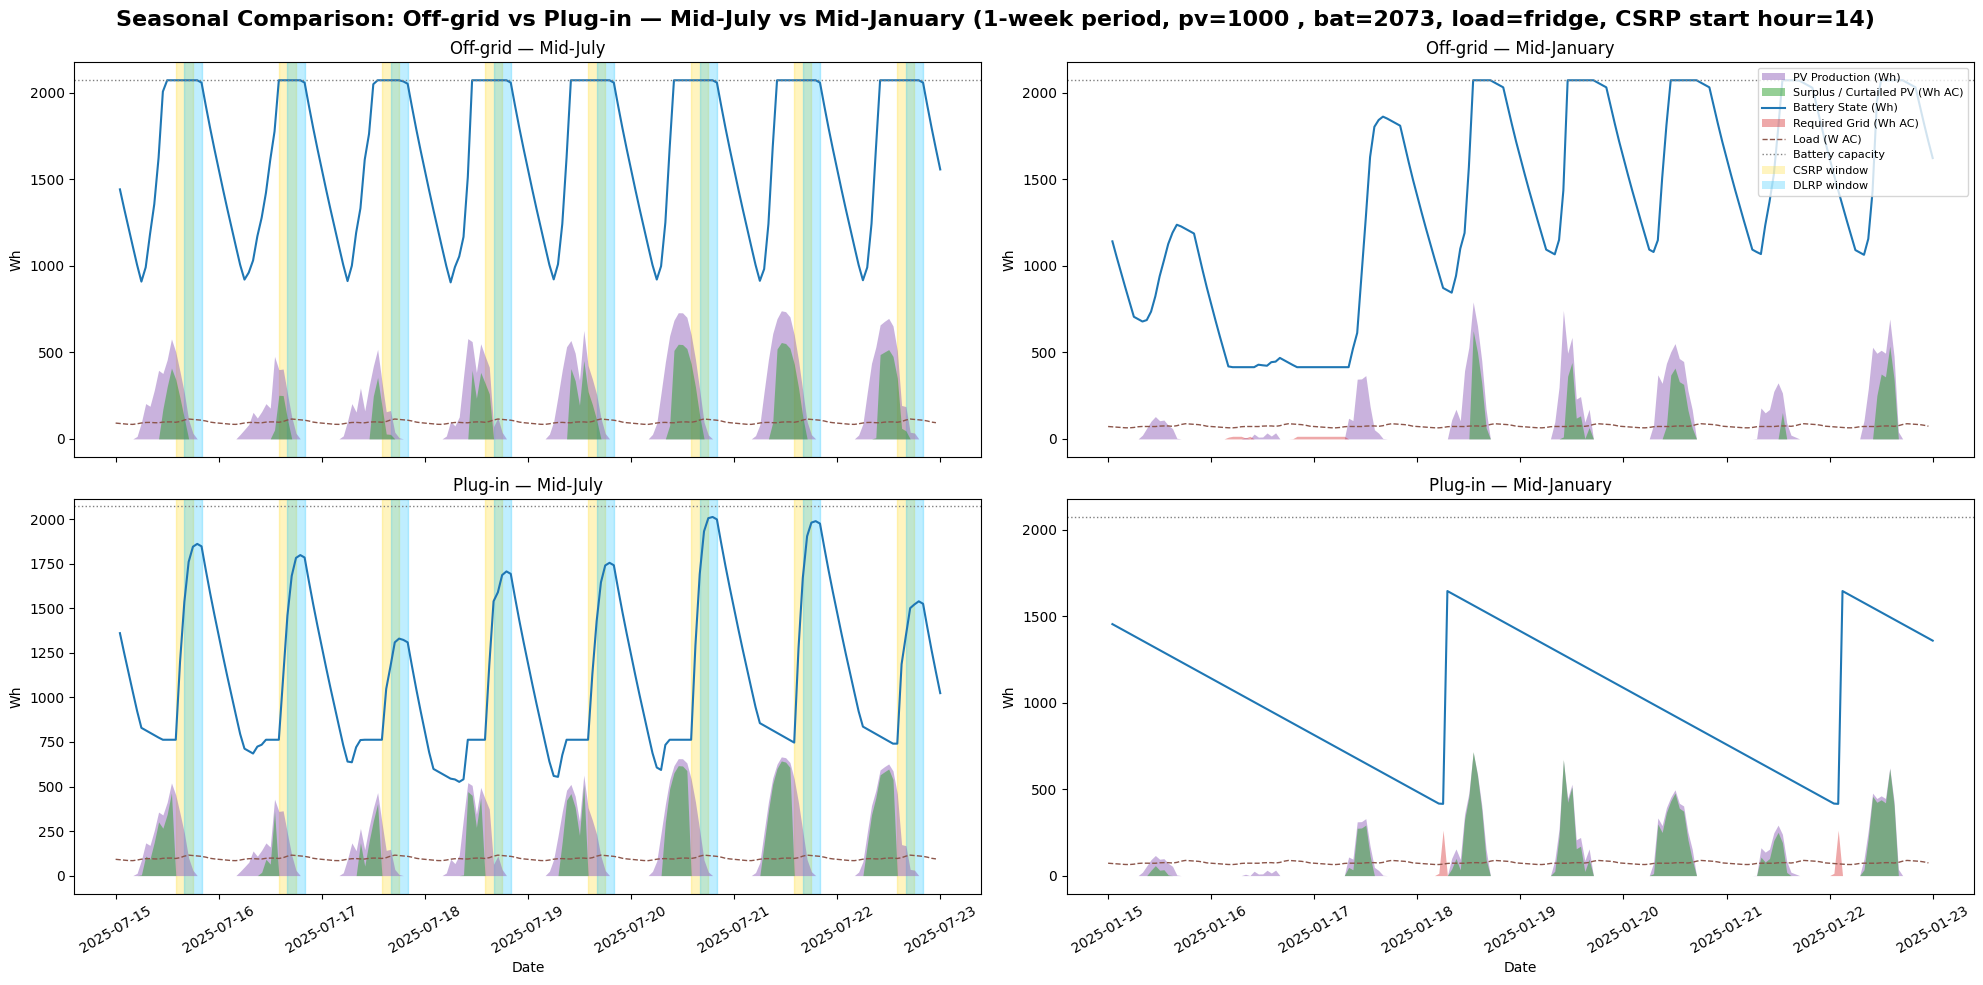

In [208]:
# 4-subplot overview: Off-grid vs Plug-in, Mid-July vs Mid-January (1-week windows each)

week_windows = {
    'Mid-July': ('2025-07-15', '2025-07-22'),
    'Mid-January': ('2025-01-15', '2025-01-22'),
}
plugin_configs = [('Off-grid', False), ('Plug-in', True)]

# fixed DLRP window, independent of CSRP timing
dlrpWindowStartHour = 16
dlrpWindowEndHour = 20

fig, axes2 = plt.subplots(2, 2, figsize=(20, 10), sharex='col')

for row, (config_label, config_plugin) in enumerate(plugin_configs):
    g2 = simulate_hourly_energy(
        list(hourly_array_power_yield_test), batWh, loadWAC, iE, y, config_plugin,
        drWindowStartHour=drWindowStartHour, maxDischargeRateW=600
    )
    pv_production_arr2 = np.array([
        pv_to_stored_charge(getDegradedP(h, y), config_plugin, acToDC)
        for h in hourly_array_power_yield_test
    ])
    idx2 = pd.date_range('2025-01-01', periods=len(g2['batState']), freq='h')
    df2 = pd.DataFrame(g2, index=idx2)
    df2['pvProductionWh'] = pv_production_arr2
    df2['loadWAC'] = loadWAC

    # recreate the grid-window + DR-season mask, same logic as the cell above
    hourOfDay2 = df2.index.hour
    dayOfYear2 = df2.index.dayofyear
    seasonEndDay2 = drSeasonStartDay + sum(daysInMonth) - 1
    inSeason2 = (dayOfYear2 >= drSeasonStartDay) & (dayOfYear2 <= seasonEndDay2)

    inWindow2 = (
        (drWindowStartHour is not None)
        & (hourOfDay2 >= (drWindowStartHour or 0))
        & (hourOfDay2 < (drWindowStartHour or 0) + drWindowLengthHours)
    )
    df2['inDRWindow'] = inSeason2 & inWindow2

    # DLRP window mask -- fixed 16:00-20:00, same in-season gate as CSRP
    inDLRPWindow2 = (
        (hourOfDay2 >= dlrpWindowStartHour)
        & (hourOfDay2 < dlrpWindowEndHour)
    )
    df2['inDLRPWindow'] = inSeason2 & inDLRPWindow2

    for col, (window_label, (w_start, w_end)) in enumerate(week_windows.items()):
        ax = axes2[row, col]
        window2 = df2.loc[w_start:w_end]
        event_spans2 = get_event_spans(window2['inDRWindow'])
        dlrp_spans2 = get_event_spans(window2['inDLRPWindow'])

        ax.fill_between(window2.index, window2['pvProductionWh'], color='tab:purple', alpha=0.5,
                         linewidth=0, label='PV Production (Wh)')
        ax.fill_between(window2.index, window2['surplusWhAC'], color='tab:green', alpha=0.5,
                         linewidth=0, label='Surplus / Curtailed PV (Wh AC)')

        # batState_arr[i] is the battery level AFTER hour i's activity has
        # been applied -- i.e. it's the state as of the START of hour i+1,
        # not hour i. Shift it forward by one hour so it lines up correctly
        # with the other series and the DR/DLRP window shading.
        ax.plot(window2.index + pd.Timedelta(hours=1), window2['batState'], color='tab:blue', linewidth=1.5,
                label='Battery State (Wh)')

        ax.fill_between(window2.index, window2['requiredGridWhAC'], color='tab:red', alpha=0.4,
                         linewidth=0, label='Required Grid (Wh AC)')
        ax.plot(window2.index, window2['loadWAC'], color='tab:brown', linestyle='--', linewidth=1,
                label='Load (W AC)')
        ax.axhline(batWh, color='gray', linestyle=':', linewidth=1, label='Battery capacity')

        for span_start, span_end in event_spans2:
            ax.axvspan(span_start, span_end, color='gold', alpha=0.25, zorder=0, label='CSRP window')
        for span_start, span_end in dlrp_spans2:
            ax.axvspan(span_start, span_end, color='deepskyblue', alpha=0.25, zorder=0, label='DLRP window')

        ax.set_title(f'{config_label} — {window_label}')
        ax.set_ylabel('Wh')
        if row == 1:
            ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=30)

# # build a de-duplicated legend so repeated axvspan labels don't clutter it
# handles, labels = axes2[0, 1].get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# build a de-duplicated legend from ALL subplots so labels that only appear
# in some panels (e.g. event windows in July but not January) aren't lost
by_label = {}
for ax_i in axes2.flat:
    h, l = ax_i.get_legend_handles_labels()
    for handle, label in zip(h, l):
        by_label.setdefault(label, handle)

# proxy patches for the event-window background colors so they always appear
# in the legend, even if no window falls inside the plotted weeks
by_label['CSRP window'] = Patch(facecolor='gold', alpha=0.25, edgecolor='none', label='CSRP window')
by_label['DLRP window'] = Patch(facecolor='deepskyblue', alpha=0.25, edgecolor='none', label='DLRP window')

axes2[0, 1].legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)

fig.suptitle(f'Seasonal Comparison: Off-grid vs Plug-in — Mid-July vs Mid-January (1-week period, pv={pvW} , bat={batWh}, load={loadName}, CSRP start hour={drWindowStartHour})',
             fontsize=16, fontweight='bold')
plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f'results/results_sept28/plots/seasonal_comparison_{loadName}_offgrid_plugin_{timestamp}.png', dpi=300, bbox_inches='tight')

plt.show()

## Economic Modeling & Hardware Costs

Components:

* CAPEX
* Grid electricity value (costs or avoided value)
* PBP
* NPV
* IRR
* LCOE (LCOSS)

In [158]:
# #average inflation rate for 2024, based on NREL data from https://atb.nrel.gov/electricity/2024/definitions#inflation
# aIR = 0.025

realDiscountRate = 0.03 #2.2% real rate
# nominalDiscountRate = ((1 + realDiscountRate) * (1 + aIR))-1
# print(nominalDiscountRate)
discountRate = realDiscountRate

# #returns inflation rate after Y years
# #args: year
# def infRate(y, r= aIR):
#     return (1+r)**y

# arguments: value to be inflated, year
# not used
def inflateIt(v,y):
    return v* infRate(y)

# if using an electricity increase > general inflation, be sure to set to 0 when comparing with Homer
avgAnnualInc= 0
def annualCostIncrease(v,y):
    return v* ((1+avgAnnualInc)**y)
    
#args: value to be discounted, year
def discountIt(v, y,r =discountRate):
    #the first year is also discounted. in this model the first year is y=0, so add 1
    return v/(1+r)**(y+1)

#inflateIt(10,4)

### Capital Expenses (CAPEX) i.e. upfront costs

In [159]:
# Upfront Costs

#args: pv watts
def getPVcost(w:int):
    #.7 is based on a 30% tax credit on PV modules
    taxCredit = 0 #.3 #IRA repealed by Trumps BS
    #assumes $0.5 per W modules
    modulePerW = 0.5

    return w * (1-taxCredit) * modulePerW

#this is the total initial expenditure
#args: pv watts, battery price, diy controller,  micro-inverter in use, operating expense,rl=if using replacement load
def getCAPEX(pvW:int,batPr:float,diy:bool=True,mi:bool=False,rl:bool=False,op:float=0.0):
    #total sales tax in NYC is 8.875% - no sales tax for non-profits
    salesTax =  0.08875 

    if pvW == 0:
        #fixed costs
        insulation = 0 #used for insulating cable entry
        pvCables = 0 #2x 10ft MC4 cables
    else:
        #fixed costs
        insulation = 6 #used for insulating cable entry
        pvCables = 1.5 * 20 #20ft pair MC4 cables @ $1.5/ft

    #variable costs
    mountDollarPerW = .4

    # controller i.e. smart plugs and transfer switch is required for the DIY version or just a smart plug for the replacement load method
    smartController = 0
    if diy:
        smartController = 115.74 #smart controller without RPi, composed of 3 smart plugs and a transfer switch
    elif rl:
        smartController = 11.25 # the replacement load scenario requires 1 smart plug, if not already using the DIY version

    # microinverter is required for plug-in configuration
    microinverter = 0
    if mi and pvW >0: #added if pvW > 0

        #Hoymiles HMS-391-1WB-LV HiFlow Pro LV 1-in-1 series plug-in microinverter is used for array <=500
        # AP Systems EZ1 Plug-in Microinverter is used for larger arrays
        microinverter = 325 if pvW > 500 else 152.78 # updated 9/19/26

    # RPi is required for DIY version, communicating with microinverter, or if using the replacement load
    rpi = 0
    if (mi and pvW >0) or diy or rl:  #added if pvW > 0
        rpi = 62.75
        
    operatingCosts = op #DR aggregation operator costs are not considered here.
    
    fixedHardwareCosts = smartController + rpi + operatingCosts + insulation + pvCables + microinverter

    variableCosts = batPr + getPVcost(pvW) + (pvW * mountDollarPerW)

    return (fixedHardwareCosts + variableCosts) * (1 + salesTax)

#print(getCAPEX(100,200))


In [160]:
getCAPEX(1000,0,False,True)

1441.2328125000001

### Grid Electricity Costs

In [161]:
# GRID ELECTRICITY COSTS - CHANGE THIS TO JULY AND AUGUST AVG FOR ELEX!

# https://www.bls.gov/regions/northeast/news-release/averageenergyprices_newyork.htm accessed January 24, 2025
#monthlyResElecPricesDollars = [0.265,0.255,0.266,0.259,0.252,0.288,0.288,0.276,0.273,0.274,0.262,0.272]

# https://www.nyserda.ny.gov/Energy-Prices/Electricity/Monthly-Avg-Electricity-Residential
monthlyResElecPricesDollars = [0.284, 0.30, 0.286,0.2879,0.299,0.2979,0.2934,0.299,0.3046,0.3024,0.2957,0.3069]
#monthlyResElecPricesDollars = [0,0,0,0,0,0,0,0,0,0,0,0]

avgDollarsKw =round(sum(monthlyResElecPricesDollars)/len(monthlyResElecPricesDollars),4) 
print('12 Month NYS Residential Retail Electricity Average: $' + str(avgDollarsKw) + '/kWh')

#args: kWAC generated from PV, year from installation, month (either a for all or the number of the month-1)
def utilityCosts(kWAC,y=0, m='a'):

    if m=='a':
        price =round(sum(monthlyResElecPricesDollars)/len(monthlyResElecPricesDollars),4) 
    else:
        price=monthlyResElecPricesDollars[m]

    annualElectCosts = kWAC * annualCostIncrease(price,y) # this factors in annual grid price increases
    return annualElectCosts

print(utilityCosts(15,3))

12 Month NYS Residential Retail Electricity Average: $0.2964/kWh
4.446


In [162]:
def aggregate_hourly_to_monthly(hourly, year=2025):
    """
    Convert raw hourly arrays (already AC-equivalent Wh) into monthly kWAC
    surplus stats and annual totals, using a datetime index.

    avg/med/min/max_hourly_surpluskWAC_byMonth are computed as true daily
    averages of surplus hours (zero-surplus hours excluded from the
    per-day stat, matching the original per-day loop's behavior), then
    those daily stats are aggregated across each month.
    """
    idx = pd.date_range(start=f'{year}-01-01', periods=len(hourly['surplusWhAC']), freq='h')
    surplus = pd.Series(hourly['surplusWhAC'], index=idx) * 0.001  # Wh -> kWAC

    # NaN on zero-surplus hours so daily stats skip them, like the original
    surplus_nonzero = surplus.where(surplus > 0)
    daily_avg = surplus_nonzero.resample('D').mean().fillna(0)
    daily_med = surplus_nonzero.resample('D').median().fillna(0)
    daily_min = surplus_nonzero.resample('D').min().fillna(0)
    daily_max = surplus_nonzero.resample('D').max().fillna(0)
    daily_totals = surplus.resample('D').sum()

    return {
        'avg_hourly_surpluskWAC_byMonth': daily_avg.resample('ME').mean().tolist(),
        'med_hourly_surpluskWAC_byMonth': daily_med.resample('ME').median().tolist(),
        'min_hourly_surpluskWAC_byMonth': daily_min.resample('ME').min().tolist(),
        'max_hourly_surpluskWAC_byMonth': daily_max.resample('ME').max().tolist(),
        'ann_surpluskWhAC': daily_totals.sum(),
        'requiredGridWhAC_total': hourly['requiredGridWhAC'].sum(),
        'avoidedGridWhAC_total': hourly['avoidedGridWhAC'].sum(),
        'gridToLoadWhAC_total': hourly['grid_to_loadWhAC'].sum(),
        'gridBatteryChargeWhAC_total': hourly['gridBatteryChargeWhAC'].sum(),
        #'pvToBatteryWhDC_total':hourly['pvToBatteryWhDC'].sum(),
        #'batteryToLoadWhAC_total':hourly['batteryToLoadWhAC'].sum()
        #'gridToBatteryWhAC_total': hourly['gridToBatteryWhAC'].sum(),
        'batteryToLoadWhAC_total': hourly['batteryToLoadWhAC'].sum(), # uncomment after test
        'selfSuppliedWhAC_total': hourly['selfSuppliedWhAC'].sum(), # uncomment after test
    }

#  9/30/version
def apply_financials(agg, y, events, batWh, LiFePOdod, acToDC, iE):
    """
    Convert aggregated AC-equivalent energy totals into dollar values.
    """
    requiredGridkWhAC = agg['requiredGridWhAC_total'] * 0.001
    avoidedGridkWhAC = agg['avoidedGridWhAC_total'] * 0.001
    gridToLoadkWhAC = agg['gridToLoadWhAC_total'] * 0.001
    gridBatteryChargekWhAC = agg['gridBatteryChargeWhAC_total'] * 0.001
    #gridToBatterykWhAC = agg['gridToBatteryWhAC_total'] * 0.001
    gridToBatterykWhAC = requiredGridkWhAC + gridBatteryChargekWhAC * acToDC * iE # added 9/30
    batteryToLoadkWhAC = agg['batteryToLoadWhAC_total'] * 0.001
    selfSuppliedkWhAC = agg['selfSuppliedWhAC_total'] * 0.001

    # top off from grid for events — round-trip conversion loss vs. going
    # direct from grid to load
    eventGridCharge_kWhAC = events * ((batWh * LiFePOdod_event * 0.001) / acToDC) 
    eventBatteryOutputkWhAC_fromGrid = eventGridCharge_kWhAC * acToDC * iE

    return {
        'avg_hourly_surpluskWAC_byMonth': agg['avg_hourly_surpluskWAC_byMonth'],
        'med_hourly_surpluskWAC_byMonth': agg['med_hourly_surpluskWAC_byMonth'],
        'min_hourly_surpluskWAC_byMonth': agg['min_hourly_surpluskWAC_byMonth'],
        'max_hourly_surpluskWAC_byMonth': agg['max_hourly_surpluskWAC_byMonth'],
        'ann_surpluskWhAC': agg['ann_surpluskWhAC'],
        'ann_surpluskWhAC_value': utilityCosts(agg['ann_surpluskWhAC'], y),
        'requiredGridkWhAC': requiredGridkWhAC,
        'requiredGridkWhAC_cost': utilityCosts(requiredGridkWhAC, y),
        'eventGridChargekWhAC': eventGridCharge_kWhAC,
        'eventGridChargekWhAC_cost': utilityCosts(eventGridCharge_kWhAC,y,6), #base the cost off of July rates
        'eventBatteryOutputkWhAC_fromGrid': eventBatteryOutputkWhAC_fromGrid,
        'avoidedGridkWhAC': avoidedGridkWhAC,
        'avoidedGridkWhAC_value': utilityCosts(avoidedGridkWhAC, y),
        'gridToLoadkWhAC': gridToLoadkWhAC,
        'gridToLoadkWhAC_cost': utilityCosts(gridToLoadkWhAC,y),
        'gridBatteryChargekWhAC': gridBatteryChargekWhAC,
        'gridBatteryChargekWhAC_cost': utilityCosts(gridBatteryChargekWhAC,y),
        'gridToBatterykWhAC': gridToBatterykWhAC,
        'gridToBatterykWhAC_cost': utilityCosts(gridToBatterykWhAC, y),
        'batteryToLoadkWhAC': batteryToLoadkWhAC,
        'selfSuppliedkWhAC': selfSuppliedkWhAC,
    }

# my previous version!
# def apply_financials(agg, y, events, batWh, LiFePOdod, acToDC, iE):
#     """
#     Convert aggregated AC-equivalent energy totals into dollar values.
#     No unit conversion happens here anymore — that's already done
#     upstream in simulate_hourly_energy.
#     """
#     requiredGridkWhAC = agg['requiredGridWhAC_total'] * 0.001
#     avoidedGridkWhAC = agg['avoidedGridWhAC_total'] * 0.001
#     gridToLoadkWhAC = agg['gridToLoadWhAC_total'] * 0.001
#     gridBatteryChargekWhAC = agg['gridBatteryChargeWhAC_total'] * 0.001
#     #pvToBatterykWhDC = agg['pvToBatteryWhDC_total']*0.001
#     #batteryToLoadkWhAC = agg['batteryToLoadWhAC_total']*0.001

#     # top off from grid for events — round-trip conversion loss vs. going
#     # direct from grid to load
#     eventGridCharge_kWhAC = events * ((batWh * LiFePOdod_event * 0.001) / acToDC) 
#     eventBatteryOutputkWhAC_fromGrid = eventGridCharge_kWhAC * acToDC * iE

#     return {
#         'avg_hourly_surpluskWAC_byMonth': agg['avg_hourly_surpluskWAC_byMonth'],
#         'med_hourly_surpluskWAC_byMonth': agg['med_hourly_surpluskWAC_byMonth'],
#         'min_hourly_surpluskWAC_byMonth': agg['min_hourly_surpluskWAC_byMonth'],
#         'max_hourly_surpluskWAC_byMonth': agg['max_hourly_surpluskWAC_byMonth'],
#         'ann_surpluskWhAC': agg['ann_surpluskWhAC'],
#         'ann_surpluskWhAC_value': utilityCosts(agg['ann_surpluskWhAC'], y),
#         'requiredGridkWhAC': requiredGridkWhAC,
#         'requiredGridkWhAC_cost': utilityCosts(requiredGridkWhAC, y),
#         'eventGridChargekWhAC': eventGridCharge_kWhAC,
#         'eventGridChargekWhAC_cost': utilityCosts(eventGridCharge_kWhAC,y,6), #base the cost off of July rates
#         'eventBatteryOutputkWhAC_fromGrid': eventBatteryOutputkWhAC_fromGrid,
#         'avoidedGridkWhAC': avoidedGridkWhAC,
#         'avoidedGridkWhAC_value': utilityCosts(avoidedGridkWhAC, y),
#         'gridToLoadkWhAC': gridToLoadkWhAC,
#         'gridToLoadkWhAC_cost': utilityCosts(gridToLoadkWhAC,y),
#         'gridBatteryChargekWhAC': gridBatteryChargekWhAC,
#         'gridBatteryChargekWhAC_cost': utilityCosts(gridBatteryChargekWhAC,y),
#         #'pvToBatterykWhDC': pvToBatterykWhDC,
#         #'batteryToLoadkWhAC':batteryToLoadkWhAC
#     }

def getGridValueHourly(pvYieldW, batWh, loadWAC, iE, events=5, y=0, plugin=True,
                       drWindowStartHour=None, maxChargeRateW=1800, maxDischargeRateW=None,
                       dlrpStartHours=None):
    """
    drWindowStartHour, maxChargeRateW, maxDischargeRateW: passed straight
    through to simulate_hourly_energy (see its docstring) so the grid-window
    and AC-side hardware rate caps are reflected in the financial totals too.

    dlrpStartHours: optional dict of {label: event_start_hour}, e.g.
    {'c': dlrpStartC, 'i': dlrpStartI}. When provided, the batState
    already produced by this call's simulate_hourly_energy run is also
    sampled via batteryStateAtEvent at each labeled hour (and 2 hours
    before it), and the by-month results are folded into the returned
    dict as 'dlrpBatState_atEventStart_{label}' and
    'dlrpBatState_beforeEventStart_{label}'. This lets DLRP event-start
    battery capacity be computed per load, using that load's own
    simulated cycling behavior, without running a second simulation.
    """
    n_hours = len(pvYieldW)
    loadWAC_hourly = build_seasonal_load_array(loadWAC, n_hours=n_hours)

    hourly = simulate_hourly_energy(
        pvYieldW, batWh, loadWAC_hourly, iE, y, plugin,
        dailySelfConsumptionWhDC=dailySelfConsumptionWhDC,
        LiFePOdod=LiFePOdod, acToDC=acToDC,
        drWindowStartHour=drWindowStartHour, #uncomment after homer comparison!
        maxChargeRateW=maxChargeRateW,
        maxDischargeRateW=maxDischargeRateW,
    )
    agg = aggregate_hourly_to_monthly(hourly)
    result = apply_financials(agg, y, events, batWh, LiFePOdod, acToDC, iE)

    if dlrpStartHours:
        for label, sT in dlrpStartHours.items():
            bse = batteryStateAtEvent(hourly['batState'], round(sT))
            result[f'dlrpBatState_atEventStart_{label}'] = bse['atEventStart']
            result[f'dlrpBatState_beforeEventStart_{label}'] = bse['beforeEventStart']

    return result

In [163]:
getGridValueHourly(list(hourly_array_power_yield_test), 0,100,.85)

{'avg_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'med_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'min_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'max_hourly_surpluskWAC_byMonth': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'ann_surpluskWhAC': np.float64(0.0),
 'ann_surpluskWhAC_value': np.float64(0.0),
 'requiredGridkWhAC': np.float64(0.0),
 'requiredGridkWhAC_cost': np.float64(0.0),
 'eventGridChargekWhAC': 0.0,
 'eventGridChargekWhAC_cost': 0.0,
 'eventBatteryOutputkWhAC_fromGrid': 0.0,
 'avoidedGridkWhAC': np.float64(0.0),
 'avoidedGridkWhAC_value': np.float64(0.0),
 'gridToLoadkWhAC': np.float64(367.2),
 'gridToLoadkWhAC_cost': np.float64(108.83807999999999),
 'gridBatteryChargekWhAC': np.float64(0.0),
 'gridBatteryChargekWhAC_cost'

### Payback Period

Payback Period = Initial Investment / Annual Value

In [164]:
#args: capex, grid value, DR revenue
# returns PBP in years
def getPBP(c:float,g:Dict[str,List[float]],dr:list[float])->Dict[str,float]:
    # gK = ['requiredGridkWhAC_cost','eventGridChargekWhAC_costs','avoidedGridkWhAC_value']
    # gKS = ['ann_surpluskWhAC_value']
    
    pbp = {'without_surplus':0,'with_surplus':0}
    avgDr = mean(dr)
    
    gridBalance = mean(g['avoidedGridkWhAC_value']) - mean(g['requiredGridkWhAC_cost']) - mean(g['eventGridChargekWhAC_cost'])
    pbp['without_surplus'] = c/(gridBalance+avgDr)
    pbp['with_surplus'] = c/(gridBalance+avgDr+mean(g['ann_surpluskWhAC_value']))

    return pbp
    
# cTest =  300
# gTest ={'daysWithSurplus': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'avgHourlySurpluskWAC': 0.0, 'maxHourlySurpluskWAC': 0.0, 'ann_surpluskWhAC': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'ann_surpluskWhAC_value': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'requiredGridkWhAC': [np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895)], 'requiredGridkWhAC_cost': [np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053)], 'eventGridChargekWhAC': [np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632)], 'eventGridChargekWhAC_cost': [np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687)], 'avoidedGridkWhAC': [np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394)], 'avoidedGridkWhAC_value': [np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299)]}
# drTest = [np.float64(8.32920429661677), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(3.1849880941306794), 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, np.float64(15.656175588316744), 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0]
#getPBP(cTest,gTest,drTest)

### Net Present Value (NPV)

NPV = ∑ (Cash flow / (1 + i)^t) – initial investment

In [165]:
# args: capex, grid value, dr value, pv W
def getNPV(c, g, dr, w:int=0):
    
    subC = -1 * c
    wl = min(10, len(dr))
    resVal = discountIt(getResidualValue(w, wl),wl-1) # subtract 1 because discountIt adds 1

    npv = {'without_surplus':subC+resVal,'with_surplus':subC+resVal} #including residual value just added

        
    for y in range(wl):
        cashFlow = g['avoidedGridkWhAC_value'][y] - g['requiredGridkWhAC_cost'][y] - g['eventGridChargekWhAC_cost'][y] +dr[y]
        npv['without_surplus'] += (discountIt(cashFlow,y))
        npv['with_surplus'] += (discountIt(cashFlow+g['ann_surpluskWhAC_value'][y],y)) 
    return npv

# cTest =  300
# gTest ={'daysWithSurplus': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'avgHourlySurpluskWAC': 0.0, 'maxHourlySurpluskWAC': 0.0, 'ann_surpluskWhAC': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'ann_surpluskWhAC_value': [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)], 'requiredGridkWhAC': [np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895), np.float64(4.382105263157895)], 'requiredGridkWhAC_cost': [np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053), np.float64(1.1796627368421053)], 'eventGridChargekWhAC': [np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632), np.float64(6.467368421052632)], 'eventGridChargekWhAC_cost': [np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687), np.float64(1.7410155789473687)], 'avoidedGridkWhAC': [np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394), np.float64(1.0149751746234394)], 'avoidedGridkWhAC_value': [np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299), np.float64(0.2732313170086299)]}
# drTest = [np.float64(8.32920429661677), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(14.072826686447678), np.float64(3.1849880941306794), 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, 5.6000000000000005, np.float64(15.656175588316744), 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0]
# getNPV(cTest,gTest,drTest)

In [166]:
# args: capex, grid value, dr value
# returns the discount rate at which NPV == 0
# mirrors getNPV's own cash flow definition
# y=0's cash flow is discounted, so the IRR reported here is consistent with the NPV
def getIRR(c, g, dr, w:int=0,r_lo=-0.99, r_hi=10.0, tol=1e-6, max_iter=200):
    wl = min(10, len(dr))
    resVal = discountIt(getResidualValue(w, wl),wl-1)

    def npv_at_rate(r, surplus):
        npv = (-1 * c) + resVal
        for y in range(wl):
            cashFlow = g['avoidedGridkWhAC_value'][y] - g['requiredGridkWhAC_cost'][y] - g['eventGridChargekWhAC_cost'][y] + dr[y]
            if surplus:
                cashFlow += g['ann_surpluskWhAC_value'][y]
            npv += discountIt(cashFlow, y, r) # cashFlow / (1 + r) ** y
        return npv

    def solve(surplus):
        lo, hi = r_lo, r_hi
        f_lo, f_hi = npv_at_rate(lo, surplus), npv_at_rate(hi, surplus)

        # no real IRR in this bracket -- e.g. cash flows never recover the
        # initial capex (NPV stays negative at every rate), or there's no
        # capex to recover at all
        if f_lo == 0:
            return lo
        if f_hi == 0:
            return hi
        if (f_lo > 0) == (f_hi > 0):
            return float('nan')

        mid = lo
        for _ in range(max_iter):
            mid = (lo + hi) / 2
            f_mid = npv_at_rate(mid, surplus)
            if abs(f_mid) < tol or (hi - lo) < tol:
                return mid
            if (f_mid > 0) == (f_lo > 0):
                lo, f_lo = mid, f_mid
            else:
                hi = mid
        return mid

    # this returns decimal format of the percentage i.e. if it return 0.03 that means 3%
    return {
        'without_surplus': solve(False),
        'with_surplus': solve(True),
    }

### Levelized Cost of Solar plus Storage (LCOSS)

Total Costs ($)/ Total Energy (kWAC)

In [167]:
#returns the dollar value of the module at the end of the system's working like
# factors in module degradation 
# args: PV watts nameplate,year
def getResidualValue(w,y):
    pvL = 25 # assumes 25 year life for PV module
    return getPVcost(getDegradedP(w,y)) * ((pvL-y)/pvL) 
 
#test
getResidualValue(1000, 10) # dont do the lifespan adjustment if prepping info for Homer!!!

271.3146225026413

In [168]:
# # grid sales are not included in LCOSS!

# previous version
# capex, gridValue, pv watts, load
# def getLCOSS(c, g, dr, w, totalLoadkWhAC):
#     wl = min(10,len(g['avoidedGridkWhAC_value']))
#     resVal = getResidualValue(w, wl)

#     lcoss = {'without_surplus': 0, 'with_surplus': 0}

#     for variant in lcoss:
#         num = c - discountIt(resVal, wl - 1)
#         den = 0
#         for y in range(wl):
#             # the NREL definition - to be used in model
#             num += discountIt(g['requiredGridkWhAC_cost'][y] + g['eventGridChargekWhAC_cost'][y], y) # uncomment when not comparing to homer

#             # for HOMER LCOE comparison only
#             #num += discountIt(g['requiredGridkWhAC_cost'][y] + g['eventGridChargekWhAC_cost'][y] - g['avoidedGridkWhAC_value'][y], y) # comment out for actual model run!

#             # this might need to get added back in for some scenarios...
#             #selfSuppliedkWhAC = totalLoadkWhAC - g['gridToLoadkWhAC'][y]
#             # self supplied is only not used in off-grid mode when PV=0, in this situation it defaults to the battery output for the events only
#             #energy = max(selfSuppliedkWhAC,g['eventBatteryOutputkWhAC_fromGrid'][y])

#             energy = g['avoidedGridkWhAC'][y]
            
#             if variant == 'with_surplus':
#                 #num -=discountIt(g['ann_surpluskWhAC_value'][y],y) # for HOMER LCOE comparison only - comment out for actual model run!
#                 energy += g['ann_surpluskWhAC'][y]
#             den += discountIt(energy, y)

#         # for testing
#         # if variant == 'with_surplus':
#         #     print(f'{c} - lcoe num: {num}, den:{den}')
        
#         lcoss[variant] = num / den if den != 0 else float('nan')

#     return lcoss

# grid sales are not included in LCOSS!

# 9/30 version - more accurate for batteries
# capex, gridValue, dr value, pv watts, load
def getLCOSS(c, g, dr, w, totalLoadkWhAC):
    wl = min(10, len(g['avoidedGridkWhAC_value']))
    resVal = getResidualValue(w, wl)

    lcoss = {'without_surplus': 0, 'with_surplus': 0}

    for variant in lcoss:
        num = c - discountIt(resVal, wl - 1)
        den = 0
        for y in range(wl):
            # full AC grid energy into the battery (charging, weekly top-off, floor maintenance),
            # so battery output counted in the denominator is paid for in the numerator
            num += discountIt(g['gridToBatterykWhAC_cost'][y] + g['eventGridChargekWhAC_cost'][y], y) # this is used in model - only turn off for Homer comparison

            # for HOMER LCOE comparison only - turn off
            #num += discountIt(g['gridToBatterykWhAC_cost'][y] + g['eventGridChargekWhAC_cost'][y] - g['avoidedGridkWhAC_value'][y], y) # comment out for actual model run!

            
            # energy delivered to the load by the system, AC:
            # PV direct + battery output after inverter losses (no double counting in off-grid)
            energy = g['selfSuppliedkWhAC'][y]

            if variant == 'with_surplus':
                #num -=discountIt(g['ann_surpluskWhAC_value'][y],y) # for HOMER LCOE comparison only - comment out for actual model run!
                energy += g['ann_surpluskWhAC'][y]
            den += discountIt(energy, y)

        lcoss[variant] = num / den if den != 0 else float('nan')

    return lcoss

In [169]:
#getLCOSS(cTest,gTest,wTest,sYTest,eETest) 

## Automated DR Participation

In [170]:
# returns the max value for a given load - does not consider the ability to meet the load needs
def drMaxValue(loadW_C,loadW_D, cRate, dRate, prefix=''):
    m=5 # months in the DR season
    annValResProgram_csrp = loadW_C * .001 * cRate * m #CSRP reservation value for full coverage of load
    annValResProgram_dlrp = loadW_D * .001 * dRate * m #DLRP reservation value for full coverage of load
    annValResTot = annValResProgram_csrp + annValResProgram_dlrp # Total DR reservation value for full coverage
    annValPer_csrp = loadW_C * .001 * csrpEvents #CSRP performance value for full coverage of load
    annValPer_dlrp = loadW_D * .001 * dlrpEvents #DLRP performance value for full coverage of load
    annValPer = annValPer_csrp + annValPer_dlrp #total performance value for full coverage of load
    annTotVal = annValResTot + annValPer # total value for full coverage of load

    drv = {
        f"{prefix}annValResProgram_csrp" : annValResProgram_csrp,
        f"{prefix}annValResProgram_dlrp" : annValResProgram_dlrp,
        f"{prefix}annValResTot" : annValResTot,
        f"{prefix}annValPer_csrp" : annValPer_csrp,
        f"{prefix}annValPer_dlrp" : annValPer_dlrp,
        f"{prefix}annValPer" : annValPer,
        f"{prefix}annTotVal" : annTotVal
    }
    return drv


# returns power that can be addressed and the annual dollar value
def drFlexValue(drkWACtotal_y, loadkW, rate, eventNum, replacement_kW=0, window=None,sensitivity=0):
    res = {}
    baselineSensitivity_1SD = {11:73.7, 14:76.8, 16:78.3, 19:71.4} #1 standard deviation of synthetic AC data by event window

    # if no window specified, average all SDs
    if window == None:
        sd_kW = mean(baselineSensitivity_1SD.values())/1000
    else:
        window = round(window)
        sd_kW = baselineSensitivity_1SD[window]/1000

    baseline = max(0,loadkW  - (sd_kW * sensitivity))

    if replacement_kW ==0:
        flexedkW = min(drkWACtotal_y,loadkW) #kWAC flexed up to baseline
    else:
        perc = drkWACtotal_y/replacement_kW # percentage of load covered
        flexedkW = loadkW * min(1,perc)  # the replacement is scaled based on the percentage of the event the replacement load can run for

    flexedkW = max(0, baseline - (loadkW - flexedkW))

    resInc = flexedkW * rate * 5 # annual reservation income (5 months)
    perfInc = flexedkW * 4 * eventNum # annual performance income (rate is $1/kWh) = flex * 4 hours * amount of events
    
    res['inc'] = resInc + perfInc
    res['flex'] = flexedkW
    res['baseline'] = baseline
    
    return res

In [171]:

# #get the available hourly watts if the battery is fully depleted over 4 hours
# #arg: battery WhDC
# # no longer used
# def getFourHourW(bWh:float):
#     return bWh * LiFePOdod * .25

In [172]:
def solarEventYieldkWAC(pvWyield, iE, sT, year=0, plugin=False) -> list:
    #daysInMonth = [31, 30, 31, 31, 30]
    elapsedDays = drSeasonStartDay  # May 1

    eff_mult = 1.0 if plugin else iE
    degrade = (1 - DEG_RATE) ** year   # <-- computed once, not per-hour

    monthly = []
    for dim in daysInMonth:
        # build hour indices for the 4 event hours, every day in this month
        day_starts = ((np.arange(elapsedDays, elapsedDays + dim) - 1) * 24) + sT
        hour_idx = day_starts[:, None] + np.arange(4)   # shape (dim, 4)
        window = pvWyield[hour_idx]                      # shape (dim, 4)

        daily_kwh = window.sum(axis=1) * eff_mult * 0.001 * 0.25  # per-day event kWh
        monthly.append(daily_kwh.mean())

        elapsedDays += dim

    # apply degradation once at the end, to every month at once
    return [m * degrade for m in monthly]

def batteryStateAtEvent(batState, sT, offsetHours=2) -> dict:
    """
    Returns the average *simulated* battery state (Wh), by month, at the
    DR event start hour and offsetHours hours before it.

    batState: hourly battery-state array (Wh) for a single simulated
    year, as returned by simulate_hourly_energy under the 'batState' key.
    This reflects actual day-to-day charge/discharge cycling (driven by
    the load, PV, and grid-window behavior already modeled in
    simulate_hourly_energy), replacing the old PV-yield-only proxy
    (solarPriorEventYieldWDC, removed).

    sT: event start hour of day (0-23). Round fractional start times
    (e.g. 16.5) before calling, same convention as solarEventYieldkWAC.
    offsetHours: how many hours before the event start to also sample
    (default 2, matching the DR programs' notice window).
    """
    elapsedDays = drSeasonStartDay

    atEventStart = []
    beforeEventStart = []
    for dim in daysInMonth:
        day_starts = (np.arange(elapsedDays, elapsedDays + dim) - 1) * 24
        idx_start = day_starts + sT
        idx_before = day_starts + max(sT - offsetHours, 0)

        atEventStart.append(batState[idx_start].mean())
        beforeEventStart.append(batState[idx_before].mean())

        elapsedDays += dim

    return {
        'atEventStart': atEventStart,
        'beforeEventStart': beforeEventStart,
    }

## Main Loop

This loop generates all the possible combinations of hardware and their energy and economic characteristics based on the constraints of the battery. 

In [173]:
#these networks are selected because they represent all possible combinations of characteristics

#myNetworks2023 = ['city hall','long island city','crown heights','randalls island', 'millwood west', 'grasslands','fresh kills','central bronx','northeast bronx']

In [174]:
yieldData = getYieldData(tilt, gamma_pdc)
#print(yieldData['180']['40'])

In [175]:
# check structure of output from above if needed
def key_outline(obj, indent=0):
    if isinstance(obj, dict):
        for k, v in obj.items():
            print("  " * indent + str(k))
            key_outline(v, indent + 1)
    elif isinstance(obj, pd.DataFrame):
        print("  " * indent + f"[DataFrame columns: {list(obj.columns)}]")
    elif isinstance(obj, (list, tuple)) and obj:
        key_outline(obj[0], indent + 1)

#key_outline(yieldData)

In [176]:
# True = quick test, false = full run
testMode = False
testModeNetworks = testMode
testModeBatteries = testMode
testModeAzimuth = True
testModePV = testMode
testModeF = True
testModeMI = testMode
testModeBase = True

# print('test mode: ' + str(testMode))

# print('loop start time:')
# print(datetime.now())

# network max DR values ($) by load scenario
nData = {
        'network':[],
        'load1W':[],
        'load2W':[],
        'load1RW':[],
        'l1_annValResProgram_csrp' : [],
        'l1_annValResProgram_dlrp' : [],
        'l1_annValResTot':[],
        'l1_annValPer_csrp' : [],
        'l1_annValPer_dlrp' : [],
        'l1_annValPer' : [],
        'l1_annTotVal' : [],
        'l2_annValResProgram_csrp' : [],
        'l2_annValResProgram_dlrp' : [],
        'l2_annValResTot':[],
        'l2_annValPer_csrp' : [],
        'l2_annValPer_dlrp' : [],
        'l2_annValPer' : [],
        'l2_annTotVal' : []
        }

rData = {
        'network':[],
        'eventStart':[],
        'dlrp_rate':[],
        'csrp_rate':[],
        'az':[],
        'pvW':[],
        'microinverter':[],
        'batModel':[],
        'batWh':[],
        'batWhAC_80p':[],
        'effEff':[],#effective real efficiency
        #'dischargeRateW':[],
        'capex':[],
        'capexR':[],

        'cycles':[],
        'lifespan':[],
        'workingLife':[],
        'dailyPVWhAC_4M':[], #year 1 PV yields AC: min, max, mean, median
        'annualPVkWhDC_degraded':[],
        'annualPVkWhAC_degraded':[],
        'immediateEventAmt':[],

        'baselineSensitivity':[],

        'csrpMaxFlex':[],
        'csrpLoad1_flex':[],
        'csrpLoad2_flex':[],
        'csrpLoad1replacement_flex':[],
        'csrpLoad1Income':[],
        'csrpLoad2Income':[],
        'csrpLoad1RIncome':[],

        'csrpLoad1_baseline':[],
        'csrpLoad2_baseline':[],
        'csrpLoad1replacement_baseline':[],

        # 'csrpLoad1_Income_1sd' = [],
        # 'csrpLoad1_Income_2sd' = [],
        # 'csrpLoad2_Income_1sd' = [],
        # 'csrpLoad2_Income_2sd' = [],
        # 'csrpLoad1replacement_Income_1sd' = [],
        # 'csrpLoad1replacement_Income_2sd' = [],

        'dlrpMaxFlex':[],
        'dlrpLoad1_flex':[],
        'dlrpLoad2_flex':[],
        'dlrpLoad1replacement_flex':[],
        'dlrpLoad1Income':[],
        'dlrpLoad2Income':[],
        'dlrpLoad1RIncome':[],

        'dlrpLoad1_baseline':[],
        'dlrpLoad2_baseline':[],
        'dlrpLoad1replacement_baseline':[],

        'annDRIncomeLoad1': [],
        'annDRIncomeLoad2': [],
        'annDRIncomeLoad1R': [],

        'gridValue_load1':[],
        'gridValue_load2':[],
        'gridValue_load1R':[],
        
        # 'load1_NPV':[],
        # 'load2_NPV':[],
        # 'load1R_NPV':[],
    
        # 'load1_PBP':[], #real rate of return includes inflation and PV degradation (does not include discount rate)
        # 'load2_PBP':[],
        # 'load1R_PBP':[],

        # 'load1_IRR':[],
        # 'load2_IRR':[],
        # 'load1R_IRR':[],

        # 'load1_LCOSS':[],
        # 'load2_LCOSS':[],
        # 'load1R_LCOSS':[],

        # capex sensitivity -- each cell holds a dict keyed by capex
        # multiplier, e.g. {-0.2: {'without_surplus':.., 'with_surplus':..}, 0.0: {...}, ...}
        'load1_PBP_capexSensitivity':[],
        'load2_PBP_capexSensitivity':[],
        'load1R_PBP_capexSensitivity':[],

        'load1_NPV_capexSensitivity':[],
        'load2_NPV_capexSensitivity':[],
        'load1R_NPV_capexSensitivity':[],

        'load1_IRR_capexSensitivity':[],
        'load2_IRR_capexSensitivity':[],
        'load1R_IRR_capexSensitivity':[],

        'load1_LCOSS_capexSensitivity':[],
        'load2_LCOSS_capexSensitivity':[],
         'load1R_LCOSS_capexSensitivity':[]
    }

In [177]:
print('Go!')

Go!


In [178]:
capexMultipliers = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]

csrpEvents = 4 # number of CSRP events annually
dlrpEvents = 1 # number of DLRP events annually
months = 5 # number of months DR programs run
programs = 2 # number of programs

years = 10 # max years 

dlrpStartC = 16 # needed for estimating PV contribution
dlrpStartI = 16.25 # needed for estimating PV contribution

In [179]:
'''
keys questions
PV usage all year round -> avoided grid costs?
battery % gaurantees
impact of controls (does this need a test?)
'''
print(f'Test mode: {testMode}')
st = datetime.now()
print(f'loop start time:{st}')
print('')

# reset rData just in case
for k,v in rData.items():
    rData[k] = []

######################
##### TEST SETUP #####
######################
loopCount = []
loopNumber = 0

if testModeNetworks:
    myNetworks = ['bowling green']#,'sunnyside','borden','fresh kills']
else:
    #these networks are selected because they represent all possible combinations of characteristics
    myNetworks = ['bowling green','borden','sunnyside','grasslands','fresh kills','park slope', 'fordham', 'central bronx']

#loop through all networks
loopCount.append(len(myNetworks))

if testModeBatteries:
    bRange = [21]#,26]#21 and 26 are AC180 and Elite 200V2
else:  
    bRange = range(hardware_df.shape[0])
loopCount.append(len(bRange))

if testModePV:
    pRange = [0]#300,1000]#,100,800]#range(0,30,10)
else:
    #loop through all allowed PV modules sizes, incrementing by 20W
    pRange = range(0,pvMaxW +50,50)
loopCount.append(len(pRange))

if testModeAzimuth: #) or (pW == 0):
    aRange = [180]
else:
    #loop through 3 azimuths
    aRange = [90,270]
loopCount.append(len(aRange))

if testModeF:
    fRange = [0]
else:
    fRange = [1,6]
loopCount.append(len(fRange))

if testModeMI:
    miRange = [False]
else:
    miRange = [True,False]
loopCount.append(len(miRange))

if testModeBase:
    baselineRange = [0]
else:
    baselineRange = [1, 2]

# ---- accurate loop count, respecting the Max PV Watts skip ----
# for each battery, count how many pW values in pRange it can actually support
validPVCountsPerBattery = []
for b in bRange:
    maxPVW = hardware_df.iloc[b]['Max PV Watts']
    validPVCountsPerBattery.append(sum(1 for pW in pRange if pW <= maxPVW))

# networks * mi * aRange * fRange are independent of the skip,
# only pRange x battery combos are filtered
loopCountInt = (
    len(myNetworks)
    * len(miRange)
    * len(aRange)
    * len(fRange)
    * sum(validPVCountsPerBattery)
    * len(baselineRange)
)


####################
##### RUN TEST #####
####################
for n in myNetworks:
    
    print(n)
    startTime = getStartTime(n) #CSRP assigned start time

    loadOneW_Cevent_W = event_window_max(loads['loadOneW'], startTime)
    loadTwoW_Cevent_W = event_window_max(loads['loadTwoW'], startTime)
    loadOneW_Devent_W = event_window_max(loads['loadOneW'], dlrpStartC)
    loadTwoW_Devent_W = event_window_max(loads['loadTwoW'], dlrpStartC)

    #monthly income from DR participation
    #the DR rate for each program
    dlrp_rate= getDLRPrate(n)
    csrp_rate = getCSRPrate(n)

    loadOneDR = drMaxValue(max(loadOneW_Cevent_W), max(loadOneW_Devent_W), csrp_rate, dlrp_rate, "l1_")
    loadTwoDR = drMaxValue(max(loadTwoW_Cevent_W), max(loadTwoW_Devent_W), csrp_rate, dlrp_rate, "l2_")
    
    ###### package network data (hardware agnostic) #########
    nData['network'].append(n)
    nData['load1W'].append(np.mean(loads['loadOneW']))
    nData['load2W'].append(np.mean(loads['loadTwoW']))
    nData['load1RW'].append(loads['loadOneW_Replacement'])

    # Unpack loadTwoDR into nData
    for k, v in loadOneDR.items():
        nData[k].append(v)
    # Unpack loadTwoDR into nData
    for k, v in loadTwoDR.items():
        nData[k].append(v)

    #loop through all batteries in database
    for b in bRange:

        #get battery info - controllable devices only
        d = hardware_df.iloc[b]
    
        bWh = d['Battery Wh']
        bModel = d['Model']
        
        #time in hours it takes to charge the battery
        #from 0% to 100% from the grid
        bCT = d['Full Grid Charge Hours']
        #from 80% to 100% from grid
        bFCT = d['Full Grid Charge Hours']-d['80 Per Grid Charge Hours']
        #the charge time from 20% to 100%
        practicalBCT = (d['80 Per Grid Charge Hours'] * .75) + bFCT #this is what we care about for DR

        #convert to AC
        #battery is depleted 80% at 4-hour rate

        #convert DC to AC with PV Watts model
        #https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.inverter.pvwatts.html#pvlib.inverter.pvwatts
        #args: dc power input to inverter, inverter nameplate max WAC output, nameplate efficiency
        # def getACoutput(dcP,maxACW,iE):
        #     dcPMax = maxACW/iE
        #     return pvlib.inverter.pvwatts(dcP, dcPMax,iE)
                        
        #effective efficiency
        effectiveEfficiency = d['Inverter Efficiency']


        # AC-side hardware rate caps for simulate_hourly_energy (via getGridValueHourly):
        # charging cap = charger's rated AC input; falls back to the function's own
        # default (1800) when the hardware table has no value for this unit.
        # discharging cap = inverter's rated AC output (same field already used above
        # to check whether the inverter can support a given load).
        maxChargeRateW_hw = d['Max AC Input Watts'] if pd.notna(d['Max AC Input Watts']) else 1800
        maxDischargeRateW_hw = d['Inverter Watts'] if pd.notna(d['Inverter Watts']) else None
        
        #bat capacity down to DoD
        realBWh = bWh * LiFePOdod
        realBWh_event = bWh * LiFePOdod_event
        
        #bat WhAC capacity
        bWhAC = realBWh * effectiveEfficiency
        #print(f'Battery Capacity: {round(bWhAC,3)} WhAC')

        #life span assumes 1 full cycle a day
        lS = d['Cycles']/365
        #working life caps the lifespan at 10 years
        wL = min(10,lS)
        wLrounded = math.ceil(wL) # round wL up for some calculations

        # include plug-in micro inverter in model
        for m in miRange:
            miBool = m
            
            for pW in pRange:
    
                #if the array exceeds the power station capacity, skip it
                if pW > d['Max PV Watts']:
                    continue
    
                #Hardware Costs in Dollars
                diyBool = not d['official API']
                #print(f'DIY:{diyBool}')
                capex =getCAPEX(pW,d['retail price'],diyBool,miBool,False) # capex for loads 1 and 2
                capexR =getCAPEX(pW,d['retail price'],diyBool,miBool,True) # capex for load 1R
        
                for a in aRange:
    
                    ################
                    ###### PV ######
                    ################
                    
                    csrpPV_kWAC = [] # avg PV production during event, by month 
                    
                    if pW != 0:
                        #get hourly power yields for a given array size
                        if miBool:
                            hourly_array_power_yield=np.asarray(yieldData[str(a)][str(pW)]['hourly']['yieldAC'])
                        else:
                            hourly_array_power_yield=np.asarray(yieldData[str(a)][str(pW)]['hourly']['yieldDC'])
                        
                        for y in range(wLrounded):
                            # these are the solar yields during events - double check!
                            monthlyYields = solarEventYieldkWAC(hourly_array_power_yield,d['Inverter Efficiency'],startTime, y, miBool)
                            csrpPV_kWAC.append([monthlyYields[2],monthlyYields[2],monthlyYields[2],monthlyYields[3],monthlyYields[3]])
    
                        if miBool:
                            daily_array_power_yield=yieldData[str(a)][str(pW)]['daily']['dailyAC']
                        else:
                            daily_array_power_yield=yieldData[str(a)][str(pW)]['daily']['dailyDC'] 
                        
                    else: # fill it with zeros
                        for y in range(wLrounded):
                            csrpPV_kWAC.append([0,0,0,0,0])
    
                        daily_array_power_yield = [0] * 365
                        hourly_array_power_yield  = np.asarray([0] * 365 * 24)

                    # this doesn't work in the plug-in scenario, because PV is already AC!
                    minDailyYieldWhAC = (min(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    maxDailyYieldWhAC = (max(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    meanDailyYieldWhAC = (mean(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    medianDailyYieldWhAC = (median(daily_array_power_yield) - dailySelfConsumptionWhDC)* effectiveEfficiency
                    
                    #year 1 PV daily yields: min, max, mean, median
                    #this is what needs to be consumed to avoid curtailment
                    pvDailyWhAC_4M = [minDailyYieldWhAC,maxDailyYieldWhAC,meanDailyYieldWhAC,medianDailyYieldWhAC]
                    
                    annualPVkWhDC_degraded = []
                    annualPVkWhAC_degraded = []
                    for y in range(wLrounded):
                        annualPVkWhDC_degraded.append(getDegradedP(sum(daily_array_power_yield),y)*0.001)
                        # this wasn't in the '8/7 final run' if doing analysis with annualPVkWhAC_degraded, divide by power station effective efficiency to get the real value!
                        if miBool:
                            annualPVkWhAC_degraded.append(annualPVkWhDC_degraded[-1] * 0.001)
                        else:
                            annualPVkWhAC_degraded.append(annualPVkWhDC_degraded[-1] * 0.001 * effectiveEfficiency)
                    
                    ################
                    ##### Grid #####
                    ################
    
                    # creates a list by load scenarios
                    gridValue = {}

                    # loadOneW (AC) and the loadOneW_Replacement (fan)
                    # are only actually drawing power during the DR
                    # season (May-Sep); loadTwoW (fridge) runs all year round. 
                    # getGridValueHourly builds the right hourly load profile internally based on the seasonal flag.

                    for k,l in loads.items(): 
                        gVL = {}
                        for y in range(wLrounded):
                            # grid value includes inflation on electricity prices
                            for kr, v in getGridValueHourly(list(hourly_array_power_yield), bWh,l,effectiveEfficiency,csrpEvents+dlrpEvents,y,plugin=miBool,drWindowStartHour=startTime,maxChargeRateW=maxChargeRateW_hw,maxDischargeRateW=maxDischargeRateW_hw,dlrpStartHours={'c': dlrpStartC, 'i': dlrpStartI}).items():
                                if kr in gVL.keys():
                                    gVL[kr].append(v)
                                else:
                                    gVL[kr] = [v]
                        for gk in gVL.keys():
                            if gk in ['avg_hourly_surpluskWAC_byMonth','med_hourly_surpluskWAC_byMonth','min_hourly_surpluskWAC_byMonth','max_hourly_surpluskWAC_byMonth']:
                                gVL[gk] = gVL[gk][0] # take just the first year, before PV degradation kicks in
                                
                        gridValue[k]=gVL
    
                    ################
                    ##### CSRP #####
                    ################
                    
                    # csrp charge time : adjust battery capacity based on charge time
                    # can battery be fully charged in less than 21 hours?
                    if practicalBCT <= 21:
                        FbWh = realBWh_event 
                    else: 
                        FbWh = min(realBWh_event,realBWh_event * (21/practicalBCT))

                    # csrp has a 21-hour notice, so always fully charged
                    csrpkWAC_atStart = (((FbWh/4)-scWDC)*effectiveEfficiency * .001)#csrp capacity at start of event

                    ################################
                    ##### BASELINE SENSITIVITY #####
                    ################################

                    for bS in baselineRange:
                        csrpkWAC_total = [] # max flexibility (avg of all months)
                        csrpLoad1_flex = []
                        csrpLoad2_flex = []
                        csrpLoad1replacement_flex = []
                        csrpLoad1_baseline = []
                        csrpLoad2_baseline = []
                        csrpLoad1replacement_baseline = []
                        csrpLoad1_Income = []
                        csrpLoad2_Income = []
                        csrpLoad1replacement_Income = []
                        
                        for y in range(wLrounded):
                            
                            csrpkWAC_total.append(csrpkWAC_atStart + mean(csrpPV_kWAC[y])) #taking the avg of all months works here, because specific months were selected above
        
                            ### load 1 ###
                            # Takes the average load in the event window for July and August
                            # w/ July used in all proceeding months and August used for all later months
                            
                            loadOne_kW_Cevent = ((3*loadOneW_Cevent_W[2])+(2*loadOneW_Cevent_W[3]))/5 * 0.001 
                            fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW_Cevent, csrp_rate, csrpEvents,window=startTime,sensitivity = bS)
                            csrpLoad1_flex.append(fVresults['flex'])
                            csrpLoad1_baseline.append(fVresults['baseline'])
                            csrpLoad1_Income.append(fVresults['inc']) #the season is 5 months long
        
                            # load 2
                            loadTwo_kW_Cevent = ((3*loadTwoW_Cevent_W[2])+(2*loadTwoW_Cevent_W[3]))/5 * 0.001  # W -> kW
                            fVresults = drFlexValue(csrpkWAC_total[y], loadTwo_kW_Cevent, csrp_rate, csrpEvents,window=startTime,sensitivity = bS)                        
                            csrpLoad2_flex.append(fVresults['flex'])
                            csrpLoad2_baseline.append(fVresults['baseline'])
                            csrpLoad2_Income.append(fVresults['inc']) #the season is 5 months long
        
                            # load 1 Replacement
                            fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW_Cevent, csrp_rate, csrpEvents, loadOneReplacement_kW,window=startTime,sensitivity = bS)
                            csrpLoad1replacement_flex.append(fVresults['flex'])
                            csrpLoad1replacement_baseline.append(fVresults['baseline'])
                            csrpLoad1replacement_Income.append(fVresults['inc'])#the season is 5 months long
        
                        ################
                        ##### DLRP #####
                        ################
                        
                        #immediate event frequency
                        for i in fRange:
    
                            # progress update
                            loopNumber += 1
                            if loopNumber == 1 or loopNumber % 100 == 0:
                                et = (datetime.now() - st).total_seconds()
                                tr = round(((et / loopNumber) * (loopCountInt - loopNumber)) / 60, 2)
                                print(f'{loopNumber} of {loopCountInt} : {tr} minutes estimated remaining')
    
                            dlrpPV_kWAC = [] #stores monthly solar yields during event
                            dlrpkWAC_total = {} # per-load max flexibility (avg of all months)
                            dlrpLoad1_flex = []
                            dlrpLoad2_flex = []
                            dlrpLoad1replacement_flex = []
                            dlrpLoad1_Income = []
                            dlrpLoad2_Income = []
                            dlrpLoad1replacement_Income = []
                            dlrpLoad1_baseline = []
                            dlrpLoad2_baseline = []
                            dlrpLoad1replacement_baseline = []
        
    
                            # which gridValue load key backs each DR-flexible load's battery-state trajectory
                            dlrpLoadKeyFor = {
                                'loadOneW': 'loadOneW',
                                'loadTwoW': 'loadTwoW',
                                'loadOneW_Replacement': 'loadOneW_Replacement',
                            }
        
                            for y in range(wLrounded):
                                #determine if its a contingency year or an emergency year
                                if i == 0: 
                                    eventType = 'c'
                                    dlrpStart = dlrpStartC
                                else:
                                    if y < i:
                                        eventType ='i'
                                        dlrpStart = dlrpStartI
                                    else:
                                        eventType ='c'
                                        dlrpStart = dlrpStartC
                                
                                if pW != 0:
                                    # these are the solar yields during events - double check!
                                    dlrpPV_kWAC.append(solarEventYieldkWAC(hourly_array_power_yield,d['Inverter Efficiency'],round(dlrpStart), y,miBool)[2]) #dlrp starts at 4pm
                                else: # fill it with zeros
                                    dlrpPV_kWAC.append(0)
                                
                                # for each different load, the battery capacity at event start
                                # simulated for this load/year in gridValue (see dlrpStartHours passed
                                # into getGridValueHourly above)
                                                            
                                for loadKey, gvKey in dlrpLoadKeyFor.items():
                                    atStart = gridValue[gvKey][f'dlrpBatState_atEventStart_{eventType}'][y][2] #July
    
                                    beforeStart = gridValue[gvKey][f'dlrpBatState_beforeEventStart_{eventType}'][y][2] #July
                                    
                                    if eventType == 'c':
                                        #dlrp charge time - adjust battery capacity based on charge time
                                        if practicalBCT <= 2:
                                            FbWh = realBWh_event
                                        else:
                                            FbWh = min(beforeStart + (realBWh_event * (2/practicalBCT)), realBWh_event)
                                    else: # 'i' -- no notice, battery is whatever it happens to be at event start
                                        FbWh = min(atStart, realBWh_event)
                                        
                                    dlrpkWAC_atStart = (((FbWh/4)-scWDC)*effectiveEfficiency * .001) #battery capacity at start of event
                                    dlrpkWAC_total.setdefault(loadKey, []).append(dlrpkWAC_atStart + dlrpPV_kWAC[y])
    
                                # get the average load during the DLRP event
                                loadOneW_Devent_W = event_window_max(loads['loadOneW'], round(dlrpStart))
                                loadTwoW_Devent_W = event_window_max(loads['loadTwoW'], round(dlrpStart))
                                
                                # load 1
                                # Takes the average load in the event window for July and applies it to all months
                                loadOne_kW_Devent = loadOneW_Devent_W[2] * 0.001  # W -> kW
                                fVresults = drFlexValue(dlrpkWAC_total['loadOneW'][y], loadOne_kW_Devent, dlrp_rate, dlrpEvents,window=dlrpStart,sensitivity = bS)
                                dlrpLoad1_flex.append(fVresults['flex'])
                                dlrpLoad1_baseline.append(fVresults['baseline'])
                                dlrpLoad1_Income.append(fVresults['inc'])
                                
                                # load 2
                                loadTwo_kW_Devent = loadTwoW_Devent_W[2] * 0.001  # W -> kW
                                fVresults = drFlexValue(dlrpkWAC_total['loadTwoW'][y], loadTwo_kW_Devent, dlrp_rate, dlrpEvents,window=dlrpStart,sensitivity = bS)
                                dlrpLoad2_flex.append(fVresults['flex'])
                                dlrpLoad2_baseline.append(fVresults['baseline'])
                                dlrpLoad2_Income.append(fVresults['inc'])
            
                                # load 1 Replacement
                                fVresults = drFlexValue(dlrpkWAC_total['loadOneW_Replacement'][y], loadOne_kW_Devent, dlrp_rate, dlrpEvents,loadOneReplacement_kW,window=dlrpStart,sensitivity = bS)
                                dlrpLoad1replacement_flex.append(fVresults['flex'])
                                dlrpLoad1replacement_baseline.append(fVresults['baseline'])
                                dlrpLoad1replacement_Income.append(fVresults['inc'])
          
                            ##########################
                            ##### Packaging Data #####
                            ##########################
        
                            rData['network'].append(n)
                            rData['eventStart'].append(startTime)
                            rData['dlrp_rate'].append(dlrp_rate)
                            rData['csrp_rate'].append(csrp_rate)
        
                            # also run it for max load
        
                            rData['az'].append(a)
                            #PV Watts
                            rData['pvW'].append(pW)
                            rData['microinverter'].append(miBool)
                            
                            rData['dailyPVWhAC_4M'].append(pvDailyWhAC_4M) #year 1 PV yields AC: min, max, mean, median
                            rData['annualPVkWhDC_degraded'].append(annualPVkWhDC_degraded)
                            rData['annualPVkWhAC_degraded'].append(annualPVkWhAC_degraded)
                            
                            #battery model name
                            rData['batModel'].append(bModel)
                            #usable battery watt Hours a 80% dod
                            rData['batWh'].append(bWh)
                            rData['batWhAC_80p'].append(bWhAC)
                            rData['effEff'].append(effectiveEfficiency)
                            rData['capex'].append(capex)
                            rData['capexR'].append(capexR)
        
                            rData['cycles'].append(d['Cycles'])
                            rData['lifespan'].append(lS)
                            rData['workingLife'].append(wL)
                            
                            rData['immediateEventAmt'].append(i) #values are 0, 1, or 5
    
                            rData['baselineSensitivity'].append(bS)
        
                            rData['csrpMaxFlex'].append(csrpkWAC_total)
                            rData['csrpLoad1_flex'].append(csrpLoad1_flex)
                            rData['csrpLoad2_flex'].append(csrpLoad2_flex)
                            rData['csrpLoad1replacement_flex'].append(csrpLoad1replacement_flex)
                            rData['csrpLoad1_baseline'].append(csrpLoad1_baseline)
                            rData['csrpLoad2_baseline'].append(csrpLoad2_baseline)
                            rData['csrpLoad1replacement_baseline'].append(csrpLoad1replacement_baseline)
                            rData['csrpLoad1Income'].append(csrpLoad1_Income)
                            rData['csrpLoad2Income'].append(csrpLoad2_Income)
                            rData['csrpLoad1RIncome'].append(csrpLoad1replacement_Income)
        
                            rData['dlrpMaxFlex'].append(dlrpkWAC_total)
                            rData['dlrpLoad1_flex'].append(dlrpLoad1_flex)
                            rData['dlrpLoad2_flex'].append(dlrpLoad2_flex)
                            rData['dlrpLoad1replacement_flex'].append(dlrpLoad1replacement_flex)
                            rData['dlrpLoad1_baseline'].append(dlrpLoad1_baseline)
                            rData['dlrpLoad2_baseline'].append(dlrpLoad2_baseline)
                            rData['dlrpLoad1replacement_baseline'].append(dlrpLoad1replacement_baseline)
                            
                            rData['dlrpLoad1Income'].append(dlrpLoad1_Income)
                            rData['dlrpLoad2Income'].append(dlrpLoad2_Income)
                            rData['dlrpLoad1RIncome'].append(dlrpLoad1replacement_Income)
        
                            annTotDRIncL1 = []
                            for y in range(len(csrpLoad1_Income)):
                                annTotDRIncL1.append(csrpLoad1_Income[y] + dlrpLoad1_Income[y])
                                
                            annTotDRIncL2 = []
                            for y in range(len(csrpLoad2_Income)):
                                annTotDRIncL2.append(csrpLoad2_Income[y] + dlrpLoad2_Income[y])
                                
                            annTotDRIncL1R = []
                            for y in range(len(csrpLoad1replacement_Income)):
                                annTotDRIncL1R.append(csrpLoad1replacement_Income[y] + dlrpLoad1replacement_Income[y])
                                
                            rData['annDRIncomeLoad1'].append(annTotDRIncL1)
                            rData['annDRIncomeLoad2'].append(annTotDRIncL2)
                            rData['annDRIncomeLoad1R'].append(annTotDRIncL1R)
        
                            rData['gridValue_load1'].append(gridValue['loadOneW'])
                            rData['gridValue_load2'].append(gridValue['loadTwoW'])
                            rData['gridValue_load1R'].append(gridValue['loadOneW_Replacement'])
    
                            ###################################
                            ##### Capex Sensitivity (IRR/NPV/PBP/LCOSS) #####
                            ###################################
                            loadScenarios = {
                                'load1': (gridValue['loadOneW'], annTotDRIncL1, annual_total_kWh(loads['loadOneW'])),
                                'load2': (gridValue['loadTwoW'], annTotDRIncL2, annual_total_kWh(loads['loadTwoW'])),
                                'load1R': (gridValue['loadOneW_Replacement'], annTotDRIncL1R, annual_total_kWh(loads['loadOneW_Replacement'])),
                            }
    
                            for loadLabel, (gVal, drVal, loadWAC) in loadScenarios.items():
                                pbpSens = {}
                                npvSens = {}
                                irrSens = {}
                                lcossSens = {}
    
                                for capexMult in capexMultipliers:
                                    if loadLabel != "load1R":
                                        sensCapex = capex * (1 + capexMult)
                                    else:
                                        sensCapex = capexR * (1 + capexMult)
                                    pbpSens[capexMult] = getPBP(sensCapex, gVal, drVal)
                                    npvSens[capexMult] = getNPV(sensCapex, gVal, drVal,pW)
                                    irrSens[capexMult] = getIRR(sensCapex, gVal, drVal,pW)
                                    lcossSens[capexMult] = getLCOSS(sensCapex, gVal, drVal, pW, loadWAC)
    
                                rData[f'{loadLabel}_PBP_capexSensitivity'].append(pbpSens)
                                rData[f'{loadLabel}_NPV_capexSensitivity'].append(npvSens)
                                rData[f'{loadLabel}_IRR_capexSensitivity'].append(irrSens)
                                rData[f'{loadLabel}_LCOSS_capexSensitivity'].append(lcossSens)


print('loop end time:')
print(datetime.now())
  
#load data into a DataFrame object:
network_results_df = pd.DataFrame(nData)
print(str(network_results_df.shape[0])+ ' total system combinations generated')

#load data into a DataFrame object:
results_df = pd.DataFrame(rData)
print(str(results_df.shape[0])+ ' total hardware combinations generated')

ts = datetime.now().timestamp()

results_dir = 'results/results_sept28'
network_results_df.to_csv(f'{results_dir}/network_df_' + str(math.floor(ts)) +'.csv',index=False)
print('file saved as: ' + f'{results_dir}/network_df_' + str(math.floor(ts)) +'.csv')

results_df.to_csv(f'{results_dir}/results_df_' + str(math.floor(ts)) +'.csv',index=False)
print('file saved as: ' + f'{results_dir}/results_df_' + str(math.floor(ts)) +'.csv')


Test mode: False
loop start time:2026-09-30 22:52:58.705841

bowling green
1 of 9040 : 847.19 minutes estimated remaining
100 of 9040 : 674.96 minutes estimated remaining
200 of 9040 : 736.01 minutes estimated remaining
300 of 9040 : 709.51 minutes estimated remaining
400 of 9040 : 704.63 minutes estimated remaining
500 of 9040 : 693.49 minutes estimated remaining
600 of 9040 : 673.53 minutes estimated remaining
700 of 9040 : 669.63 minutes estimated remaining
800 of 9040 : 664.36 minutes estimated remaining
900 of 9040 : 652.78 minutes estimated remaining
1000 of 9040 : 642.56 minutes estimated remaining
1100 of 9040 : 639.79 minutes estimated remaining
borden
1200 of 9040 : 633.08 minutes estimated remaining
1300 of 9040 : 627.38 minutes estimated remaining
1400 of 9040 : 618.11 minutes estimated remaining
1500 of 9040 : 611.41 minutes estimated remaining
1600 of 9040 : 601.26 minutes estimated remaining
1700 of 9040 : 591.34 minutes estimated remaining
1800 of 9040 : 583.68 minutes 

In [180]:
len(pRange)

25

In [111]:
### NO POWER STATION VERSION! ###

print(f'No power station!')
st = datetime.now()
print(f'loop start time:{st}')
print('')

# reset rData just in case
for k,v in rData.items():
    rData[k] = []

years = 10 # max years

######################
##### TEST SETUP #####
######################
loopCount = []
loopNumber = 0

myNetworks = ['bowling green','borden','sunnyside','grasslands','fresh kills','park slope', 'fordham', 'central bronx']

pRange = range(50,pvMaxW +50,50)

aRange = [90,180,270]

miRange = [True]
baselineRange = [0]#, 1, 2]

# networks * mi * aRange * fRange are independent of the skip,
# only pRange x battery combos are filtered
# NOTE: no battery loop anymore (no power station), so loopCountInt drops the bRange factor
loopCountInt = (
    len(myNetworks)
    * len(aRange)
    * len(pRange)
    * len(baselineRange)
)

print(f'loop count int: {loopCountInt}')

#############################################
##### NO-BATTERY HARDWARE SUBSTITUTES #####
#############################################
# fixed, single-pass values standing in for the removed bRange/hardware_df loop
d = None
bWh = 0                    # was d['Battery Wh'] -- no battery capacity
bModel = "None"
bCT = 0
bFCT = 0
practicalBCT = 0
effectiveEfficiency = 0.95
batWh = 0
maxChargeRateW_hw = 0
maxDischargeRateW_hw = 0
realBWh = 0
realBWh_event = 0
bWhAC = 0
wLrounded = 10

# # set loads to 0
# loads = {
#     'loadOneW': np.zeros_like(ac_hourly_W),              # AC — zeroed out
#     'loadTwoW': np.zeros_like(fridge_hourly_W),          # fridge — zeroed out
#     'loadOneW_Replacement': np.zeros_like(ac_hourly_W),  # fan — zeroed out
# }

####################
##### RUN TEST #####
####################
for n in myNetworks:
    
    print(n)
    startTime = getStartTime(n) #CSRP assigned start time

    loadOneW_Cevent_W = event_window_max(loads['loadOneW'], startTime)
    loadTwoW_Cevent_W = event_window_max(loads['loadTwoW'], startTime)
    loadOneW_Devent_W = event_window_max(loads['loadOneW'], dlrpStartC)
    loadTwoW_Devent_W = event_window_max(loads['loadTwoW'], dlrpStartC)

    #monthly income from DR participation
    #the DR rate for each program
    dlrp_rate= getDLRPrate(n)
    csrp_rate = getCSRPrate(n)

    loadOneDR = drMaxValue(max(loadOneW_Cevent_W), max(loadOneW_Devent_W), csrp_rate, dlrp_rate, "l1_")
    loadTwoDR = drMaxValue(max(loadTwoW_Cevent_W), max(loadTwoW_Devent_W), csrp_rate, dlrp_rate, "l2_")
    
    ###### package network data (hardware agnostic) #########
    nData['network'].append(n)
    nData['load1W'].append(np.mean(loads['loadOneW']))
    nData['load2W'].append(np.mean(loads['loadTwoW']))
    nData['load1RW'].append(loads['loadOneW_Replacement'])

    # Unpack loadOneDR into nData
    for k, v in loadOneDR.items():
        nData[k].append(v)
    # Unpack loadTwoDR into nData
    for k, v in loadTwoDR.items():
        nData[k].append(v)

    # include plug-in micro inverter in model
    for m in miRange:
        miBool = m
        
        for pW in pRange:

            #Hardware Costs in Dollars
            diyBool = False
            rlBool = False # set to true to get actual replacement data...
            capex = getCAPEX(pW,0,False,miBool,rlBool)
            capexR = getCAPEX(pW,0,False,miBool,rlBool)
    
            for a in aRange:

                ################
                ###### PV ######
                ################
                
                csrpPV_kWAC = [] # avg PV production during event, by month 
                
                if pW != 0:
                    #get hourly power yields for a given array size
                    if miBool:
                        hourly_array_power_yield=np.asarray(yieldData[str(a)][str(pW)]['hourly']['yieldAC'])
                    else:
                        hourly_array_power_yield=np.asarray(yieldData[str(a)][str(pW)]['hourly']['yieldDC'])
                    
                    for y in range(wLrounded):
                        # these are the solar yields during events - double check!
                        monthlyYields = solarEventYieldkWAC(hourly_array_power_yield,d['Inverter Efficiency'] if d is not None else 1.0,startTime, y, miBool)
                        csrpPV_kWAC.append([monthlyYields[2],monthlyYields[2],monthlyYields[2],monthlyYields[3],monthlyYields[3]])

                    if miBool:
                        daily_array_power_yield=yieldData[str(a)][str(pW)]['daily']['dailyAC']
                    else:
                        daily_array_power_yield=yieldData[str(a)][str(pW)]['daily']['dailyDC'] 
                    
                else: # fill it with zeros
                    continue

                # this needs to be fixed for plugin options
                minDailyYieldWhAC = min(daily_array_power_yield)
                maxDailyYieldWhAC = max(daily_array_power_yield)
                meanDailyYieldWhAC = mean(daily_array_power_yield)
                medianDailyYieldWhAC = median(daily_array_power_yield)
                
                #year 1 PV daily yields: min, max, mean, median
                #this is what needs to be consumed to avoid curtailment
                pvDailyWhAC_4M = [minDailyYieldWhAC,maxDailyYieldWhAC,meanDailyYieldWhAC,medianDailyYieldWhAC]
                
                ################
                ##### Grid #####
                ################

                # creates a list by load scenarios
                gridValue = {}

                # loadOneW (AC) and the loadOneW_Replacement (fan)
                # are only actually drawing power during the DR
                # season (May-Sep); loadTwoW (fridge) runs all year round. 
                # getGridValueHourly builds the right hourly load profile internally based on the seasonal flag.

                for k,l in loads.items(): 
                    gVL = {}
                    for y in range(wLrounded):
                        # grid value includes inflation on electricity prices
                        for kr, v in getGridValueHourly(list(hourly_array_power_yield), bWh,l,effectiveEfficiency,csrpEvents+dlrpEvents,y,plugin=miBool,drWindowStartHour=startTime,maxChargeRateW=maxChargeRateW_hw,maxDischargeRateW=maxDischargeRateW_hw,dlrpStartHours={'c': dlrpStartC, 'i': dlrpStartI}).items():
                            if kr in gVL.keys():
                                gVL[kr].append(v)
                            else:
                                gVL[kr] = [v]
                    for gk in gVL.keys():
                        if gk in ['avg_hourly_surpluskWAC_byMonth','med_hourly_surpluskWAC_byMonth','min_hourly_surpluskWAC_byMonth','max_hourly_surpluskWAC_byMonth']:
                            gVL[gk] = gVL[gk][0] # take just the first year, before PV degradation kicks in
                            
                    gridValue[k]=gVL

                #print(gridValue)
                #print('')

                ################
                ##### CSRP #####
                ################
                
                # csrp charge time : adjust battery capacity based on charge time
                # can battery be fully charged in less than 21 hours?
                if practicalBCT <= 21:
                    FbWh = 0 
                else: 
                    FbWh = 0

                # csrp has a 21-hour notice, so always fully charged
                csrpkWAC_atStart = 0

                ################################
                ##### BASELINE SENSITIVITY #####
                ################################

                for bS in baselineRange:
                    csrpkWAC_total = [] # max flexibility (avg of all months)
                    csrpLoad1_flex = []
                    csrpLoad2_flex = []
                    csrpLoad1replacement_flex = []
                    csrpLoad1_baseline = []
                    csrpLoad2_baseline = []
                    csrpLoad1replacement_baseline = []
                    csrpLoad1_Income = []
                    csrpLoad2_Income = []
                    csrpLoad1replacement_Income = []
                    
                    for y in range(wLrounded):
                        
                        csrpkWAC_total.append(csrpkWAC_atStart + mean(csrpPV_kWAC[y])) #taking the avg of all months works here, because specific months were selected above
    
                        # load 1
                        loadOne_kW_Cevent = ((3*loadOneW_Cevent_W[2])+(2*loadOneW_Cevent_W[3]))/5 * 0.001
                        fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW_Cevent, csrp_rate, csrpEvents,window=startTime,sensitivity = bS)
                        csrpLoad1_flex.append(fVresults['flex'])
                        csrpLoad1_baseline.append(fVresults['baseline'])
                        csrpLoad1_Income.append(fVresults['inc']) #the season is 5 months long
    
                        # load 2
                        loadTwo_kW_Cevent = ((3*loadTwoW_Cevent_W[2])+(2*loadTwoW_Cevent_W[3]))/5 * 0.001  # W -> kW
                        fVresults = drFlexValue(csrpkWAC_total[y], loadTwo_kW_Cevent, csrp_rate, csrpEvents,window=startTime,sensitivity = bS)                        
                        csrpLoad2_flex.append(fVresults['flex'])
                        csrpLoad2_baseline.append(fVresults['baseline'])
                        csrpLoad2_Income.append(fVresults['inc']) #the season is 5 months long
    
                        # load 1 Replacement
                        fVresults = drFlexValue(csrpkWAC_total[y], loadOne_kW_Cevent, csrp_rate, csrpEvents, loadOneReplacement_kW,window=startTime,sensitivity = bS)
                        csrpLoad1replacement_flex.append(fVresults['flex'])
                        csrpLoad1replacement_baseline.append(fVresults['baseline'])
                        csrpLoad1replacement_Income.append(fVresults['inc'])#the season is 5 months long
    
                    ################
                    ##### DLRP #####
                    ################
                    
                    #immediate event frequency
                    for i in [0]:

                        # progress update
                        loopNumber += 1
                        if loopNumber == 1 or loopNumber % 100 == 0:
                            et = (datetime.now() - st).total_seconds()
                            tr = round(((et / loopNumber) * (loopCountInt - loopNumber)) / 60, 2)
                            print(f'{loopNumber} of {loopCountInt} : {tr} minutes estimated remaining')

                        dlrpPV_kWAC = [] #stores monthly solar yields during event
                        dlrpLoad1_flex = []
                        dlrpLoad2_flex = []
                        dlrpLoad1replacement_flex = []
                        dlrpLoad1_Income = []
                        dlrpLoad2_Income = []
                        dlrpLoad1replacement_Income = []
                        dlrpLoad1_baseline = []
                        dlrpLoad2_baseline = []
                        dlrpLoad1replacement_baseline = []

                        # which gridValue load key backs each DR-flexible load's battery-state trajectory
                        dlrpLoadKeyFor = {
                            'loadOneW': 'loadOneW',
                            'loadTwoW': 'loadTwoW',
                            'loadOneW_Replacement': 'loadOneW_Replacement',
                        }

                        # no battery -> no discharge capacity available during DLRP events
                        dlrpkWAC_total = {
                            'loadTwoW': [0] * wLrounded,
                            'loadOneW_Replacement': [0] * wLrounded,
                        }
    
                        for y in range(wLrounded):
                            #determine if its a contingency year or an emergency year
                            eventType = 'c'
                            dlrpStart = dlrpStartC
                            
                            # get the average load during the DLRP event
                            # (list placeholders, not bare 0, so index [2]/[3] below still works)
                            loadOneW_Devent_W = [0, 0, 0, 0, 0]
                            loadTwoW_Devent_W = [0, 0, 0, 0, 0]
                            
                            # load 1
                            loadOne_kW_Devent = 0
                            fVresults = 0
                            dlrpLoad1_flex.append(0)
                            dlrpLoad1_baseline.append(0)
                            dlrpLoad1_Income.append(0)
                            
                            # load 2
                            loadTwo_kW_Devent = loadTwoW_Devent_W[2] * 0.001  # W -> kW
                            fVresults = drFlexValue(dlrpkWAC_total['loadTwoW'][y], loadTwo_kW_Devent, dlrp_rate, dlrpEvents,window=dlrpStart,sensitivity = bS)
                            dlrpLoad2_flex.append(fVresults['flex'])
                            dlrpLoad2_baseline.append(fVresults['baseline'])
                            dlrpLoad2_Income.append(fVresults['inc'])
        
                            # load 1 Replacement
                            fVresults = drFlexValue(dlrpkWAC_total['loadOneW_Replacement'][y], loadOne_kW_Devent, dlrp_rate, dlrpEvents,loadOneReplacement_kW,window=dlrpStart,sensitivity = bS)
                            dlrpLoad1replacement_flex.append(fVresults['flex'])
                            dlrpLoad1replacement_baseline.append(fVresults['baseline'])
                            dlrpLoad1replacement_Income.append(fVresults['inc'])
      
                        ##########################
                        ##### Packaging Data #####
                        ##########################
    
                        rData['network'].append(n)
                        rData['eventStart'].append(startTime)
                        rData['dlrp_rate'].append(dlrp_rate)
                        rData['csrp_rate'].append(csrp_rate)
    
                        # also run it for max load

                        rData['az'].append(a)
                        #PV Watts
                        rData['pvW'].append(pW)
                        rData['microinverter'].append(miBool)
                        
                        rData['dailyPVWhAC_4M'].append(pvDailyWhAC_4M) #year 1 PV yields AC: min, max, mean, median
                        rData['annualPVkWhDC_degraded'].append(False)
                        rData['annualPVkWhAC_degraded'].append(False)
                        
                        #battery model name
                        rData['batModel'].append(bModel)
                        #usable battery watt Hours a 80% dod
                        rData['batWh'].append(0)
                        rData['batWhAC_80p'].append(0)
                        rData['effEff'].append(0)
                        rData['capex'].append(capex)
                        rData['capexR'].append(capexR)

                        rData['cycles'].append(0)
                        rData['lifespan'].append(10)
                        rData['workingLife'].append(10)
                        
                        rData['immediateEventAmt'].append(i) #values are 0, 1, or 5

                        rData['baselineSensitivity'].append(bS)
    
                        rData['csrpMaxFlex'].append(0)
                        rData['csrpLoad1_flex'].append(0)
                        rData['csrpLoad2_flex'].append(0)
                        rData['csrpLoad1replacement_flex'].append(0)
                        rData['csrpLoad1_baseline'].append(0)
                        rData['csrpLoad2_baseline'].append(0)
                        rData['csrpLoad1replacement_baseline'].append(0)
                        rData['csrpLoad1Income'].append(0)
                        rData['csrpLoad2Income'].append(0)
                        rData['csrpLoad1RIncome'].append(0)
    
                        rData['dlrpMaxFlex'].append(0)
                        rData['dlrpLoad1_flex'].append(0)
                        rData['dlrpLoad2_flex'].append(0)
                        rData['dlrpLoad1replacement_flex'].append(0)
                        rData['dlrpLoad1_baseline'].append(0)
                        rData['dlrpLoad2_baseline'].append(0)
                        rData['dlrpLoad1replacement_baseline'].append(0)
                        
                        rData['dlrpLoad1Income'].append(0)
                        rData['dlrpLoad2Income'].append(0)
                        rData['dlrpLoad1RIncome'].append(0)
    
                        annTotDRIncL1 = []
                        for y in range(10):
                            annTotDRIncL1.append(0)
                            
                        annTotDRIncL2 = []
                        for y in range(10):
                            annTotDRIncL2.append(0)
                            
                        annTotDRIncL1R = []
                        for y in range(10):
                            annTotDRIncL1R.append(0)
                            
                        rData['annDRIncomeLoad1'].append(annTotDRIncL1)
                        rData['annDRIncomeLoad2'].append(annTotDRIncL2)
                        rData['annDRIncomeLoad1R'].append(annTotDRIncL1R)
    
                        rData['gridValue_load1'].append(gridValue['loadOneW'])
                        rData['gridValue_load2'].append(gridValue['loadTwoW'])
                        rData['gridValue_load1R'].append(gridValue['loadOneW_Replacement'])

                        ###################################
                        ##### Capex Sensitivity (IRR/NPV/PBP/LCOSS) #####
                        ###################################
                        loadScenarios = {
                            'load1': (gridValue['loadOneW'], annTotDRIncL1, annual_total_kWh(loads['loadOneW'])),
                            'load2': (gridValue['loadTwoW'], annTotDRIncL2, annual_total_kWh(loads['loadTwoW'])),
                            'load1R': (gridValue['loadOneW_Replacement'], annTotDRIncL1R, annual_total_kWh(loads['loadOneW_Replacement'])),
                        }

                        # print(f'pv W:{pW}')
                        # print(f'capex:{capex}')
                        
                        for loadLabel, (gVal, drVal, loadWAC) in loadScenarios.items():
                            pbpSens = {}
                            npvSens = {}
                            irrSens = {}
                            lcossSens = {}

                            # print(f'dr:{drVal}')
                            # print(f'agv:{sum(gVal['avoidedGridkWhAC_value'])}')
                            # print(f'asv:{sum(gVal['ann_surpluskWhAC_value'])}')
                            # print(gVal['ann_surpluskWhAC_value'])
                            # print(f'agc:{sum(gVal['requiredGridkWhAC_cost'])}')
                            # print(f'aec:{sum(gVal['eventGridChargekWhAC_cost'])}')
                            
                            for capexMult in capexMultipliers:
                                
                                sensCapex = capex * (1 + capexMult)
                                pbpSens[capexMult] = getPBP(sensCapex, gVal, drVal)
                                npvSens[capexMult] = getNPV(sensCapex, gVal, drVal,pW)
                                irrSens[capexMult] = getIRR(sensCapex, gVal, drVal,pW)
                                lcossSens[capexMult] = getLCOSS(sensCapex, gVal, drVal, pW, loadWAC)

                            # print(npvSens[0])
                            # print(f'working life: 10')
                            # print('')
                            
                            rData[f'{loadLabel}_PBP_capexSensitivity'].append(pbpSens)
                            rData[f'{loadLabel}_NPV_capexSensitivity'].append(npvSens)
                            rData[f'{loadLabel}_IRR_capexSensitivity'].append(irrSens)
                            rData[f'{loadLabel}_LCOSS_capexSensitivity'].append(lcossSens)


print('loop end time:')
print(datetime.now())
  
#load data into a DataFrame object:
network_results_df = pd.DataFrame(nData)
print(str(network_results_df.shape[0])+ ' total system combinations generated')

#load data into a DataFrame object:
results_df = pd.DataFrame(rData)
print(str(results_df.shape[0])+ ' total hardware combinations generated')

# timestamped filenames
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

network_results_df.to_csv(f'results/network_df_nobattery_{ts}.csv',index=False)
print('file saved as: ' + f'results/network_df_nobattery_{ts}.csv')

results_df.to_csv(f'results/results_df_nobattery_{ts}.csv',index=False)
print('file saved as: ' + f'results/results_df_nobattery_{ts}.csv')

No power station!
loop start time:2026-09-30 21:47:07.690964

loop count int: 576
bowling green
1 of 576 : 30.19 minutes estimated remaining
borden
100 of 576 : 24.97 minutes estimated remaining
sunnyside
200 of 576 : 19.75 minutes estimated remaining
grasslands
fresh kills
300 of 576 : 14.45 minutes estimated remaining
park slope
400 of 576 : 9.21 minutes estimated remaining
fordham
500 of 576 : 3.98 minutes estimated remaining
central bronx
loop end time:
2026-09-30 22:17:15.714197
8 total system combinations generated
576 total hardware combinations generated
file saved as: results/network_df_nobattery_20260930_221715.csv
file saved as: results/results_df_nobattery_20260930_221715.csv


# Basic Results Analysis

In [223]:
results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   network                        11 non-null     str    
 1   eventStart                     11 non-null     int64  
 2   dlrp_rate                      11 non-null     int64  
 3   csrp_rate                      11 non-null     int64  
 4   az                             11 non-null     int64  
 5   pvW                            11 non-null     int64  
 6   microinverter                  11 non-null     bool   
 7   batModel                       11 non-null     str    
 8   batWh                          11 non-null     float64
 9   batWhAC_80p                    11 non-null     float64
 10  effEff                         11 non-null     float64
 11  capex                          11 non-null     float64
 12  capexR                         11 non-null     float64
 13  cyc

In [224]:
results_df

,network,eventStart,dlrp_rate,csrp_rate,az,pvW,microinverter,batModel,batWh,batWhAC_80p,...,load1R_PBP_capexSensitivity,load1_NPV_capexSensitivity,load2_NPV_capexSensitivity,load1R_NPV_capexSensitivity,load1_IRR_capexSensitivity,load2_IRR_capexSensitivity,load1R_IRR_capexSensitivity,load1_LCOSS_capexSensitivity,load2_LCOSS_capexSensitivity,load1R_LCOSS_capexSensitivity
0,bowling green,11,18,18,180,0,False,AC180,1152.0,829.44,...,"{-0.2: {'without_surplus': 6.728257931218747, ...","{-0.2: {'without_surplus': -342.1050446170646,...","{-0.2: {'without_surplus': -560.2747309708484,...","{-0.2: {'without_surplus': 121.99968804026632,...",{-0.2: {'without_surplus': -0.2515849414467812...,"{-0.2: {'without_surplus': nan, 'with_surplus'...",{-0.2: {'without_surplus': 0.07940061718225472...,"{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'..."
1,bowling green,11,18,18,180,50,False,AC180,1152.0,829.44,...,"{-0.2: {'without_surplus': 5.862655653538294, ...",{-0.2: {'without_surplus': -190.44141466721211...,"{-0.2: {'without_surplus': -432.637592733633, ...","{-0.2: {'without_surplus': 249.92804079775954,...",{-0.2: {'without_surplus': -0.0661087253689766...,{-0.2: {'without_surplus': -0.3738581714034080...,{-0.2: {'without_surplus': 0.11627170056104655...,"{-0.2: {'without_surplus': 92.22776075320806, ...","{-0.2: {'without_surplus': 204.1756135712416, ...","{-0.2: {'without_surplus': 101.88896137652847,..."
2,bowling green,11,18,18,180,100,False,AC180,1152.0,829.44,...,"{-0.2: {'without_surplus': 5.174832973832016, ...","{-0.2: {'without_surplus': -29.21483667875136,...",{-0.2: {'without_surplus': -290.57545543701264...,"{-0.2: {'without_surplus': 387.4193415938609, ...",{-0.2: {'without_surplus': 0.01775731712579722...,{-0.2: {'without_surplus': -0.1229255798459053...,{-0.2: {'without_surplus': 0.15242877393960946...,"{-0.2: {'without_surplus': 2.7352150670401247,...","{-0.2: {'without_surplus': 2.1222875000630617,...","{-0.2: {'without_surplus': 3.0655725312416173,..."
3,bowling green,11,18,18,180,150,False,AC180,1152.0,829.44,...,"{-0.2: {'without_surplus': 4.9705853357166285,...","{-0.2: {'without_surplus': 70.9976949211912, '...","{-0.2: {'without_surplus': -162.4664798577155,...","{-0.2: {'without_surplus': 463.8965960014441, ...",{-0.2: {'without_surplus': 0.05667610257863993...,{-0.2: {'without_surplus': -0.0401646152138710...,{-0.2: {'without_surplus': 0.16728476732969277...,"{-0.2: {'without_surplus': 1.1133585425666646,...","{-0.2: {'without_surplus': 0.7817909353159337,...","{-0.2: {'without_surplus': 1.2452151194114822,..."
4,bowling green,11,18,18,180,200,False,AC180,1152.0,829.44,...,"{-0.2: {'without_surplus': 4.892364141617993, ...","{-0.2: {'without_surplus': 150.6192137402511, ...","{-0.2: {'without_surplus': -53.14546897935354,...","{-0.2: {'without_surplus': 519.7828376281445, ...","{-0.2: {'without_surplus': 0.081981534063816, ...",{-0.2: {'without_surplus': 0.00984228700399393...,{-0.2: {'without_surplus': 0.17539500385522833...,"{-0.2: {'without_surplus': 0.7583656097319805,...","{-0.2: {'without_surplus': 0.5093295794416314,...","{-0.2: {'without_surplus': 0.8450588240688129,..."
5,bowling green,11,18,18,180,250,False,AC180,1152.0,829.44,...,"{-0.2: {'without_surplus': 4.855771625067076, ...","{-0.2: {'without_surplus': 222.69915524072513,...","{-0.2: {'without_surplus': 36.80296575165871, ...","{-0.2: {'without_surplus': 568.1275019362595, ...",{-0.2: {'without_surplus': 0.10144387453794473...,{-0.2: {'without_surplus': 0.04269853800535197...,"{-0.2: {'without_surplus': 0.1809937593340873,...","{-0.2: {'without_surplus': 0.5941531984006487,...","{-0.2: {'without_surplus': 0.3927326090334029,...","{-0.2: {'without_surplus': 0.6591836198428842,..."
6,bowling green,11,18,18,180,300,False,AC180,1152.0,829.44,...,"{-0.2: {'without_surplus': 4.84193710146165, '...","{-0.2: {'without_surplus': 289.90033891549973,...",

In [215]:
# validation comparison with Every Electric data
#results_df.loc[(results_df['pvW'] == 0) & (results_df['batModel'] == 'Elite 200V2')& (results_df['microinverter'] == False)][['csrpMaxFlex','csrpLoad1_flex','dlrpMaxFlex','dlrpLoad1_flex']]

In [225]:
print('REVERT HOMER COMPARISON CHANGES! selfconsumption and dr start hour = none!!!1')

for p in [0,1,2,3,4,5]:
    #print(f'model:{results_df.iloc[p]['batModel']}')
    #print(f'working life:{results_df.iloc[p]['workingLife']}')
    print(f'capex:{results_df.iloc[p]['capex']}')
    print(f'pv w:{results_df.iloc[p]['pvW']}')
    print('PBP:')
    print(results_df.iloc[p]['load1_PBP_capexSensitivity'][0]['with_surplus'])
    print('NPV:')
    print(results_df.iloc[p]['load1_NPV_capexSensitivity'][0]['with_surplus'])
    print('IRR:')
    print(results_df.iloc[p]['load1_IRR_capexSensitivity'][0])#['without_surplus'])
    print('LCOSS:')
    print(results_df.iloc[p]['load1_LCOSS_capexSensitivity'][0]['with_surplus'])
    print(f'grid to load:{results_df.iloc[p]['gridValue_load1']['gridToLoadkWhAC']}')
    print(f'avoided grid:{results_df.iloc[p]['gridValue_load1']['avoidedGridkWhAC']}')
    print(f'required grid (to battery): {results_df.iloc[p]['gridValue_load1']['requiredGridkWhAC']}')
    print(f'surplus:{results_df.iloc[p]['gridValue_load1']['ann_surpluskWhAC']}')
    #print(f'pv to bat:{results_df.iloc[p]['gridValue_load2']['pvToBatterykWhDC']}')
    #print(f'bat to load:{results_df.iloc[p]['gridValue_load2']['batteryToLoadkWhAC']}')
    print(f'grid to battery:{results_df.iloc[p]['gridValue_load1']['gridBatteryChargekWhAC']}')

    
    # print('###')
    # print(f'grid to load:{results_df.iloc[p]['gridValue_load2']['gridToLoadkWhAC_cost']}')
    # print(f'avoided grid:{results_df.iloc[p]['gridValue_load2']['avoidedGridkWhAC_value']}')
    # print(f'surplus:{results_df.iloc[p]['gridValue_load2']['ann_surpluskWhAC_value']}')
    #print(results_df.iloc[p]['gridValue_load1'].keys())#['gridToLoadkWhAC'])
    print('')


REVERT HOMER COMPARISON CHANGES! selfconsumption and dr start hour = none!!!1
capex:488.84875000000005
pv w:0
PBP:
85.14686962485592
NPV:
-439.8747946170646
IRR:
{'without_surplus': -0.27299279540777216, 'with_surplus': -0.27299279540777216}
LCOSS:
nan
grid to load:[np.float64(821.7523100000001), np.float64(821.7523100000001), np.float64(821.7523100000001), np.float64(821.7523100000001), np.float64(821.7523100000001), np.float64(821.7523100000001), np.float64(821.7523100000001), np.float64(821.7523100000001), np.float64(821.7523100000001), np.float64(821.7523100000001)]
avoided grid:[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
required grid (to battery): [np.float64(132.47599999999997), np.float64(132.47599999999997), np.float64(132.47599999999997), np.float64(132.47599999999997), np.float64(132.47599999999997), np.float64(132.47599999999997), np.float64(132.475

In [190]:
res = results_df.iloc[p]['gridValue_load2']
res['gridToLoadkWhAC'][0] + res['gridBatteryChargekWhAC'][0] + res['requiredGridkWhAC'][0] - res['gridBatteryChargekWhAC'][0] * (1 - acToDC * iE)

np.float64(463.6315280429587)

In [597]:
#purchased
55.685861561583124 + 94.3844269135686 + 493.6172058667422

643.687494341894

In [576]:
# sold
324.82430406868434 + 1077.2486774712957

1402.07298153998

In [246]:
results_df.head()

,network,eventStart,dlrp_rate,csrp_rate,az,pvW,microinverter,batModel,batWh,batWhAC_80p,...,load1R_PBP_capexSensitivity,load1_NPV_capexSensitivity,load2_NPV_capexSensitivity,load1R_NPV_capexSensitivity,load1_IRR_capexSensitivity,load2_IRR_capexSensitivity,load1R_IRR_capexSensitivity,load1_LCOSS_capexSensitivity,load2_LCOSS_capexSensitivity,load1R_LCOSS_capexSensitivity
0,bowling green,11,18,18,180,300,True,None,0,0,...,"{-0.2: {'without_surplus': inf, 'with_surplus'...",{-0.2: {'without_surplus': -393.68756211198485...,{-0.2: {'without_surplus': -393.68756211198485...,{-0.2: {'without_surplus': -393.68756211198485...,"{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'..."
1,bowling green,11,18,18,180,1000,True,None,0,0,...,"{-0.2: {'without_surplus': inf, 'with_surplus'...","{-0.2: {'without_surplus': -951.1026903732827,...","{-0.2: {'without_surplus': -951.1026903732827,...","{-0.2: {'without_surplus': -951.1026903732827,...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'...","{-0.2: {'without_surplus': nan, 'with_surplus'..."


In [247]:
results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 58 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   network                        2 non-null      str    
 1   eventStart                     2 non-null      int64  
 2   dlrp_rate                      2 non-null      int64  
 3   csrp_rate                      2 non-null      int64  
 4   az                             2 non-null      int64  
 5   pvW                            2 non-null      int64  
 6   microinverter                  2 non-null      bool   
 7   batModel                       2 non-null      str    
 8   batWh                          2 non-null      int64  
 9   batWhAC_80p                    2 non-null      int64  
 10  effEff                         2 non-null      int64  
 11  capex                          2 non-null      float64
 12  cycles                         2 non-null      int64  
 13  lifes

In [248]:
results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh,batWhAC_80p,effEff,capex,cycles,...,dlrpMaxFlex,dlrpLoad1_flex,dlrpLoad2_flex,dlrpLoad1replacement_flex,dlrpLoad1Income,dlrpLoad2Income,dlrpLoad1RIncome,dlrpLoad1_baseline,dlrpLoad2_baseline,dlrpLoad1replacement_baseline
count,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.0,2.000000,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
mean,11.0,18.0,18.0,180.0,650.000000,0.0,0.0,0.0,1004.524300,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,494.974747,0.0,0.0,0.0,617.599101,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,11.0,18.0,18.0,180.0,300.000000,0.0,0.0,0.0,567.815788,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,11.0,18.0,18.0,180.0,475.000000,0.0,0.0,0.0,786.170044,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,11.0,18.0,18.0,180.0,650.000000,0.0,0.0,0.0,1004.524300,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,11.0,18.0,18.0,180.0,825.000000,0.0,0.0,0.0,1222.878556,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,11.0,18.0,18.0,180.0,1000.000000,0.0,0.0,0.0,1441.232813,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [249]:
og_results_df = results_df[results_df['microinverter']==False]
pi_results_df = results_df[results_df['microinverter']==True]

In [67]:
og_results_df.info()

<class 'pandas.DataFrame'>
Index: 9040 entries, 6 to 18079
Data columns (total 58 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   network                        9040 non-null   str    
 1   eventStart                     9040 non-null   int64  
 2   dlrp_rate                      9040 non-null   int64  
 3   csrp_rate                      9040 non-null   int64  
 4   az                             9040 non-null   int64  
 5   pvW                            9040 non-null   int64  
 6   microinverter                  9040 non-null   bool   
 7   batModel                       9040 non-null   str    
 8   batWh_80p                      9040 non-null   float64
 9   batWhAC_80p                    9040 non-null   float64
 10  effEff                         9040 non-null   float64
 11  capex                          9040 non-null   float64
 12  cycles                         9040 non-null   int64  
 13  lif

In [68]:
og_results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh_80p,batWhAC_80p,effEff,capex,cycles,lifespan,workingLife,immediateEventAmt,baselineSensitivity
count,9040.000000,9040.000000,9040.00000,9040.0,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.0
mean,15.625000,20.625000,15.00000,180.0,413.097345,1535.517451,1051.378062,0.859646,1321.938244,3718.584071,10.187902,9.325979,3.500000,0.0
std,2.497011,3.389048,5.19644,0.0,327.824139,689.840661,468.098490,0.037393,535.724900,716.168423,1.962105,0.805666,2.500138,0.0
min,11.000000,18.000000,6.00000,180.0,0.000000,204.000000,146.880000,0.800000,162.223750,2500.000000,6.849315,6.849315,1.000000,0.0
25%,14.000000,18.000000,15.00000,180.0,150.000000,1024.000000,696.320000,0.850000,919.993750,3000.000000,8.219178,8.219178,1.000000,0.0
50%,16.000000,18.000000,18.00000,180.0,350.000000,1536.000000,1105.920000,0.850000,1322.831250,3500.000000,9.589041,9.589041,3.500000,0.0
75%,16.750000,25.000000,18.00000,180.0,650.000000,2048.000000,1392.640000,0.900000,1702.249738,4000.000000,10.958904,10.000000,6.000000,0.0
max,19.000000,25.000000,18.00000,180.0,1200.000000,3072.000000,2088.960000,0.900000,2651.106250,6000.000000,16.438356,10.000000,6.000000,0.0


In [69]:
og_results_df['csrpMaxFlex']                 

6        [0.049962999999999994, 0.049962999999999994, 0...
7        [0.049962999999999994, 0.049962999999999994, 0...
8        [0.07167593363231127, 0.07145880429598817, 0.0...
9        [0.07167593363231127, 0.07145880429598817, 0.0...
10       [0.09338886726462256, 0.09295460859197632, 0.0...
                               ...                        
18075    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
18076    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
18077    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
18078    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
18079    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
Name: csrpMaxFlex, Length: 9040, dtype: object

In [70]:
og_results_df['csrpLoad1_flex']

6        [0.04996299999999998, 0.04996299999999998, 0.0...
7        [0.04996299999999998, 0.04996299999999998, 0.0...
8        [0.07167593363231128, 0.07145880429598817, 0.0...
9        [0.07167593363231128, 0.07145880429598817, 0.0...
10       [0.09338886726462259, 0.09295460859197635, 0.0...
                               ...                        
18075    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
18076    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
18077    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
18078    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
18079    [0.435004, 0.435004, 0.435004, 0.435004, 0.435...
Name: csrpLoad1_flex, Length: 9040, dtype: object

In [71]:
og_results_df[['baselineSensitivity','network','microinverter','pvW']]

,baselineSensitivity,network,microinverter,pvW
6,0,bowling green,False,0
7,0,bowling green,False,0
8,0,bowling green,False,50
9,0,bowling green,False,50
10,0,bowling green,False,100
...,...,...,...,...
18075,0,central bronx,False,700
18076,0,central bronx,False,750
18077,0,central bronx,False,750
18078,0,central bronx,False,800


In [72]:
og_results_df['csrpLoad1_baseline']

6        [0.5454480000000002, 0.5454480000000002, 0.545...
7        [0.5454480000000002, 0.5454480000000002, 0.545...
8        [0.5454480000000002, 0.5454480000000002, 0.545...
9        [0.5454480000000002, 0.5454480000000002, 0.545...
10       [0.5454480000000002, 0.5454480000000002, 0.545...
                               ...                        
18075    [0.48619399999999996, 0.48619399999999996, 0.4...
18076    [0.48619399999999996, 0.48619399999999996, 0.4...
18077    [0.48619399999999996, 0.48619399999999996, 0.4...
18078    [0.48619399999999996, 0.48619399999999996, 0.4...
18079    [0.48619399999999996, 0.48619399999999996, 0.4...
Name: csrpLoad1_baseline, Length: 9040, dtype: object

In [73]:
og_results_df['csrpLoad1replacement_flex']

6        [0.36336291232000006, 0.36336291232000006, 0.3...
7        [0.36336291232000006, 0.36336291232000006, 0.3...
8        [0.5212732619716924, 0.5196941584751755, 0.518...
9        [0.5212732619716924, 0.5196941584751755, 0.518...
10       [0.5454480000000002, 0.5454480000000002, 0.545...
                               ...                        
18075    [0.48619399999999996, 0.48619399999999996, 0.4...
18076    [0.48619399999999996, 0.48619399999999996, 0.4...
18077    [0.48619399999999996, 0.48619399999999996, 0.4...
18078    [0.48619399999999996, 0.48619399999999996, 0.4...
18079    [0.48619399999999996, 0.48619399999999996, 0.4...
Name: csrpLoad1replacement_flex, Length: 9040, dtype: object

In [74]:
pi_results_df.describe()

,eventStart,dlrp_rate,csrp_rate,az,pvW,batWh_80p,batWhAC_80p,effEff,capex,cycles,lifespan,workingLife,immediateEventAmt,baselineSensitivity
count,9040.000000,9040.000000,9040.00000,9040.0,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.000000,9040.0
mean,15.625000,20.625000,15.00000,180.0,413.097345,1535.517451,1051.378062,0.859646,1515.242338,3718.584071,10.187902,9.325979,3.500000,0.0
std,2.497011,3.389048,5.19644,0.0,327.824139,689.840661,468.098490,0.037393,530.505639,716.168423,1.962105,0.805666,2.500138,0.0
min,11.000000,18.000000,6.00000,180.0,0.000000,204.000000,146.880000,0.800000,396.882038,2500.000000,6.849315,6.849315,1.000000,0.0
25%,14.000000,18.000000,15.00000,180.0,150.000000,1024.000000,696.320000,0.850000,1106.463962,3000.000000,8.219178,8.219178,1.000000,0.0
50%,16.000000,18.000000,18.00000,180.0,350.000000,1536.000000,1105.920000,0.850000,1508.495788,3500.000000,9.589041,9.589041,3.500000,0.0
75%,16.750000,25.000000,18.00000,180.0,650.000000,2048.000000,1392.640000,0.900000,1901.251463,4000.000000,10.958904,10.000000,6.000000,0.0
max,19.000000,25.000000,18.00000,180.0,1200.000000,3072.000000,2088.960000,0.900000,2885.764538,6000.000000,16.438356,10.000000,6.000000,0.0


In [75]:
nCols = ['load1_NPV','load2_NPV','load1R_NPV']
pCols = ['load1_PBP','load2_PBP','load1R_PBP']

In [76]:
# PIresultsNPV = pd.DataFrame()
# for c in nCols:
#     # Expand dict into columns
#     expanded = pi_results_df[f'{c}_capexSensitivity'][0].apply(pd.Series)
#     #df.rename(columns={'OldCol1': 'NewColA', 'OldCol2': 'NewColB'})
#     expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  

#     # Merge with original
#     PIresultsNPV = pd.concat([PIresultsNPV, expanded], axis=1)

# PIresultsNPV.head()

PIresultsNPV = pd.DataFrame()
for c in nCols:
    # pull the capexMultiplier=0.0 entry from every row, then expand into without_surplus/with_surplus columns
    expanded = pi_results_df[f'{c}_capexSensitivity'].apply(
        lambda d: d.get(0.0, {}) if isinstance(d, dict) else {}
    ).apply(pd.Series)

    expanded = expanded.rename(columns={
        'without_surplus': f'{c}_without_surplus',
        'with_surplus': f'{c}_with_surplus',
    })

    PIresultsNPV = pd.concat([PIresultsNPV, expanded], axis=1)

PIresultsNPV.head()

,load1_NPV_without_surplus,load1_NPV_with_surplus,load2_NPV_without_surplus,load2_NPV_with_surplus,load1R_NPV_without_surplus,load1R_NPV_with_surplus
0,-773.258987,-773.258987,-794.040954,-794.040954,-503.493634,-503.493634
1,-777.883575,-777.883575,-798.665542,-798.665542,-536.906592,-536.906592
2,-786.536607,-733.277427,-753.396892,-753.396892,-413.334400,-360.075220
3,-791.161195,-737.902015,-758.021481,-758.021481,-446.747359,-393.488179
4,-762.198201,-616.659824,-649.477391,-634.858069,-388.923744,-243.385368


In [77]:
# OGresultsNPV = pd.DataFrame()
# for c in nCols:
#     # Expand dict into columns
#     expanded = og_results_df[f'{nCols[0]}_capexSensitivity'][0][0].apply(pd.Series)
#     #df.rename(columns={'OldCol1': 'NewColA', 'OldCol2': 'NewColB'})
#     expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  

#     # Merge with original
#     OGresultsNPV = pd.concat([OGresultsNPV, expanded], axis=1)

# OGresultsNPV.head()
OGresultsNPV = pd.DataFrame()
for c in nCols:
    # pull the capexMultiplier=0.0 entry from every row, then expand into without_surplus/with_surplus columns
    expanded = og_results_df[f'{c}_capexSensitivity'].apply(
        lambda d: d.get(0.0, {}) if isinstance(d, dict) else {}
    ).apply(pd.Series)

    expanded = expanded.rename(columns={
        'without_surplus': f'{c}_without_surplus',
        'with_surplus': f'{c}_with_surplus',
    })

    OGresultsNPV = pd.concat([OGresultsNPV, expanded], axis=1)

OGresultsNPV.head()

,load1_NPV_without_surplus,load1_NPV_with_surplus,load2_NPV_without_surplus,load2_NPV_with_surplus,load1R_NPV_without_surplus,load1R_NPV_with_surplus
6,-720.712549,-720.712549,-720.712549,-720.712549,-450.947195,-450.947195
7,-725.337137,-725.337137,-725.337137,-725.337137,-484.360154,-484.360154
8,-614.199061,-614.193510,-615.116100,-615.116100,-245.066524,-245.060973
9,-616.858573,-616.853021,-617.750229,-617.750229,-264.281673,-264.276121
10,-529.713586,-501.053900,-494.014292,-494.014292,-151.142507,-122.482821


In [78]:
#Plot PBP

# OGresultsPBP = pd.DataFrame()
# for c in pCols:
#     # Expand dict into columns
#     expanded = og_results_df[c].apply(pd.Series)
#     #expanded = expanded.rename(columns={'gridValueEvents': f'{c}_gridValueEvents','gridValueDRSeason': f'{c}_gridValueDRSeason','gridValueAnnual': f'{c}_gridValueAnnual'})  
#     expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  
#     #print(expanded)

#     # Merge with original
#     #resultsPBP = pd.concat([resultsPBP, expanded.drop(columns=['gridDrawkWhDC'])], axis=1)
#     OGresultsPBP = pd.concat([OGresultsPBP, expanded], axis=1)

# # if PBP is negative, its never reached
# OGresultsPBP.head()

# OGresultsNPV.head()
OGresultsPBP = pd.DataFrame()
for c in pCols:
    # pull the capexMultiplier=0.0 entry from every row, then expand into without_surplus/with_surplus columns
    expanded = og_results_df[f'{c}_capexSensitivity'].apply(
        lambda d: d.get(0.0, {}) if isinstance(d, dict) else {}
    ).apply(pd.Series)

    expanded = expanded.rename(columns={
        'without_surplus': f'{c}_without_surplus',
        'with_surplus': f'{c}_with_surplus',
    })

    OGresultsPBP = pd.concat([OGresultsPBP, expanded], axis=1)

OGresultsPBP.head()

,load1_PBP_without_surplus,load1_PBP_with_surplus,load2_PBP_without_surplus,load2_PBP_with_surplus,load1R_PBP_without_surplus,load1R_PBP_with_surplus
6,-20.671360,-20.671360,-20.671360,-20.671360,60.632347,60.632347
7,-20.220307,-20.220307,-20.220307,-20.220307,114.993804,114.993804
8,-734.493052,-735.042768,-646.586413,-646.586413,13.443450,13.443266
9,-528.519842,-528.804415,-482.609200,-482.609200,14.173923,14.173719
10,41.424754,33.825880,32.367781,32.367781,10.405167,9.849392


In [79]:
# # Plot PBP
# PIresultsPBP = pd.DataFrame()
# for c in pCols:
#     # Expand dict into columns
#     expanded = pi_results_df[c].apply(pd.Series)
#     #expanded = expanded.rename(columns={'gridValueEvents': f'{c}_gridValueEvents','gridValueDRSeason': f'{c}_gridValueDRSeason','gridValueAnnual': f'{c}_gridValueAnnual'})  
#     expanded = expanded.rename(columns={'without_surplus': f'{c}_without_surplus','with_surplus': f'{c}_with_surplus'})  
#     #print(expanded)

#     # Merge with original
#     #resultsPBP = pd.concat([resultsPBP, expanded.drop(columns=['gridDrawkWhDC'])], axis=1)
#     PIresultsPBP = pd.concat([PIresultsPBP, expanded], axis=1)

# # if PBP is negative, its never reached
# PIresultsPBP.head()

PIresultsPBP = pd.DataFrame()
for c in pCols:
    # pull the capexMultiplier=0.0 entry from every row, then expand into without_surplus/with_surplus columns
    expanded = pi_results_df[f'{c}_capexSensitivity'].apply(
        lambda d: d.get(0.0, {}) if isinstance(d, dict) else {}
    ).apply(pd.Series)

    expanded = expanded.rename(columns={
        'without_surplus': f'{c}_without_surplus',
        'with_surplus': f'{c}_with_surplus',
    })

    PIresultsPBP = pd.concat([PIresultsPBP, expanded], axis=1)

PIresultsPBP.head()

,load1_PBP_without_surplus,load1_PBP_with_surplus,load2_PBP_without_surplus,load2_PBP_with_surplus,load1R_PBP_without_surplus,load1R_PBP_with_surplus
0,-62.928539,-62.928539,-50.807419,-50.807419,30.072096,30.072096
1,-59.849493,-59.849493,-48.781194,-48.781194,36.567549,36.567549
2,-499.155641,151.845013,299.942191,299.942191,17.191887,14.979923
3,-366.593178,170.612765,383.209377,383.209377,18.891853,16.254370
4,108.273392,31.950306,37.978657,35.047557,15.180198,11.371646


In [80]:
# # Combined Results: PBP & NPV histograms (Off-grid & Plug-in, without/with surplus)
# # Replaces the 8 separate plot blocks below with a single 4x2 subplot figure.
# loads_colors = [('load1', 'blue'), ('load2', 'red'), ('load1R', 'green')]
# scenarios = ['without_surplus', 'with_surplus']
# plot_configs = [
#     {
#         'label': 'Off-grid NPV',
#         'df': OGresultsNPV,
#         'metric': 'NPV',
#         'filter': None,#lambda df, col: df[col] < 20000,
#         'xlabel': 'NPV ($)',
#     },
#     {
#         'label': 'Plug-in NPV',
#         'df': PIresultsNPV,
#         'metric': 'NPV',
#         'filter': None,
#         'xlabel': 'NPV ($)',
#     },
#     {
#         'label': 'Off-grid PBP (Raw Results)',
#         'df': OGresultsPBP,
#         'metric': 'PBP',
#         'filter': lambda df, col: (df[col] > -20) & (df[col] < 20),
#         'xlabel': 'PBP (years)',
#     },
#     {
#         'label': 'Plug-in PBP (Raw Results)',
#         'df': PIresultsPBP,
#         'metric': 'PBP',
#         'filter': lambda df, col: (df[col] > -20) & (df[col] < 20),
#         'xlabel': 'PBP (years)',
#     },
# ]
# fig, axs = plt.subplots(len(plot_configs), len(scenarios), figsize=(16, 22))
# for row, cfg in enumerate(plot_configs):
#     df = cfg['df']
#     for col_i, sc in enumerate(scenarios):
#         ax = axs[row, col_i]
#         for load_name, color in loads_colors:
#             colname = f'{load_name}_{cfg["metric"]}_{sc}'
#             if cfg['filter'] is not None:
#                 data = df[cfg['filter'](df, colname)][colname]
#             else:
#                 data = df[colname]
#             ax.hist(data, bins=200, facecolor=color, alpha=0.5, label=load_name)

#             # Median line for this load, same color, dashed
#             if len(data) > 0:
#                 med = data.median()
#                 ax.axvline(med, color=color, linestyle='--', linewidth=1.8)
#         ax.set_title(f"{sc} — {cfg['label']} Histogram")
#         ax.set_xlabel(cfg['xlabel'])
#         ax.set_ylabel('Number of Hardware Combinations')
#         ax.legend()
# plt.tight_layout()
# # Timestamped filename so repeated runs never overwrite a previous figure
# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# plt.savefig(f'results/plots/PBP_NPV_combined_{timestamp}.png', dpi=150, bbox_inches='tight')
# plt.show()

In [81]:
# # pvW vs batWh scatter for hardware combos with PBP < 10 years
# # 4 combos: Off-grid / Plug-in x without/with surplus
# # Points sharing the exact same (pvW, batWh) - across ALL loads, not just within
# # one load - are spread into a small spiral cluster so no dot hides another.

# import numpy as np
# from collections import defaultdict

# loads_colors = [('load1', 'blue'), ('load2', 'red'), ('load1R', 'green')]

# def jitter_shared_coords(coords, radius_frac=0.02):
#     """coords: list of (x, y) tuples, possibly repeated.
#     Returns parallel lists of jittered (x, y) where any points sharing the exact
#     same original coordinate are spread into a golden-angle spiral, regardless
#     of which series/load they came from."""
#     if len(coords) == 0:
#         return [], []

#     xs = np.array([c[0] for c in coords], dtype=float)
#     ys = np.array([c[1] for c in coords], dtype=float)
#     x_range = (np.nanmax(xs) - np.nanmin(xs)) or 1.0
#     y_range = (np.nanmax(ys) - np.nanmin(ys)) or 1.0

#     groups = defaultdict(list)
#     for i, coord in enumerate(coords):
#         groups[coord].append(i)

#     x_jit = xs.copy()
#     y_jit = ys.copy()
#     golden_angle = np.pi * (3 - np.sqrt(5))  # ~137.5 degrees, even spiral spacing

#     for coord, idxs in groups.items():
#         if len(idxs) == 1:
#             continue
#         for k, i in enumerate(idxs):
#             angle = k * golden_angle
#             r = radius_frac * np.sqrt(k)
#             x_jit[i] = coord[0] + r * x_range * np.cos(angle)
#             y_jit[i] = coord[1] + r * y_range * np.sin(angle)

#     return x_jit, y_jit

# combos = [
#     ('Off-grid', og_results_df, 'without_surplus'),
#     ('Off-grid', og_results_df, 'with_surplus'),
#     ('Plug-in', pi_results_df, 'without_surplus'),
#     ('Plug-in', pi_results_df, 'with_surplus'),
# ]

# fig, axs = plt.subplots(2, 2, figsize=(16, 14))

# for i, (label, df, sc) in enumerate(combos):
#     ax = axs[i // 2, i % 2]

#     # Collect (x, y, load_name) for ALL loads in this combo together, so the
#     # dedup/jitter step sees duplicates across loads, not just within one load.
#     all_coords = []
#     all_loads = []
#     for load_name, color in loads_colors:
#         pbp_vals = df[f'{load_name}_PBP'].apply(
#             lambda d: d.get(sc) if isinstance(d, dict) else None
#         )
#         mask = (pbp_vals >= 0) & (pbp_vals < 10)
#         sub = df.loc[mask]
#         for x, y in zip(sub['pvW'], sub['batWh']):
#             all_coords.append((x, y))
#             all_loads.append(load_name)

#     if not all_coords:
#         ax.set_title(f"{label} ({sc}) — no data, PBP < 10 yr")
#         continue

#     x_jit, y_jit = jitter_shared_coords(all_coords)

#     # Split jittered points back out by load so each keeps its own color/legend entry
#     for load_name, color in loads_colors:
#         idxs = [k for k, ln in enumerate(all_loads) if ln == load_name]
#         if not idxs:
#             continue
#         ax.scatter(
#             [x_jit[k] for k in idxs],
#             [y_jit[k] for k in idxs],
#             facecolor=color, alpha=0.6, label=load_name, s=25
#         )

#     ax.set_title(f"{label} ({sc}) — PV vs Battery, PBP < 10 yr")
#     ax.set_xlabel('PV Size (W)')
#     ax.set_ylabel('Battery Capacity (Wh)')
#     ax.legend()

# plt.tight_layout()

# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
# plt.savefig(f'results/plots/pv_vs_bat_PBPunder10_{timestamp}.png', dpi=150, bbox_inches='tight')
# plt.show()

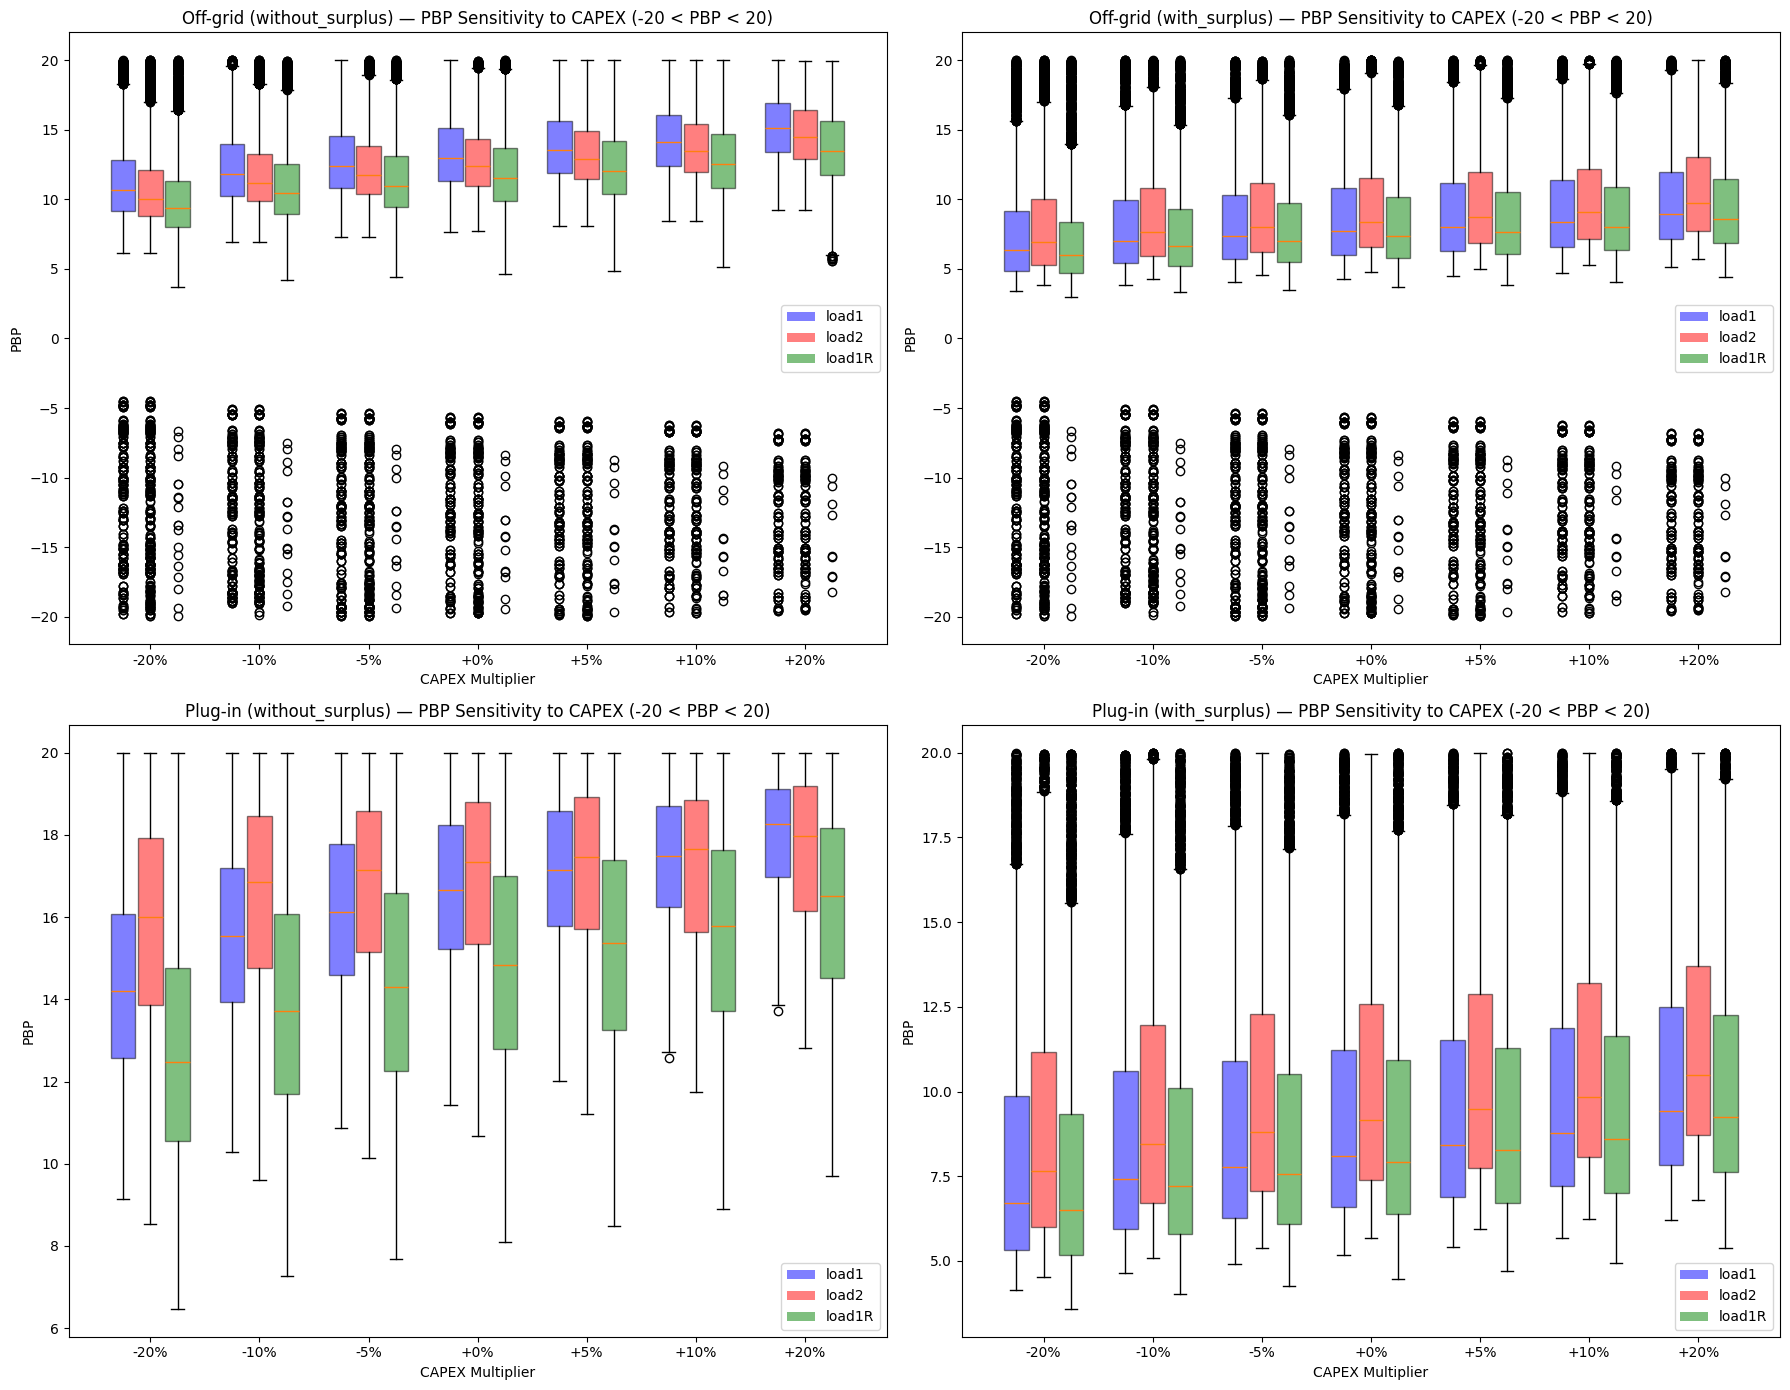

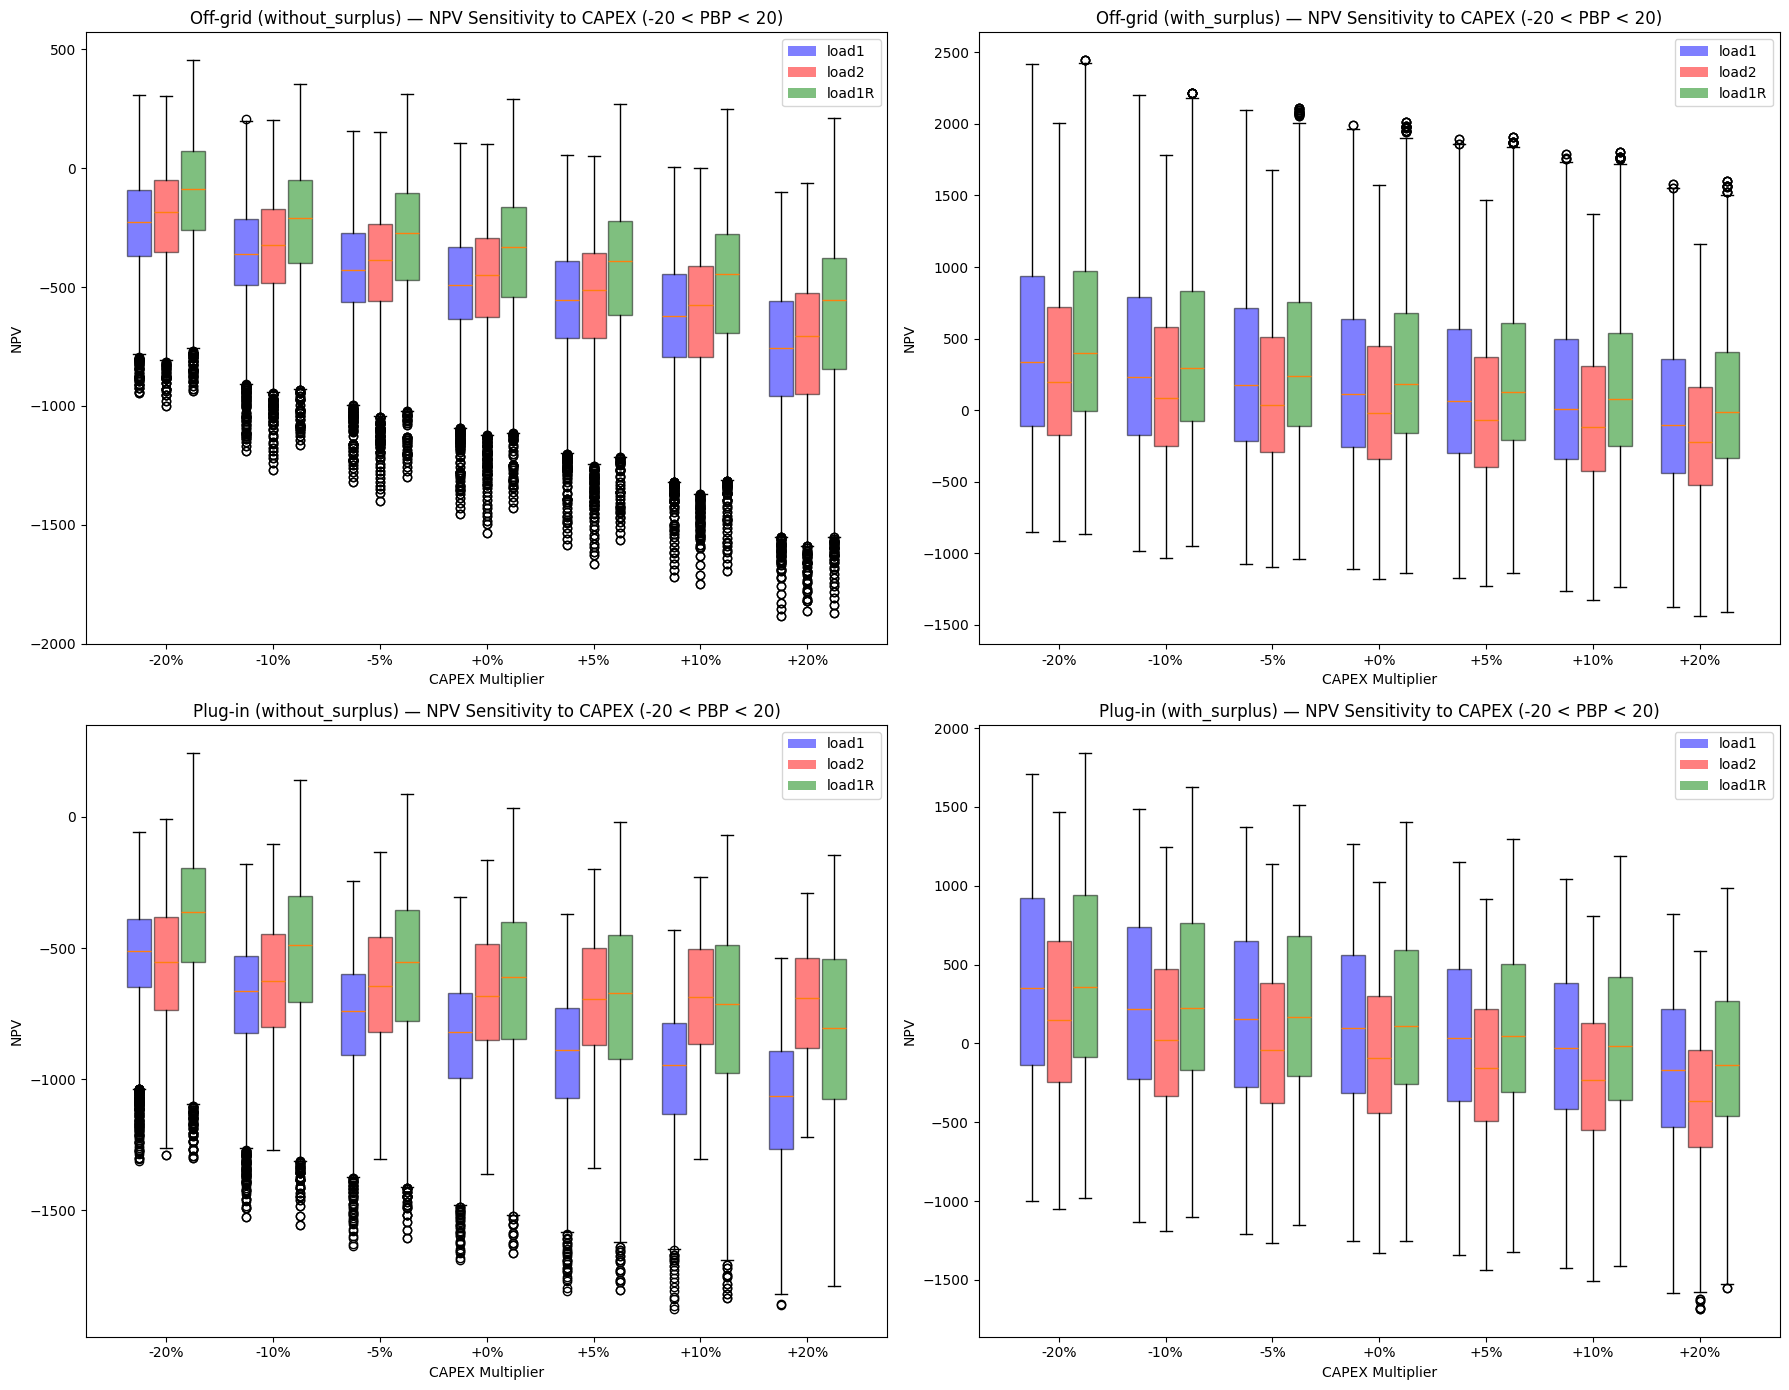

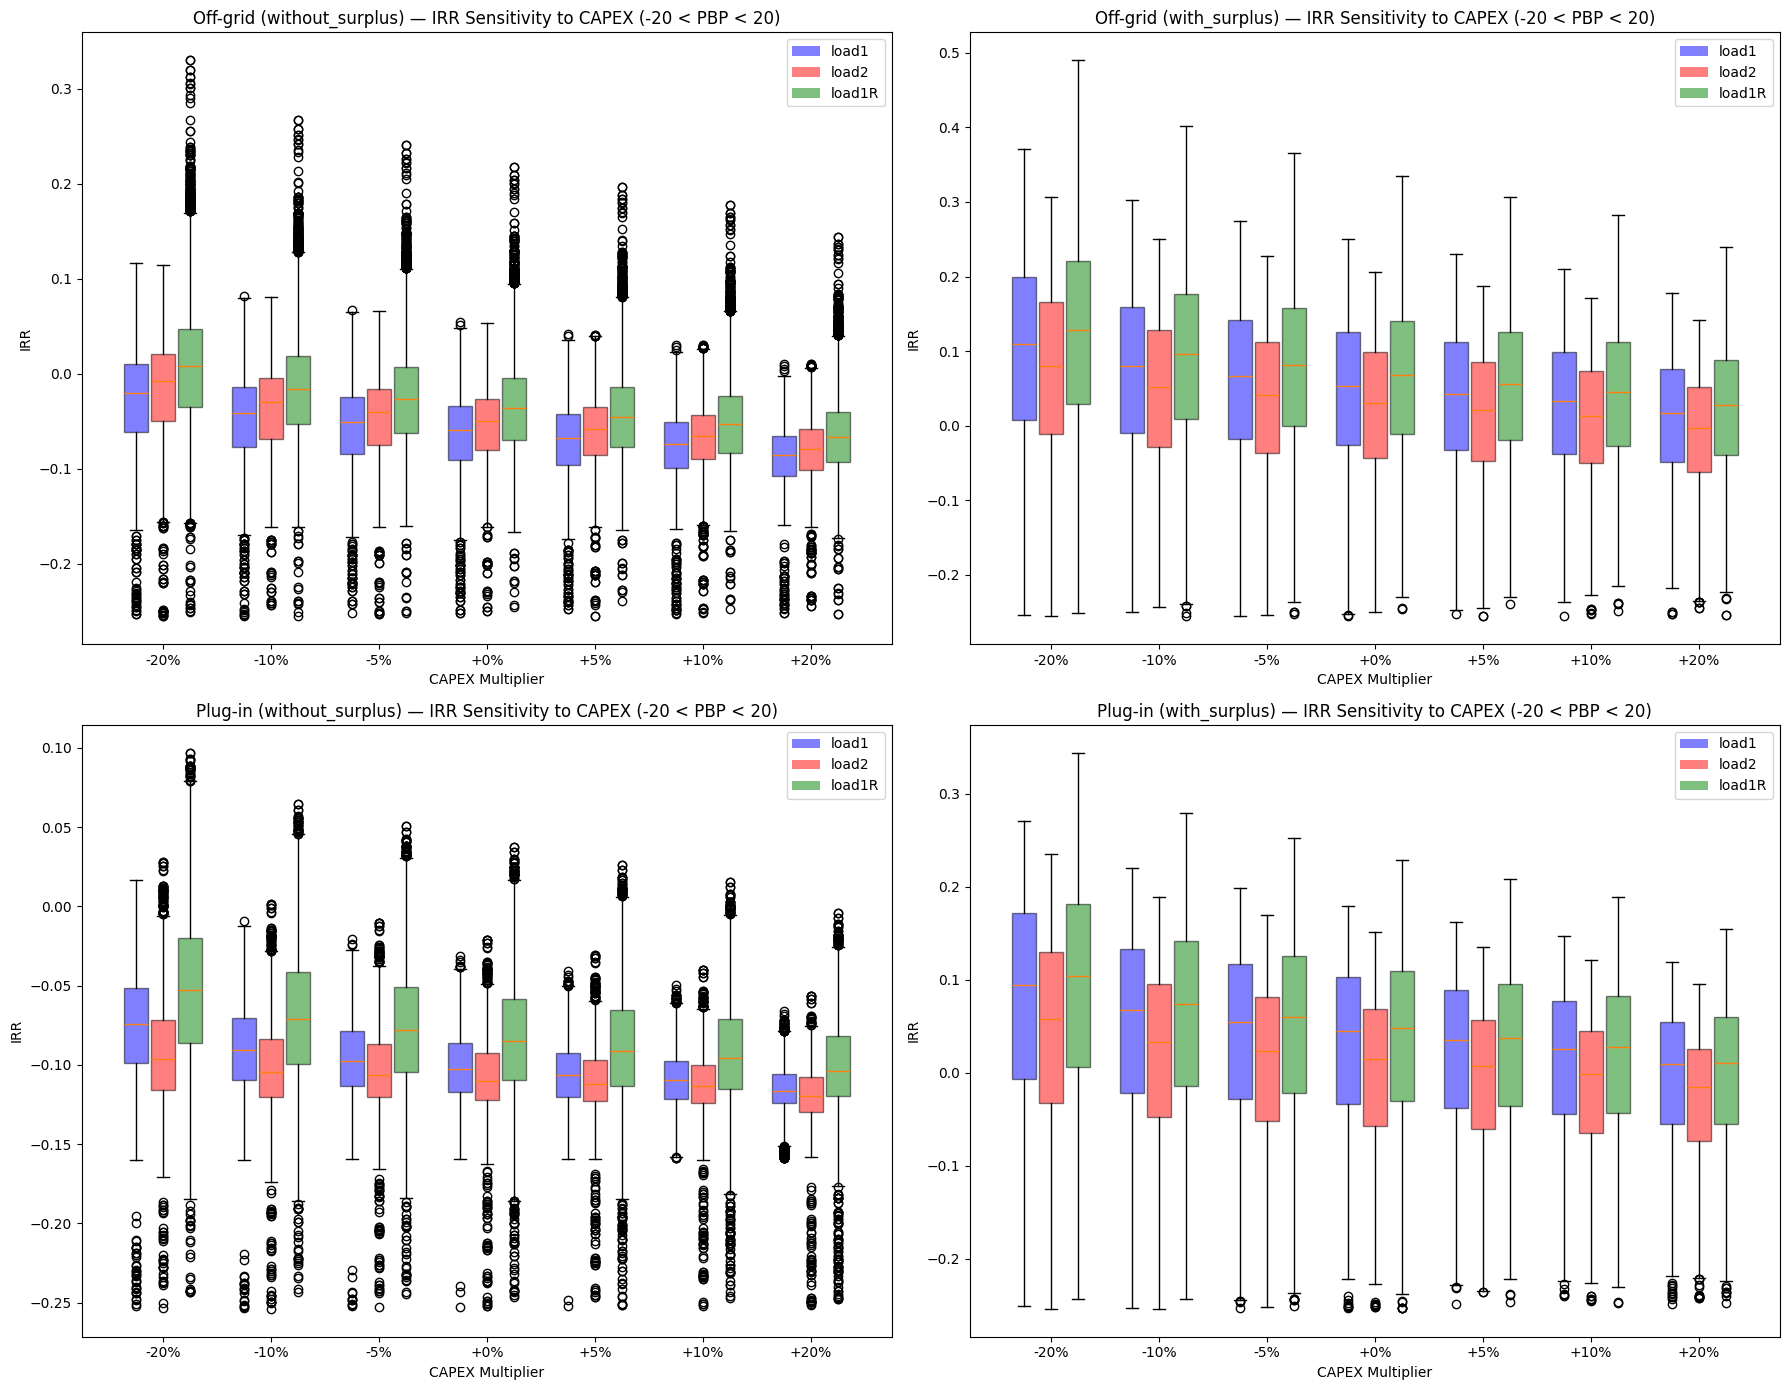

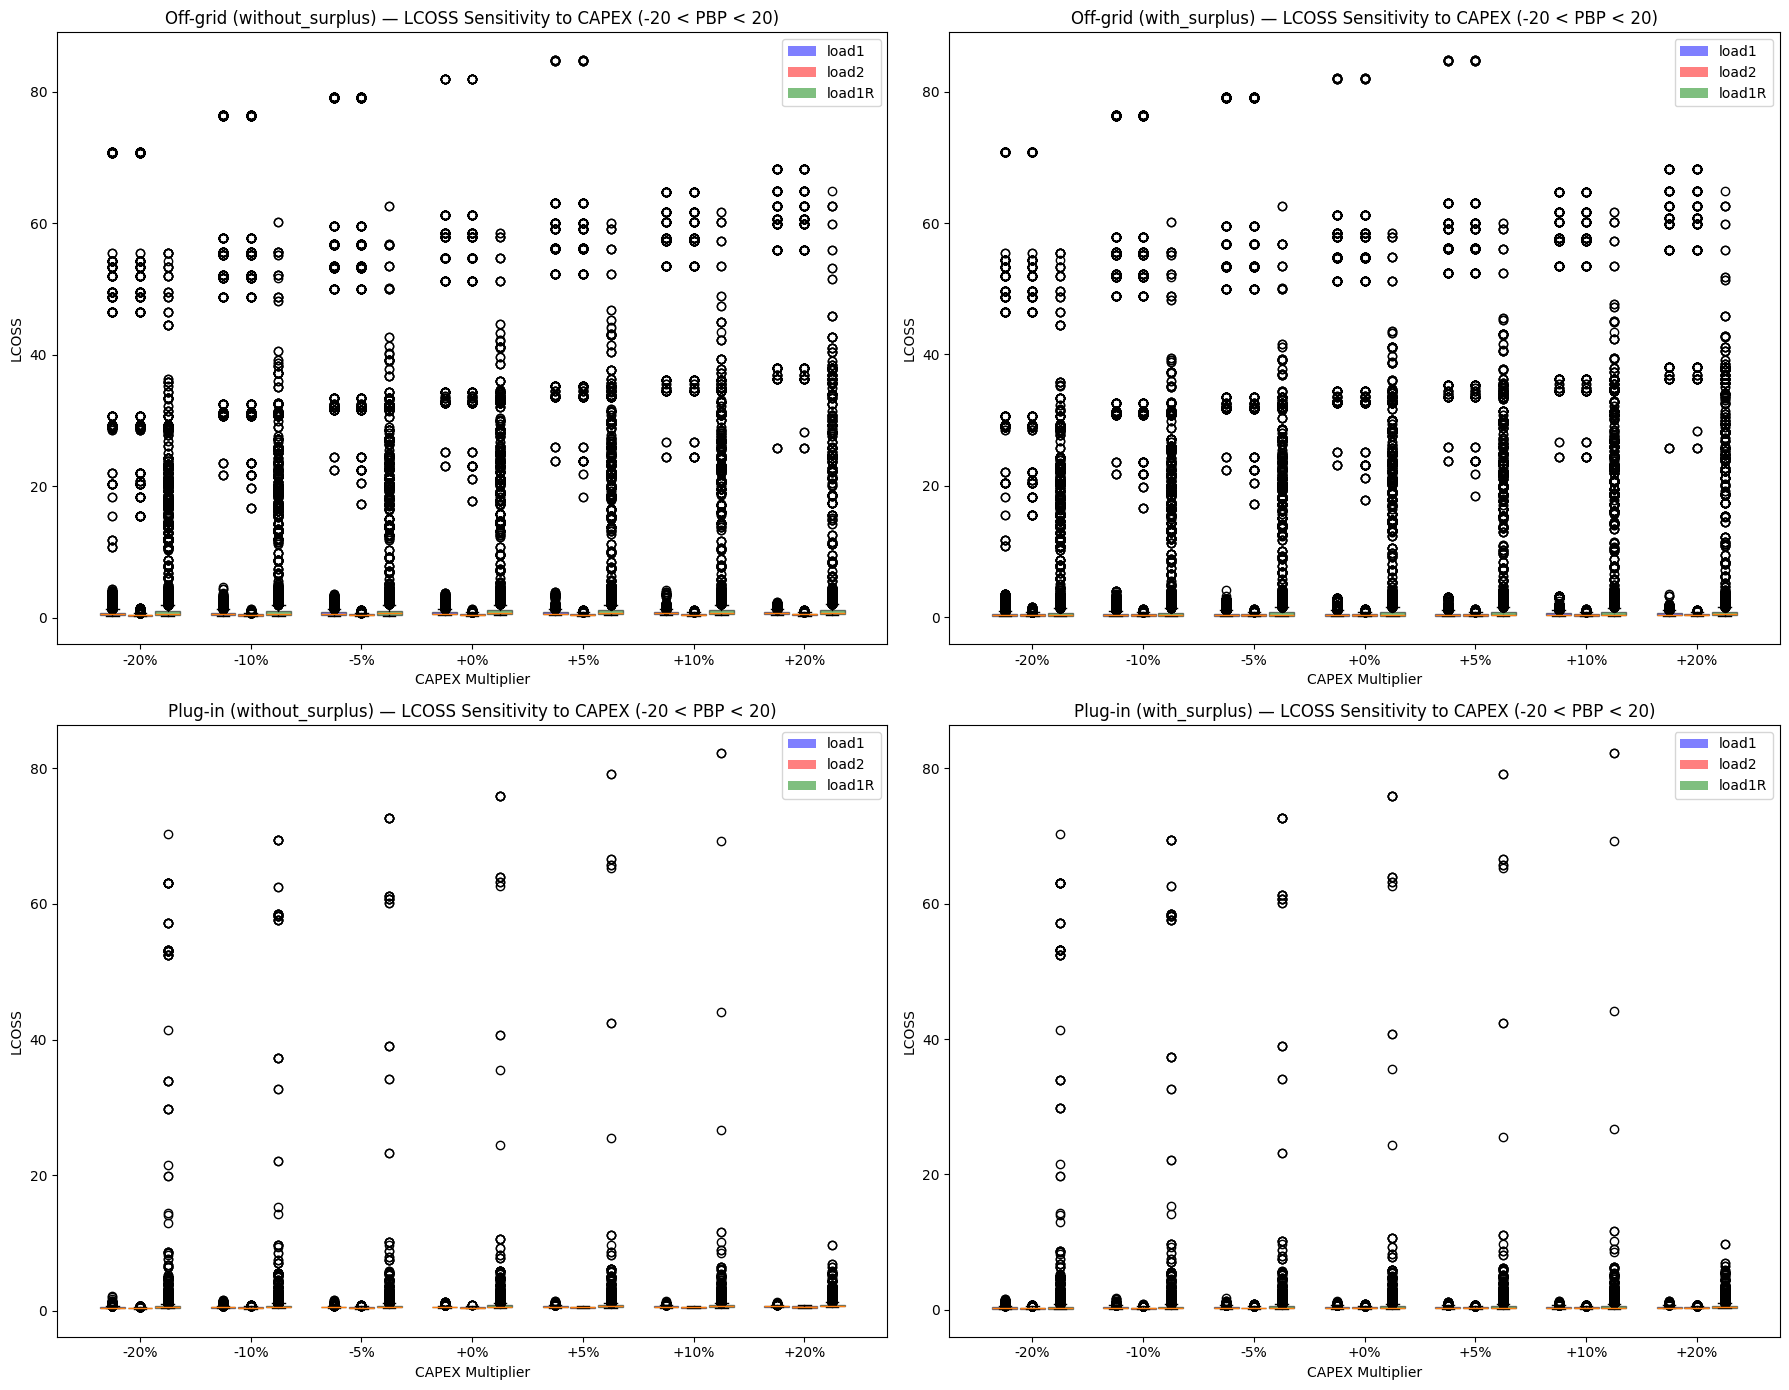

In [82]:
# CAPEX Sensitivity — box plots at each CAPEX multiplier level
# One figure per metric (PBP, NPV, IRR, LCOSS), each a 2x2 grid of
# Off-grid/Plug-in x without/with surplus combos.
# Filter: for each load/CAPEX-level/scenario, only include rows where that
# load's PBP at that same CAPEX level & scenario is between -20 and 20 years.
# This filter is applied consistently across all 4 metric figures.

capex_multipliers = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]  # must match main-loop values exactly
loads_colors = [('load1', 'blue'), ('load2', 'red'), ('load1R', 'green')]
metrics = ['PBP', 'NPV', 'IRR', 'LCOSS']

combos = [
    ('Off-grid', og_results_df, 'without_surplus'),
    ('Off-grid', og_results_df, 'with_surplus'),
    ('Plug-in', pi_results_df, 'without_surplus'),
    ('Plug-in', pi_results_df, 'with_surplus'),
]

width = 0.25  # horizontal spacing between the 3 grouped boxes at each CAPEX level

for metric in metrics:
    fig, axs = plt.subplots(2, 2, figsize=(18, 14))

    for i, (label, df, sc) in enumerate(combos):
        ax = axs[i // 2, i % 2]

        box_data = []
        positions = []
        colors_list = []

        for c_idx, capex in enumerate(capex_multipliers):
            for l_idx, (load_name, color) in enumerate(loads_colors):
                # PBP at this same load/capex/scenario, used purely as a filter
                pbp_col = f'{load_name}_PBP_capexSensitivity'
                pbp_vals = df[pbp_col].apply(
                    lambda d, cx=capex, s=sc: (
                        d.get(cx, {}).get(s) if isinstance(d, dict) else None
                    )
                )
                pbp_mask = pbp_vals.notna() & (pbp_vals > -20) & (pbp_vals < 20)

                # actual metric being plotted, filtered by the PBP mask above
                metric_col = f'{load_name}_{metric}_capexSensitivity'
                vals = df[metric_col].apply(
                    lambda d, cx=capex, s=sc: (
                        d.get(cx, {}).get(s) if isinstance(d, dict) else None
                    )
                )
                vals = vals[pbp_mask].dropna()

                if len(vals) == 0:
                    continue  # skip empty groups so boxplot doesn't choke on them

                pos = c_idx + (l_idx - 1) * width  # centered around c_idx, spread by load
                box_data.append(vals.values)
                positions.append(pos)
                colors_list.append(color)

        if not box_data:
            ax.set_title(f"{label} ({sc}) — {metric} — no data")
            continue

        bp = ax.boxplot(box_data, positions=positions, widths=width * 0.9, patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)

        ax.set_xticks(range(len(capex_multipliers)))
        ax.set_xticklabels([f'{int(cm * 100):+d}%' for cm in capex_multipliers])
        ax.set_xlabel('CAPEX Multiplier')
        ax.set_ylabel(metric)
        ax.set_title(f'{label} ({sc}) — {metric} Sensitivity to CAPEX (-20 < PBP < 20)')

        # manual legend, since boxplot() doesn't label by group automatically
        handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color, alpha=0.5) for _, color in loads_colors]
        ax.legend(handles, [ln for ln, _ in loads_colors])

    plt.tight_layout()

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    plt.savefig(f'results/plots/capexSensitivity_{metric}_filtered_{timestamp}.png', dpi=150, bbox_inches='tight')
    plt.show()